## 4.1 数据集读取与完整性检查

本实验采用EuroSAT RGB遥感土地利用分类数据集。数据集包含10种土地利用与土地覆盖类别，图像以类别文件夹的形式进行组织。本步骤首先配置随机种子和运行设备，然后读取数据集目录，检查类别文件夹、图像数量、图像格式、图像尺寸及文件完整性，为后续数据分析和模型训练提供可靠的数据基础。


In [1]:
# ==============================
# 1. 导入实验所需库
# ==============================

import os
import sys
import random
import platform
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError

import torch
import torchvision

print("基础库导入成功。")

基础库导入成功。


##### 实验依赖库导入分析

本步骤成功导入了数据读取、文件管理、数值计算、图表绘制、图像处理和深度学习实验所需的基础库。

其中：

- `os`、`sys`、`platform` 和 `pathlib` 用于运行环境及文件路径管理；
- `random` 和 `numpy` 用于随机抽样与数值计算；
- `pandas` 用于数据统计结果的表格化展示；
- `matplotlib` 用于后续数据可视化；
- `PIL` 用于读取图像、获取图像属性及检测损坏文件；
- `torch` 和 `torchvision` 用于后续卷积神经网络与迁移学习实验；
- `Counter` 用于统计图像尺寸、颜色模式和文件格式。

程序输出“基础库导入成功”，说明当前 Python 环境中的相关依赖均可以正常调用，没有出现模块缺失或版本加载错误，可以继续执行后续数据集检查。

In [2]:
# ==============================
# 2. 固定随机种子并检测运行设备
# ==============================

SEED = 42


def set_random_seed(seed: int = 42) -> None:
    """
    固定Python、NumPy和PyTorch的随机种子，
    提高实验结果的可重复性。
    """
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # 尽量保证卷积运算结果可重复
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_random_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Python版本：{sys.version.split()[0]}")
print(f"操作系统：{platform.system()} {platform.release()}")
print(f"PyTorch版本：{torch.__version__}")
print(f"Torchvision版本：{torchvision.__version__}")
print(f"随机种子：{SEED}")
print(f"当前运行设备：{device}")

if torch.cuda.is_available():
    print(f"GPU型号：{torch.cuda.get_device_name(0)}")
    print(
        f"GPU显存："
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB"
    )
else:
    print("当前未检测到可用GPU，将使用CPU运行。")

Python版本：3.13.2
操作系统：Windows 11
PyTorch版本：2.12.0+cpu
Torchvision版本：0.27.0+cpu
随机种子：42
当前运行设备：cpu
当前未检测到可用GPU，将使用CPU运行。


##### 实验环境与随机种子分析

本次实验检测到的运行环境如下。

| 环境项目 | 检测结果 |
|:---|:---|
| Python 版本 | 3.13.2 |
| 操作系统 | Windows 11 |
| PyTorch 版本 | 2.12.0+cpu |
| Torchvision 版本 | 0.27.0+cpu |
| 随机种子 | 42 |
| 当前运行设备 | CPU |
| CUDA 是否可用 | 否 |

实验将 Python、NumPy 和 PyTorch 的随机种子统一设置为 42。固定随机种子可以使后续的随机图像抽样、数据集划分及部分模型初始化过程具有较好的可复现性，即在相同代码和环境条件下能够重复得到一致或高度接近的实验结果。

代码同时将 cuDNN 的确定性模式设置为 `True`，并关闭自动基准优化。当前环境使用的是 CPU 版本 PyTorch，因此这些 cuDNN 设置在本次运行中不会实际生效，但保留该设置有利于代码未来迁移到 GPU 环境后继续控制实验随机性。

当前未检测到可用 GPU，数据检查与后续模型训练均将在 CPU 上完成。CPU 环境不会影响数据读取和完整性检查结果的正确性，但后续卷积神经网络训练所需时间可能明显长于 GPU 环境。

In [3]:
# ==============================
# 3. 设置EuroSAT RGB数据集路径
# ==============================

# Notebook与EuroSAT_RGB文件夹在同一级目录
DATA_DIR = Path("./EuroSAT_RGB")


# 将路径转换为绝对路径，方便检查
DATA_DIR = DATA_DIR.resolve()

print(f"数据集绝对路径：{DATA_DIR}")
print(f"路径是否存在：{DATA_DIR.exists()}")
print(f"是否为文件夹：{DATA_DIR.is_dir()}")

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"\n没有找到数据集文件夹：{DATA_DIR}\n"
        "请检查DATA_DIR是否指向解压后的EuroSAT_RGB文件夹。"
    )

if not DATA_DIR.is_dir():
    raise NotADirectoryError(
        f"{DATA_DIR}不是文件夹，请重新检查路径。"
    )

print("数据集路径检查通过。")

数据集绝对路径：D:\qy\junior\深度学习\课设\EuroSAT_RGB
路径是否存在：True
是否为文件夹：True
数据集路径检查通过。


##### 数据集路径检查分析

本次运行中，程序将相对路径转换为绝对路径后，成功定位到 EuroSAT RGB 数据集目录。检查结果表明：

- 数据集路径真实存在；
- 该路径对应的是文件夹，而不是普通文件；
- 程序具有正常访问数据集目录的权限。

因此，数据集路径检查顺利通过，后续代码可以继续遍历类别文件夹并读取其中的遥感图像。

需要说明的是，本次结果记录的是项目目录整理前的数据路径。目录重新整理后，原始图像现统一存放于：

`EuroSAT_RGB/data/`

后续重新运行 Notebook 时，应将 `DATA_DIR` 指向该目录。目录位置的变化不会影响本次已经完成的数据完整性检查结论。

In [4]:
# ==============================
# 4. 检查类别文件夹是否完整
# ==============================

EXPECTED_CLASSES = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]

# 获取数据目录下所有一级子文件夹
actual_classes = sorted([
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir()
])

missing_classes = sorted(set(EXPECTED_CLASSES) - set(actual_classes))
extra_classes = sorted(set(actual_classes) - set(EXPECTED_CLASSES))

print(f"预期类别数：{len(EXPECTED_CLASSES)}")
print(f"实际类别数：{len(actual_classes)}")
print("\n实际检测到的类别：")

for index, class_name in enumerate(actual_classes, start=1):
    print(f"{index:02d}. {class_name}")

if missing_classes:
    print("\n缺少的类别文件夹：")
    for class_name in missing_classes:
        print(f"- {class_name}")
else:
    print("\n没有缺少类别文件夹。")

if extra_classes:
    print("\n检测到额外文件夹：")
    for class_name in extra_classes:
        print(f"- {class_name}")
else:
    print("没有检测到额外类别文件夹。")

if missing_classes:
    raise ValueError(
        "数据集类别不完整，请重新检查数据集解压结果。"
    )

print("\n类别目录结构检查通过。")

预期类别数：10
实际类别数：10

实际检测到的类别：
01. AnnualCrop
02. Forest
03. HerbaceousVegetation
04. Highway
05. Industrial
06. Pasture
07. PermanentCrop
08. Residential
09. River
10. SeaLake

没有缺少类别文件夹。
没有检测到额外类别文件夹。

类别目录结构检查通过。


##### 类别目录结构完整性分析

程序按照 EuroSAT RGB 数据集的标准配置，预先定义了 10 个土地利用与土地覆盖类别，并将其与数据目录中实际检测到的一级子文件夹进行比较。

检查结果如下：

| 检查项目 | 检查结果 |
|:---|:---|
| 预期类别数量 | 10 |
| 实际类别数量 | 10 |
| 缺少类别数量 | 0 |
| 额外类别数量 | 0 |
| 目录结构检查 | 通过 |

实际检测到的类别包括：

1. AnnualCrop；
2. Forest；
3. HerbaceousVegetation；
4. Highway；
5. Industrial；
6. Pasture；
7. PermanentCrop；
8. Residential；
9. River；
10. SeaLake。

检测结果与预期类别完全一致，未发现类别文件夹缺失、类别名称拼写错误或额外类别目录。这说明数据集解压结果完整，类别目录结构满足后续按文件夹读取图像和建立分类标签的要求。

类别文件夹名称同时承担类别标识作用，因此目录名称的完整性和一致性能够避免后续 Dataset 构建过程中出现标签遗漏或类别映射错误。

In [5]:
# ==============================
# 5. 统计各类别图片数量
# ==============================

VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}

class_counts = {}
all_image_paths = []

for class_name in EXPECTED_CLASSES:
    class_dir = DATA_DIR / class_name

    image_paths = sorted([
        file_path
        for file_path in class_dir.iterdir()
        if file_path.is_file()
        and file_path.suffix.lower() in VALID_EXTENSIONS
    ])

    class_counts[class_name] = len(image_paths)
    all_image_paths.extend(image_paths)

class_count_df = pd.DataFrame({
    "类别英文名": list(class_counts.keys()),
    "图像数量": list(class_counts.values())
})

class_count_df["样本占比"] = (
    class_count_df["图像数量"]
    / class_count_df["图像数量"].sum()
)

class_count_df["样本占比"] = (
    class_count_df["样本占比"] * 100
).round(2).astype(str) + "%"

print("各类别图片数量：")
display(class_count_df)

print(f"\n数据集总图片数量：{len(all_image_paths):,}")
print(f"类别总数：{len(class_counts)}")
print(f"最少类别样本数：{min(class_counts.values()):,}")
print(f"最多类别样本数：{max(class_counts.values()):,}")

各类别图片数量：


,类别英文名,图像数量,样本占比
0,AnnualCrop,3000,11.11%
1,Forest,3000,11.11%
2,HerbaceousVegetation,3000,11.11%
3,Highway,2500,9.26%
4,Industrial,2500,9.26%
5,Pasture,2000,7.41%
6,PermanentCrop,2500,9.26%
7,Residential,3000,11.11%
8,River,2500,9.26%
9,SeaLake,3000,11.11%



数据集总图片数量：27,000
类别总数：10
最少类别样本数：2,000
最多类别样本数：3,000


##### 各类别样本数量统计分析

程序对 10 个类别文件夹中的有效图像文件进行了统计，共检测到 27,000 张遥感图像。

各类别样本数量如下。

| 类别英文名称 | 图像数量 | 样本占比 |
|:---|---:|---:|
| AnnualCrop | 3,000 | 11.11% |
| Forest | 3,000 | 11.11% |
| HerbaceousVegetation | 3,000 | 11.11% |
| Highway | 2,500 | 9.26% |
| Industrial | 2,500 | 9.26% |
| Pasture | 2,000 | 7.41% |
| PermanentCrop | 2,500 | 9.26% |
| Residential | 3,000 | 11.11% |
| River | 2,500 | 9.26% |
| SeaLake | 3,000 | 11.11% |
| **合计** | **27,000** | **100.00%** |

样本数量最多的类别共有 5 个，分别为 AnnualCrop、Forest、HerbaceousVegetation、Residential 和 SeaLake，每个类别均包含 3,000 张图像。

样本数量最少的类别为 Pasture，共包含 2,000 张图像。最大类别与最小类别的样本数量差为：

$$
3000-2000=1000
$$

最大类别与最小类别的样本数量比为：

$$
\frac{3000}{2000}=1.5
$$

从初步统计结果看，各类别样本数量存在一定差异，但最大与最小类别之比仅为 1.5∶1，没有出现某一类别数量远高于或远低于其他类别的严重失衡情况。

该结果可以为后续类别分布可视化和数据集分层划分提供基础。为了保证训练集、验证集和测试集中的类别比例与原始数据集一致，后续仍应采用分层抽样方式进行数据划分。

In [6]:
# ==============================
# 6. 随机抽查图片属性
# ==============================

SAMPLE_CHECK_NUM = min(100, len(all_image_paths))

sample_paths = random.sample(
    all_image_paths,
    k=SAMPLE_CHECK_NUM
)

sample_records = []
sample_errors = []

for image_path in sample_paths:
    try:
        with Image.open(image_path) as image:
            sample_records.append({
                "文件名": image_path.name,
                "类别": image_path.parent.name,
                "宽度": image.width,
                "高度": image.height,
                "颜色模式": image.mode,
                "图像格式": image.format
            })

    except Exception as error:
        sample_errors.append({
            "文件路径": str(image_path),
            "错误信息": str(error)
        })

sample_info_df = pd.DataFrame(sample_records)

print(f"随机抽查图片数量：{SAMPLE_CHECK_NUM}")
print(f"成功读取数量：{len(sample_records)}")
print(f"读取失败数量：{len(sample_errors)}")

if not sample_info_df.empty:
    print("\n随机样本属性前10条：")
    display(sample_info_df.head(10))

    print("\n抽查样本的尺寸分布：")
    display(
        sample_info_df
        .groupby(["宽度", "高度"])
        .size()
        .reset_index(name="数量")
    )

    print("\n抽查样本的颜色模式分布：")
    display(
        sample_info_df["颜色模式"]
        .value_counts()
        .rename_axis("颜色模式")
        .reset_index(name="数量")
    )

    print("\n抽查样本的图像格式分布：")
    display(
        sample_info_df["图像格式"]
        .value_counts()
        .rename_axis("图像格式")
        .reset_index(name="数量")
    )

if sample_errors:
    print("\n读取失败的文件：")
    display(pd.DataFrame(sample_errors))
else:
    print("\n随机抽查未发现损坏图片。")

随机抽查图片数量：100
成功读取数量：100
读取失败数量：0

随机样本属性前10条：


,文件名,类别,宽度,高度,颜色模式,图像格式
0,Residential_505.jpg,Residential,64,64,RGB,JPEG
1,Forest_1582.jpg,Forest,64,64,RGB,JPEG
2,AnnualCrop_1736.jpg,AnnualCrop,64,64,RGB,JPEG
3,SeaLake_1268.jpg,SeaLake,64,64,RGB,JPEG
4,Highway_1009.jpg,Highway,64,64,RGB,JPEG
5,HerbaceousVegetation_2820.jpg,HerbaceousVegetation,64,64,RGB,JPEG
6,HerbaceousVegetation_2181.jpg,HerbaceousVegetation,64,64,RGB,JPEG
7,Forest_2413.jpg,Forest,64,64,RGB,JPEG
8,SeaLake_1117.jpg,SeaLake,64,64,RGB,JPEG
9,Forest_1320.jpg,Forest,64,64,RGB,JPEG



抽查样本的尺寸分布：


,宽度,高度,数量
0,64,64,100



抽查样本的颜色模式分布：


,颜色模式,数量
0,RGB,100



抽查样本的图像格式分布：


,图像格式,数量
0,JPEG,100



随机抽查未发现损坏图片。


##### 随机样本属性检查分析

本步骤在固定随机种子 42 的条件下，从全部 27,000 张图像中随机抽取了 100 张图像进行初步检查。

检查结果如下。

| 检查项目 | 检查结果 |
|:---|:---|
| 随机抽查数量 | 100 张 |
| 成功读取数量 | 100 张 |
| 读取失败数量 | 0 张 |
| 图像尺寸 | 全部为 $64\times64$ 像素 |
| 颜色模式 | 全部为 RGB |
| 图像格式 | 全部为 JPEG |
| 是否发现损坏图像 | 否 |

随机抽取的 100 张图像均能够使用 PIL 正常打开，未出现文件无法识别、读取中断或图像内容加载失败等问题。

抽查样本的尺寸分布只有一种，即：

$$
64\times64
$$

颜色模式全部为 RGB，说明每张图像均由红、绿、蓝三个颜色通道构成。图像格式全部为 JPEG，与 EuroSAT RGB 数据集的标准图像格式一致。

固定随机种子后，本次抽取的样本集合具有可复现性。在相同的数据顺序和运行环境下重新执行代码，可以获得相同的随机抽查结果。

需要注意，随机抽查只能初步判断数据质量，不能完全排除未抽中图像中存在异常文件的可能。因此，下一步骤继续对全部 27,000 张图像进行完整性检查。

In [7]:
# ==============================
# 7. 全量检查图片完整性
# ==============================

corrupted_files = []
image_modes = Counter()
image_sizes = Counter()
image_formats = Counter()

total_images = len(all_image_paths)

print(f"开始检查全部 {total_images:,} 张图片……")

for index, image_path in enumerate(all_image_paths, start=1):
    try:
        # 第一次打开：使用verify检查文件结构
        with Image.open(image_path) as image:
            image.verify()

        # verify之后需要重新打开，才能访问图像属性
        with Image.open(image_path) as image:
            image.load()

            image_modes[image.mode] += 1
            image_sizes[(image.width, image.height)] += 1
            image_formats[image.format] += 1

    except (
        UnidentifiedImageError,
        OSError,
        ValueError,
        SyntaxError
    ) as error:
        corrupted_files.append({
            "文件路径": str(image_path),
            "所属类别": image_path.parent.name,
            "错误类型": type(error).__name__,
            "错误信息": str(error)
        })

    # 每检查5000张输出一次进度
    if index % 5000 == 0 or index == total_images:
        print(
            f"已检查：{index:,}/{total_images:,} "
            f"({index / total_images * 100:.1f}%)"
        )

print("\n完整性检查结束。")
print(f"图片总数：{total_images:,}")
print(f"损坏图片数量：{len(corrupted_files)}")

开始检查全部 27,000 张图片……
已检查：5,000/27,000 (18.5%)
已检查：10,000/27,000 (37.0%)
已检查：15,000/27,000 (55.6%)
已检查：20,000/27,000 (74.1%)
已检查：25,000/27,000 (92.6%)
已检查：27,000/27,000 (100.0%)

完整性检查结束。
图片总数：27,000
损坏图片数量：0


##### 全量图像完整性检查分析

在随机抽查未发现异常后，本步骤进一步对数据集中的全部 27,000 张图像进行了完整性检查。

检查过程中，每张图像均执行了两个阶段的读取：

1. 使用 `image.verify()` 检查图像文件结构是否完整；
2. 重新打开图像并执行 `image.load()`，检查图像像素数据是否能够被实际解码和加载。

由于调用 `verify()` 后图像对象不能继续用于像素读取，因此代码重新打开图像进行属性统计。这种检查方式比仅调用一次 `Image.open()` 更严格，能够同时发现文件头损坏、格式无法识别及像素数据截断等问题。

程序分阶段输出检查进度，最终完成了全部 27,000 张图像的扫描。检查结果为：

| 检查项目 | 检查结果 |
|:---|---:|
| 图像总数 | 27,000 |
| 已完成检查数量 | 27,000 |
| 检查完成比例 | 100.0% |
| 损坏图像数量 | 0 |
| 可正常读取图像数量 | 27,000 |

未发现 `UnidentifiedImageError`、`OSError`、`ValueError` 或 `SyntaxError` 等图像读取异常，说明全部图像文件结构完整，像素数据均能够正常解码。

该结果证明原始数据集中不存在需要删除、替换或跳过的损坏文件，可以直接进入后续图像预处理和模型训练阶段。

In [8]:
# ==============================
# 8. 汇总全量检查结果
# ==============================

size_df = pd.DataFrame([
    {
        "宽度": width,
        "高度": height,
        "图像数量": count
    }
    for (width, height), count in image_sizes.items()
]).sort_values(
    by="图像数量",
    ascending=False
).reset_index(drop=True)

mode_df = pd.DataFrame([
    {
        "颜色模式": mode,
        "图像数量": count
    }
    for mode, count in image_modes.items()
]).sort_values(
    by="图像数量",
    ascending=False
).reset_index(drop=True)

format_df = pd.DataFrame([
    {
        "图像格式": image_format,
        "图像数量": count
    }
    for image_format, count in image_formats.items()
]).sort_values(
    by="图像数量",
    ascending=False
).reset_index(drop=True)

print("图像尺寸统计：")
display(size_df)

print("颜色模式统计：")
display(mode_df)

print("图像格式统计：")
display(format_df)

if corrupted_files:
    corrupted_df = pd.DataFrame(corrupted_files)

    print("发现损坏或无法读取的图片：")
    display(corrupted_df)

    # 将损坏文件名单保存下来，暂时不自动删除
    corrupted_df.to_csv(
        "corrupted_images.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print(
        "损坏文件信息已保存为：corrupted_images.csv"
    )

else:
    print("数据集中的所有图片均可以正常读取。")

图像尺寸统计：


,宽度,高度,图像数量
0,64,64,27000


颜色模式统计：


,颜色模式,图像数量
0,RGB,27000


图像格式统计：


,图像格式,图像数量
0,JPEG,27000


数据集中的所有图片均可以正常读取。


##### 全量图像属性一致性分析

全量检查结果显示，27,000 张 EuroSAT RGB 图像在尺寸、颜色模式和文件格式方面具有完全一致的属性。

| 图像属性 | 属性值 | 图像数量 | 占比 |
|:---|:---:|---:|---:|
| 图像尺寸 | $64\times64$ | 27,000 | 100% |
| 颜色模式 | RGB | 27,000 | 100% |
| 图像格式 | JPEG | 27,000 | 100% |

全部图像均为 $64\times64$ 像素，说明原始数据集中不存在尺寸异常或宽高比例不一致的图像。后续仍需将图像调整到预训练模型要求的输入尺寸，但不需要针对不同原始尺寸设计额外处理逻辑。

全部图像均采用 RGB 三通道模式，不存在灰度图、RGBA 图像或其他颜色模式。因此，后续图像变换能够使用统一的三通道处理流程。

全部图像格式均为 JPEG，也未发现扩展名与实际图像格式不一致的情况。统一的文件格式有利于保证批量读取过程稳定。

由于损坏图像数量为 0，程序没有生成 `corrupted_images.csv`。这属于正常结果，说明没有异常文件需要额外记录或人工处理。

综合来看，EuroSAT RGB 数据集的图像属性高度统一，可以减少后续 Dataset 构建、批量加载和模型输入处理中的兼容性问题。

In [9]:
# ==============================
# 9. 生成数据集检查总结
# ==============================

total_count = sum(class_counts.values())
min_class_name = min(class_counts, key=class_counts.get)
max_class_name = max(class_counts, key=class_counts.get)

print("=" * 60)
print("EuroSAT RGB数据集初步检查总结")
print("=" * 60)

print(f"数据集路径：{DATA_DIR}")
print(f"类别数量：{len(class_counts)}")
print(f"图像总数：{total_count:,}")

print(
    f"样本最少类别：{min_class_name}，"
    f"共{class_counts[min_class_name]:,}张"
)

print(
    f"样本最多类别：{max_class_name}，"
    f"共{class_counts[max_class_name]:,}张"
)

print(f"损坏图片数量：{len(corrupted_files)}")
print(f"图像尺寸种类：{list(image_sizes.keys())}")
print(f"颜色模式：{list(image_modes.keys())}")
print(f"图像格式：{list(image_formats.keys())}")

if (
    len(actual_classes) == 10
    and total_count == 27000
    and len(corrupted_files) == 0
):
    print("\n检查结论：数据集结构完整，可以进入后续实验。")
else:
    print(
        "\n检查结论：数据集与标准EuroSAT RGB配置"
        "存在差异，需要结合上方结果进一步检查。"
    )

EuroSAT RGB数据集初步检查总结
数据集路径：D:\qy\junior\深度学习\课设\EuroSAT_RGB
类别数量：10
图像总数：27,000
样本最少类别：Pasture，共2,000张
样本最多类别：AnnualCrop，共3,000张
损坏图片数量：0
图像尺寸种类：[(64, 64)]
颜色模式：['RGB']
图像格式：['JPEG']

检查结论：数据集结构完整，可以进入后续实验。


##### 数据集读取与完整性检查综合结论

本步骤完成了 EuroSAT RGB 数据集的路径检查、类别目录检查、类别数量统计、随机样本属性检查和全量图像完整性检查。

主要检查结果如下。

| 检查项目 | 最终结果 |
|:---|:---|
| 类别数量 | 10 类 |
| 图像总数 | 27,000 张 |
| 图像尺寸 | 全部为 $64\times64$ |
| 颜色模式 | 全部为 RGB |
| 图像格式 | 全部为 JPEG |
| 缺少类别文件夹 | 0 个 |
| 额外类别文件夹 | 0 个 |
| 损坏图像 | 0 张 |
| 数据集结构 | 完整 |

样本数量最少的类别为 Pasture，共 2,000 张图像。样本数量最多的类别共有 5 个，分别为 AnnualCrop、Forest、HerbaceousVegetation、Residential 和 SeaLake，每类均包含 3,000 张图像。

程序自动总结中显示“样本最多类别为 AnnualCrop”，是因为代码使用了：

`max(class_counts, key=class_counts.get)`

当多个类别拥有相同最大值时，该写法只会返回字典中最先出现的类别。因此，AnnualCrop 确实属于样本最多的类别，但并不是唯一的样本最多类别。完整结论应以 5 个并列最多类别为准。

全部 27,000 张图像均能够通过文件结构验证和像素加载检查，未发现损坏、无法识别或无法解码的图像。所有图像的尺寸、颜色模式和文件格式也完全一致。

因此，EuroSAT RGB 数据集的目录结构、类别组成、图像数量和文件质量均满足后续实验要求，可以继续进行类别分布可视化、代表性样本展示、数据集划分、图像预处理及模型训练。

### 4.2.1 类别分布可视化

为直观分析EuroSAT RGB数据集各土地利用类别的样本分布情况，本实验统计了10个类别的图像数量及其在数据集中的占比，并按照样本数量由高到低绘制横向柱状图。图中同时标注各类别的图像数量、样本占比以及全部类别的平均样本数量，用于判断数据集是否存在明显的类别不平衡问题。

In [1]:
# ==========================================
# 4.2.1 EuroSAT RGB类别分布数据整理
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path


# 1. EuroSAT类别中英文名称对应关系
class_name_cn = {
    "AnnualCrop": "年生作物地",
    "Forest": "森林",
    "HerbaceousVegetation": "草本植被",
    "Highway": "高速公路",
    "Industrial": "工业区",
    "Pasture": "牧场",
    "PermanentCrop": "永久性作物地",
    "Residential": "居民区",
    "River": "河流",
    "SeaLake": "海洋与湖泊"
}


# 2. 如果前面的class_counts变量仍然存在，直接使用；
#    如果Notebook重启后变量不存在，则重新统计
if "class_counts" not in globals():
    print("未检测到class_counts变量，正在重新统计数据集……")

    DATA_DIR = Path(
        r"D:\qy\junior\深度学习\课设\EuroSAT_RGB"
    )

    valid_extensions = {
        ".jpg", ".jpeg", ".png",
        ".bmp", ".tif", ".tiff"
    }

    class_counts = {}

    for class_dir in sorted(DATA_DIR.iterdir()):
        if class_dir.is_dir():
            image_count = sum(
                1
                for file_path in class_dir.iterdir()
                if file_path.is_file()
                and file_path.suffix.lower() in valid_extensions
            )

            class_counts[class_dir.name] = image_count


# 3. 构建类别统计DataFrame
distribution_df = pd.DataFrame({
    "类别英文名称": list(class_counts.keys()),
    "图像数量": list(class_counts.values())
})


# 4. 添加中文类别名称
distribution_df["类别中文名称"] = (
    distribution_df["类别英文名称"]
    .map(class_name_cn)
)


# 5. 计算总样本数和样本占比
total_images = distribution_df["图像数量"].sum()

distribution_df["样本占比"] = (
    distribution_df["图像数量"]
    / total_images
    * 100
)


# 6. 按图像数量从高到低排序；
#    数量相同时按英文名称排序，保证结果稳定
distribution_df = (
    distribution_df
    .sort_values(
        by=["图像数量", "类别英文名称"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)


# 7. 组合中英文标签
distribution_df["图表标签"] = (
    distribution_df["类别中文名称"]
    + "\n"
    + distribution_df["类别英文名称"]
)


# 8. 显示整理后的统计表
display_df = distribution_df[
    [
        "类别英文名称",
        "类别中文名称",
        "图像数量",
        "样本占比"
    ]
].copy()

display_df["样本占比"] = (
    display_df["样本占比"]
    .map(lambda value: f"{value:.2f}%")
)

print("EuroSAT RGB类别分布统计：")
display(display_df)

print(f"数据集总图像数量：{total_images:,}张")

未检测到class_counts变量，正在重新统计数据集……
EuroSAT RGB类别分布统计：


,类别英文名称,类别中文名称,图像数量,样本占比
0,AnnualCrop,年生作物地,3000,11.11%
1,Forest,森林,3000,11.11%
2,HerbaceousVegetation,草本植被,3000,11.11%
3,Residential,居民区,3000,11.11%
4,SeaLake,海洋与湖泊,3000,11.11%
5,Highway,高速公路,2500,9.26%
6,Industrial,工业区,2500,9.26%
7,PermanentCrop,永久性作物地,2500,9.26%
8,River,河流,2500,9.26%
9,Pasture,牧场,2000,7.41%


数据集总图像数量：27,000张


##### 类别分布数据整理结果分析

本步骤对 EuroSAT RGB 数据集的类别名称、图像数量和样本占比进行了整理，共统计得到 10 个土地利用与土地覆盖类别，总图像数量为 27,000 张。

各类别统计结果如下。

| 类别英文名称 | 类别中文名称 | 图像数量 | 样本占比 |
|:---|:---|---:|---:|
| AnnualCrop | 年生作物地 | 3,000 | 11.11% |
| Forest | 森林 | 3,000 | 11.11% |
| HerbaceousVegetation | 草本植被 | 3,000 | 11.11% |
| Residential | 居民区 | 3,000 | 11.11% |
| SeaLake | 海洋与湖泊 | 3,000 | 11.11% |
| Highway | 高速公路 | 2,500 | 9.26% |
| Industrial | 工业区 | 2,500 | 9.26% |
| PermanentCrop | 永久性作物地 | 2,500 | 9.26% |
| River | 河流 | 2,500 | 9.26% |
| Pasture | 牧场 | 2,000 | 7.41% |
| **合计** | — | **27,000** | **100.00%** |

程序首先根据各类别图像数量进行降序排列；当多个类别样本数量相同时，再按照类别英文名称进行排序。该排序方式能够保证多次运行时表格和图表中的类别顺序保持稳定。

样本数为 3,000 张的类别共有 5 个，占数据集的主要组成部分；样本数为 2,500 张的类别共有 4 个；Pasture 类别包含 2,000 张图像，是样本数量最少的类别。

所有类别的样本占比之和为 100%，并且各类别图像数量之和与前面完整性检查得到的 27,000 张一致，说明类别分布统计过程没有出现样本遗漏或重复计数。

In [2]:
# ==========================================
# 4.2.1 设置中文字体与绘图参数
# ==========================================

def set_chinese_font():
    """
    自动查找Windows系统中常用的中文字体。
    找到后设置为Matplotlib默认字体。
    """

    preferred_fonts = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Source Han Sans CN",
        "Arial Unicode MS"
    ]

    available_fonts = {
        font.name
        for font in fm.fontManager.ttflist
    }

    for font_name in preferred_fonts:
        if font_name in available_fonts:
            plt.rcParams["font.sans-serif"] = [font_name]
            plt.rcParams["axes.unicode_minus"] = False

            print(f"当前中文字体：{font_name}")
            return font_name

    # 如果没有找到中文字体，仍然继续运行
    plt.rcParams["axes.unicode_minus"] = False
    print(
        "未自动找到常用中文字体，"
        "若中文显示异常，请安装微软雅黑或黑体。"
    )

    return None


selected_font = set_chinese_font()

# 提高Notebook中的图像清晰度
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titleweight"] = "bold"

当前中文字体：Microsoft YaHei


##### 绘图环境与字体设置说明

本步骤自动检索当前系统中可用的中文字体，并按照预设优先级进行选择。运行结果显示，程序成功检测并启用了 `Microsoft YaHei` 字体。

该设置能够保证柱状图中的中文类别名称、坐标轴标题、图例和注释正常显示，避免出现中文字符缺失或方框乱码。

程序同时完成了以下绘图参数配置：

- Notebook 图像显示分辨率设置为 120 DPI；
- 保存图片分辨率设置为 300 DPI；
- 默认字体大小设置为 11；
- 坐标轴标题默认使用粗体；
- 允许坐标轴正常显示负号。

其中，300 DPI 的保存分辨率可以满足课程设计文档和实验结果展示对图片清晰度的要求。

该 Cell 主要负责统一可视化风格，不会改变类别数量及统计分析结果。

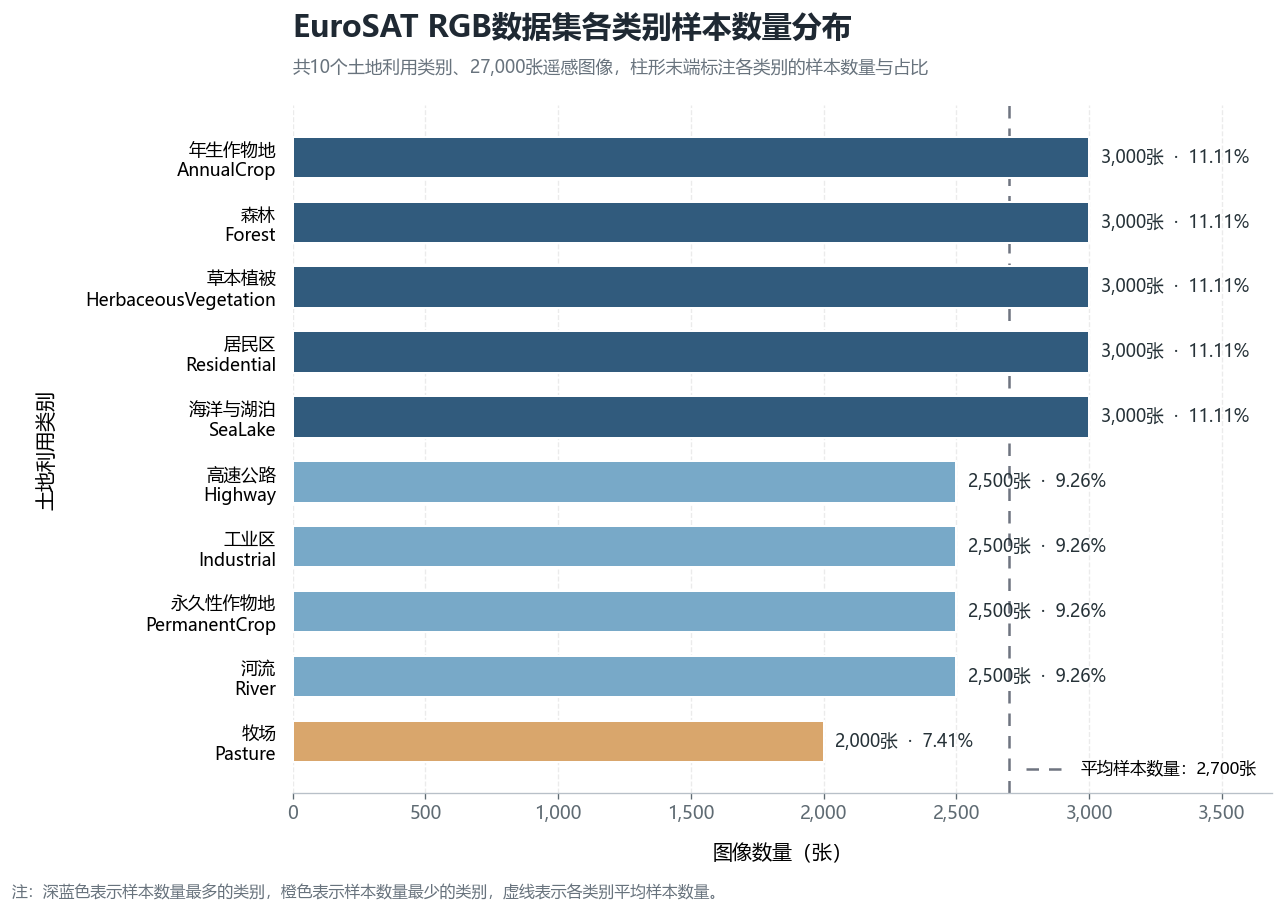

高清图表已保存至：D:\qy\junior\深度学习\课设\EuroSAT_RGB类别分布柱状图.png


In [5]:
# ==========================================
# 4.2.1 绘制EuroSAT RGB类别分布图（紧凑优化版）
# ==========================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


# 反转顺序，使样本数量较多的类别显示在图表上方
plot_df = distribution_df.iloc[::-1].reset_index(drop=True)

counts = plot_df["图像数量"].to_numpy()
percentages = plot_df["样本占比"].to_numpy()
labels = plot_df["图表标签"].tolist()

average_count = counts.mean()
max_count = counts.max()
min_count = counts.min()


# ------------------------------
# 设置柱形颜色
# ------------------------------
normal_color = "#78A9C8"   # 普通类别
max_color = "#315B7D"      # 样本数量最多
min_color = "#D9A66C"      # 样本数量最少

bar_colors = []

for count in counts:
    if count == max_count:
        bar_colors.append(max_color)
    elif count == min_count:
        bar_colors.append(min_color)
    else:
        bar_colors.append(normal_color)


# ------------------------------
# 创建画布
# 减小画布高度，使整体版面更加紧凑
# ------------------------------
fig, ax = plt.subplots(figsize=(12, 7.8))

y_positions = np.arange(len(plot_df))

bars = ax.barh(
    y_positions,
    counts,
    height=0.64,
    color=bar_colors,
    edgecolor="white",
    linewidth=1.2,
    zorder=3
)


# ------------------------------
# 添加柱形末端的数据标签
# ------------------------------
for bar, count, percentage in zip(
    bars,
    counts,
    percentages
):
    ax.text(
        count + 45,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}张  ·  {percentage:.2f}%",
        va="center",
        ha="left",
        fontsize=10.5,
        color="#263238",
        fontweight="medium"
    )


# ------------------------------
# 绘制平均样本数量参考线
# ------------------------------
ax.axvline(
    average_count,
    color="#5E6572",
    linestyle=(0, (5, 4)),
    linewidth=1.5,
    alpha=0.9,
    zorder=2,
    label=f"平均样本数量：{average_count:,.0f}张"
)


# ------------------------------
# 设置坐标轴
# ------------------------------
ax.set_yticks(y_positions)

ax.set_yticklabels(
    labels,
    fontsize=10.5
)

ax.set_xlabel(
    "图像数量（张）",
    fontsize=12,
    labelpad=12
)

ax.set_ylabel(
    "土地利用类别",
    fontsize=12,
    labelpad=16
)


# ------------------------------
# 设置主标题与副标题
# 缩短标题、副标题和图表之间的距离
# ------------------------------
fig.suptitle(
    "EuroSAT RGB数据集各类别样本数量分布",
    x=0.26,
    y=0.975,
    ha="left",
    va="top",
    fontsize=18,
    fontweight="bold",
    color="#1F2933"
)

fig.text(
    0.26,
    0.925,
    "共10个土地利用类别、27,000张遥感图像，"
    "柱形末端标注各类别的样本数量与占比",
    ha="left",
    va="top",
    fontsize=10.5,
    color="#68737D"
)


# ------------------------------
# 设置横坐标范围
# 为右侧数据标签预留空间
# ------------------------------
ax.set_xlim(
    0,
    max_count * 1.23
)

ax.set_xticks(
    np.arange(
        0,
        max_count + 501,
        500
    )
)

ax.set_xticklabels([
    f"{int(value):,}"
    for value in ax.get_xticks()
])


# ------------------------------
# 设置网格线
# ------------------------------
ax.xaxis.grid(
    True,
    linestyle="--",
    linewidth=0.8,
    alpha=0.25,
    zorder=0
)

ax.yaxis.grid(False)


# ------------------------------
# 设置坐标轴边框
# ------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_color("#B8C0C8")
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(
    axis="y",
    length=0,
    pad=10
)

ax.tick_params(
    axis="x",
    colors="#5F6B73"
)


# ------------------------------
# 添加平均值图例
# ------------------------------
ax.legend(
    loc="lower right",
    frameon=False,
    fontsize=10,
    handlelength=2.5
)


# ------------------------------
# 添加图下注释
# ------------------------------
fig.text(
    0.065,
    0.025,
    "注：深蓝色表示样本数量最多的类别，橙色表示样本数量最少的类别，"
    "虚线表示各类别平均样本数量。",
    ha="left",
    va="bottom",
    fontsize=9.5,
    color="#68737D"
)


# ------------------------------
# 调整整体布局
# 将图表主体上移，减少标题下方留白
# ------------------------------
plt.subplots_adjust(
    left=0.26,
    right=0.94,
    top=0.875,
    bottom=0.14
)


# ------------------------------
# 保存高清图片
# ------------------------------
output_path = Path(
    "EuroSAT_RGB类别分布柱状图.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.08
)

plt.show()

print(f"高清图表已保存至：{output_path.resolve()}")

##### 类别分布柱状图分析

类别分布图采用横向柱状图展示 EuroSAT RGB 数据集 10 个类别的图像数量，并在每个柱形末端同时标注样本数量和样本占比。

图中使用不同颜色突出类别数量差异：

- 深蓝色表示样本数量最多的类别；
- 浅蓝色表示样本数量处于中间水平的类别；
- 橙色表示样本数量最少的类别；
- 灰色虚线表示全部类别的平均样本数量。

全部类别的平均样本数量为：

$$
\bar{x}
=
\frac{27000}{10}
=
2700
$$

即平均每个类别包含 2,700 张图像。

从柱状图可以看出，AnnualCrop、Forest、HerbaceousVegetation、Residential 和 SeaLake 的样本数量均为 3,000 张，高于平均水平 300 张。

Highway、Industrial、PermanentCrop 和 River 的样本数量均为 2,500 张，低于平均水平 200 张。

Pasture 类别包含 2,000 张图像，比平均样本数量少 700 张，是图中与平均参考线距离最大的类别。

不同类别样本数量主要集中在 2,000～3,000 张之间，柱形长度虽然存在差异，但没有出现极端悬殊的情况。图表直观反映出该数据集并非完全均衡，但类别数量差异总体处于较小范围。

需要注意，柱状图反映的是原始样本数量，而不是模型分类难度。样本数量较多的类别不一定更容易识别，样本数量较少的类别也不一定必然具有较低分类准确率，后续仍需结合类别视觉特征及模型评价结果进行综合判断。

In [6]:
# ==========================================
# 4.2.1 类别分布均衡程度分析
# ==========================================

counts_original = distribution_df["图像数量"].to_numpy()

mean_count = counts_original.mean()
std_count = counts_original.std(ddof=0)

coefficient_of_variation = (
    std_count / mean_count
)

max_count = counts_original.max()
min_count = counts_original.min()

imbalance_ratio = max_count / min_count
range_count = max_count - min_count

max_classes = distribution_df.loc[
    distribution_df["图像数量"] == max_count,
    "类别英文名称"
].tolist()

min_classes = distribution_df.loc[
    distribution_df["图像数量"] == min_count,
    "类别英文名称"
].tolist()


balance_summary = pd.DataFrame({
    "统计指标": [
        "类别数量",
        "图像总数",
        "平均每类样本数",
        "样本数量标准差",
        "变异系数",
        "最大样本数",
        "最小样本数",
        "最大与最小样本数之差",
        "最大/最小样本数量比"
    ],
    "统计结果": [
        f"{len(counts_original)}类",
        f"{total_images:,}张",
        f"{mean_count:,.0f}张",
        f"{std_count:,.2f}张",
        f"{coefficient_of_variation:.4f}",
        f"{max_count:,}张",
        f"{min_count:,}张",
        f"{range_count:,}张",
        f"{imbalance_ratio:.2f}:1"
    ]
})

print("EuroSAT RGB类别分布均衡程度统计：")
display(balance_summary)

print("样本数量最多的类别：")
print("、".join(max_classes))

print("\n样本数量最少的类别：")
print("、".join(min_classes))

EuroSAT RGB类别分布均衡程度统计：


,统计指标,统计结果
0,类别数量,10类
1,图像总数,"27,000张"
2,平均每类样本数,"2,700张"
3,样本数量标准差,331.66张
4,变异系数,0.1228
5,最大样本数,"3,000张"
6,最小样本数,"2,000张"
7,最大与最小样本数之差,"1,000张"
8,最大/最小样本数量比,1.50:1


样本数量最多的类别：
AnnualCrop、Forest、HerbaceousVegetation、Residential、SeaLake

样本数量最少的类别：
Pasture


##### 类别分布均衡程度统计分析

本步骤进一步使用平均值、标准差、变异系数、极差和最大最小样本数量比，对数据集的类别均衡程度进行量化分析。

统计结果如下。

| 统计指标 | 统计结果 |
|:---|---:|
| 类别数量 | 10 类 |
| 图像总数 | 27,000 张 |
| 平均每类样本数 | 2,700 张 |
| 样本数量标准差 | 331.66 张 |
| 变异系数 | 0.1228 |
| 最大样本数 | 3,000 张 |
| 最小样本数 | 2,000 张 |
| 最大与最小样本数之差 | 1,000 张 |
| 最大/最小样本数量比 | 1.50∶1 |

本实验使用总体标准差，即在计算标准差时设置 `ddof=0`。计算公式为：

$$
\sigma
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
(x_i-\bar{x})^2
}
$$

其中，$N=10$ 表示类别数量，$x_i$ 表示第 $i$ 个类别的样本数量，$\bar{x}=2700$ 表示平均每类样本数。

计算得到类别样本数量标准差为：

$$
\sigma=331.66
$$

标准差相当于平均样本数量的约 12.28%。变异系数的计算公式为：

$$
CV
=
\frac{\sigma}{\bar{x}}
$$

代入本实验结果可得：

$$
CV
=
\frac{331.66}{2700}
\approx
0.1228
$$

变异系数用于衡量样本数量相对于平均水平的离散程度。当前结果表明，各类别样本数量的相对波动约为 12.28%，类别间存在一定差异，但差异程度不高。

最大样本数与最小样本数之差为：

$$
3000-2000=1000
$$

最大类别与最小类别的样本数量比为：

$$
\frac{3000}{2000}
=
1.50
$$

即最大类别的样本数量是最小类别的 1.5 倍。

样本数量最多的类别共有 5 个，分别为 AnnualCrop、Forest、HerbaceousVegetation、Residential 和 SeaLake；样本数量最少的类别为 Pasture。

综合标准差、变异系数和最大最小样本比可以判断，EuroSAT RGB 数据集存在轻微的类别数量差异，但未达到严重类别不平衡的程度。

In [7]:
# ==========================================
# 4.2.1 自动生成类别分布分析结论
# ==========================================

if coefficient_of_variation < 0.10:
    balance_level = "较为均衡"
elif coefficient_of_variation < 0.20:
    balance_level = "整体较为均衡，存在轻微差异"
else:
    balance_level = "存在较明显的类别不平衡"


print("=" * 68)
print("EuroSAT RGB类别分布分析结论")
print("=" * 68)

print(
    f"数据集共包含{len(counts_original)}个类别，"
    f"总计{total_images:,}张遥感图像。"
)

print(
    f"平均每个类别包含{mean_count:,.0f}张图像，"
    f"类别样本数量标准差为{std_count:,.2f}张，"
    f"变异系数为{coefficient_of_variation:.4f}。"
)

print(
    f"样本数量最多的类别为"
    f"{'、'.join(max_classes)}，"
    f"每类包含{max_count:,}张图像。"
)

print(
    f"样本数量最少的类别为"
    f"{'、'.join(min_classes)}，"
    f"包含{min_count:,}张图像。"
)

print(
    f"最大类别与最小类别的样本数量比为"
    f"{imbalance_ratio:.2f}:1，"
    f"相差{range_count:,}张图像。"
)

print(
    f"综合样本数量差异和变异系数判断，"
    f"该数据集类别分布{balance_level}。"
)

print(
    "后续划分训练集、验证集和测试集时，"
    "仍需采用分层抽样方法，"
    "保证三个子数据集中的类别比例与原始数据集基本一致。"
)

EuroSAT RGB类别分布分析结论
数据集共包含10个类别，总计27,000张遥感图像。
平均每个类别包含2,700张图像，类别样本数量标准差为331.66张，变异系数为0.1228。
样本数量最多的类别为AnnualCrop、Forest、HerbaceousVegetation、Residential、SeaLake，每类包含3,000张图像。
样本数量最少的类别为Pasture，包含2,000张图像。
最大类别与最小类别的样本数量比为1.50:1，相差1,000张图像。
综合样本数量差异和变异系数判断，该数据集类别分布整体较为均衡，存在轻微差异。
后续划分训练集、验证集和测试集时，仍需采用分层抽样方法，保证三个子数据集中的类别比例与原始数据集基本一致。


##### 类别分布可视化综合结论

本步骤完成了 EuroSAT RGB 数据集的类别数量整理、样本占比计算、柱状图展示和类别均衡程度统计。

主要结果如下：

1. 数据集共包含 10 个土地利用类别，总计 27,000 张遥感图像；
2. 平均每个类别包含 2,700 张图像；
3. 类别样本数量标准差为 331.66 张；
4. 类别样本数量变异系数为 0.1228；
5. 最大类别样本数为 3,000 张，最小类别样本数为 2,000 张；
6. 最大类别与最小类别相差 1,000 张图像；
7. 最大与最小类别的样本数量比为 1.50∶1。

样本数量最多的类别包括 AnnualCrop、Forest、HerbaceousVegetation、Residential 和 SeaLake，每类均包含 3,000 张图像；样本数量最少的类别为 Pasture，共包含 2,000 张图像。

根据本实验代码中设定的判定规则：

- 当变异系数小于 0.10 时，判断为“较为均衡”；
- 当变异系数位于 0.10～0.20 时，判断为“整体较为均衡，存在轻微差异”；
- 当变异系数不小于 0.20 时，判断为“存在较明显的类别不平衡”。

本实验的变异系数为 0.1228，因此按照上述规则，数据集类别分布被判定为“整体较为均衡，存在轻微差异”。

需要说明的是，该阈值是本实验为了辅助解释类别分布而设定的经验性判断规则，并不是适用于所有数据集的统一统计标准。因此，结论应结合最大最小样本数量比和实际类别分布共同理解，而不能仅依赖单一阈值。

当前类别数量差异尚不需要立即采用过采样、欠采样等强制均衡方法，但在后续训练集、验证集和测试集划分过程中，仍应采用分层抽样，使各子集中的类别比例与原始数据集保持一致。

在模型训练完成后，还应进一步比较各类别的 Precision、Recall 和 F1-score，判断样本数量较少的 Pasture 类别是否出现明显的性能下降，再决定是否需要使用类别权重或加权采样策略。

#### 4.2.2 各类别代表性样本展示

为直观观察EuroSAT RGB数据集中不同土地利用类别的视觉特征，本实验在固定随机种子条件下，从每个类别中随机抽取3张代表性图像，共展示30张遥感图像。通过对比不同类别在颜色、纹理、空间结构及地物排列方式等方面的差异，可以初步判断各类别的可区分性，并为后续易混淆类别分析、数据增强策略设计及模型结构选择提供依据。

In [8]:
# ==========================================
# 4.2.2 抽取各类别代表性样本
# ==========================================

import random
from pathlib import Path

import pandas as pd
from PIL import Image


# ------------------------------
# 1. 基础参数
# ------------------------------
SAMPLE_SEED = 42
SAMPLES_PER_CLASS = 3

# Notebook重启后变量可能不存在，因此增加备用定义
if "DATA_DIR" not in globals():
    DATA_DIR = Path(
        r"D:\qy\junior\深度学习\课设\EuroSAT_RGB"
    )

DATA_DIR = Path(DATA_DIR).resolve()


# ------------------------------
# 2. 类别中英文名称
# ------------------------------
if "class_name_cn" not in globals():
    class_name_cn = {
        "AnnualCrop": "年生作物地",
        "Forest": "森林",
        "HerbaceousVegetation": "草本植被",
        "Highway": "高速公路",
        "Industrial": "工业区",
        "Pasture": "牧场",
        "PermanentCrop": "永久性作物地",
        "Residential": "居民区",
        "River": "河流",
        "SeaLake": "海洋与湖泊"
    }


# ------------------------------
# 3. 图像扩展名
# ------------------------------
VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}


# ------------------------------
# 4. 图表类别排列顺序
# 将部分视觉相似类别放在同一行，便于比较
# ------------------------------
display_class_order = [
    "AnnualCrop",
    "PermanentCrop",
    "Forest",
    "HerbaceousVegetation",
    "Pasture",
    "Highway",
    "Industrial",
    "Residential",
    "River",
    "SeaLake"
]


# ------------------------------
# 5. 使用局部随机数生成器
# 不改变Notebook其他代码的随机状态
# ------------------------------
sample_rng = random.Random(SAMPLE_SEED)

representative_samples = {}
selection_records = []


# ------------------------------
# 6. 从每个类别中抽取3张图像
# ------------------------------
for class_name in display_class_order:
    class_dir = DATA_DIR / class_name

    if not class_dir.exists():
        raise FileNotFoundError(
            f"未找到类别文件夹：{class_dir}"
        )

    image_paths = sorted([
        file_path
        for file_path in class_dir.iterdir()
        if file_path.is_file()
        and file_path.suffix.lower() in VALID_EXTENSIONS
    ])

    if len(image_paths) < SAMPLES_PER_CLASS:
        raise ValueError(
            f"{class_name}类别只有{len(image_paths)}张图像，"
            f"不足以抽取{SAMPLES_PER_CLASS}张样本。"
        )

    selected_paths = sample_rng.sample(
        image_paths,
        SAMPLES_PER_CLASS
    )

    representative_samples[class_name] = selected_paths

    selection_records.append({
        "类别英文名称": class_name,
        "类别中文名称": class_name_cn[class_name],
        "样本1": selected_paths[0].name,
        "样本2": selected_paths[1].name,
        "样本3": selected_paths[2].name
    })


# ------------------------------
# 7. 输出抽样结果
# ------------------------------
sample_selection_df = pd.DataFrame(selection_records)

print(
    f"随机种子：{SAMPLE_SEED}"
)

print(
    f"每个类别抽取样本数：{SAMPLES_PER_CLASS}"
)

print(
    f"共抽取代表性图像："
    f"{len(display_class_order) * SAMPLES_PER_CLASS}张"
)

print("\n各类别代表性样本文件：")

display(sample_selection_df)


# ------------------------------
# 8. 保存抽样记录
# ------------------------------
sample_selection_df.to_csv(
    "EuroSAT_RGB代表性样本抽取记录.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "\n抽样记录已保存为："
    "EuroSAT_RGB代表性样本抽取记录.csv"
)

随机种子：42
每个类别抽取样本数：3
共抽取代表性图像：30张

各类别代表性样本文件：


,类别英文名称,类别中文名称,样本1,样本2,样本3
0,AnnualCrop,年生作物地,AnnualCrop_656.jpg,AnnualCrop_1409.jpg,AnnualCrop_1090.jpg
1,PermanentCrop,永久性作物地,PermanentCrop_2011.jpg,PermanentCrop_1901.jpg,PermanentCrop_1821.jpg
2,Forest,森林,Forest_1512.jpg,Forest_1376.jpg,Forest_793.jpg
3,HerbaceousVegetation,草本植被,HerbaceousVegetation_308.jpg,HerbaceousVegetation_1319.jpg,HerbaceousVegetation_475.jpg
4,Pasture,牧场,Pasture_1777.jpg,Pasture_1057.jpg,Pasture_1053.jpg
5,Highway,高速公路,Highway_1343.jpg,Highway_1804.jpg,Highway_1856.jpg
6,Industrial,工业区,Industrial_610.jpg,Industrial_968.jpg,Industrial_1096.jpg
7,Residential,居民区,Residential_367.jpg,Residential_1731.jpg,Residential_938.jpg
8,River,河流,River_758.jpg,River_295.jpg,River_1810.jpg
9,SeaLake,海洋与湖泊,SeaLake_2654.jpg,SeaLake_470.jpg,SeaLake_2023.jpg



抽样记录已保存为：EuroSAT_RGB代表性样本抽取记录.csv


##### 代表性样本抽取方法与结果分析

本步骤采用固定随机种子 42，从 EuroSAT RGB 数据集的 10 个土地利用类别中分别随机抽取 3 张图像，共获得 30 张代表性样本。

抽样参数如下。

| 抽样项目 | 参数设置 |
|:---|---:|
| 随机种子 | 42 |
| 类别数量 | 10 类 |
| 每类抽取数量 | 3 张 |
| 抽取样本总数 | 30 张 |
| 抽样方式 | 各类别内部独立随机抽取 |

本次抽取的具体图像文件如下。

| 类别英文名称 | 类别中文名称 | 样本1 | 样本2 | 样本3 |
|:---|:---|:---|:---|:---|
| AnnualCrop | 年生作物地 | AnnualCrop_656.jpg | AnnualCrop_1409.jpg | AnnualCrop_1090.jpg |
| PermanentCrop | 永久性作物地 | PermanentCrop_2011.jpg | PermanentCrop_1901.jpg | PermanentCrop_1821.jpg |
| Forest | 森林 | Forest_1512.jpg | Forest_1376.jpg | Forest_793.jpg |
| HerbaceousVegetation | 草本植被 | HerbaceousVegetation_308.jpg | HerbaceousVegetation_1319.jpg | HerbaceousVegetation_475.jpg |
| Pasture | 牧场 | Pasture_1777.jpg | Pasture_1057.jpg | Pasture_1053.jpg |
| Highway | 高速公路 | Highway_1343.jpg | Highway_1804.jpg | Highway_1856.jpg |
| Industrial | 工业区 | Industrial_610.jpg | Industrial_968.jpg | Industrial_1096.jpg |
| Residential | 居民区 | Residential_367.jpg | Residential_1731.jpg | Residential_938.jpg |
| River | 河流 | River_758.jpg | River_295.jpg | River_1810.jpg |
| SeaLake | 海洋与湖泊 | SeaLake_2654.jpg | SeaLake_470.jpg | SeaLake_2023.jpg |

固定随机种子后，在原始文件顺序不发生变化的条件下，重新运行代码可以获得相同的抽样结果，有利于后续图表复现和实验结果核查。

每个类别均抽取相同数量的图像，因此本次可视化不会受到原始类别样本数量差异的影响。即使某些类别原始样本数量为 3,000 张，另一些类别只有 2,000 张，在代表性样本图中仍统一展示 3 张图像。

抽样记录已保存为 CSV 文件，使每张展示图像都能够追溯到原始类别和文件名。

需要说明的是，本步骤采用的是固定随机抽样。这里的“代表性样本”主要指用于观察类别基本视觉特征的示例图像，并不表示这 3 张图像能够完整代表该类别全部样本的统计分布。

In [9]:
# ==========================================
# 4.2.2 检查代表性样本读取情况
# ==========================================

sample_check_records = []
sample_read_errors = []

for class_name, selected_paths in representative_samples.items():
    for sample_index, image_path in enumerate(
        selected_paths,
        start=1
    ):
        try:
            with Image.open(image_path) as image:
                image.load()

                sample_check_records.append({
                    "类别": class_name,
                    "样本序号": sample_index,
                    "文件名": image_path.name,
                    "图像尺寸": f"{image.width}×{image.height}",
                    "颜色模式": image.mode,
                    "文件格式": image.format,
                    "读取状态": "成功"
                })

        except Exception as error:
            sample_read_errors.append({
                "类别": class_name,
                "文件名": image_path.name,
                "错误信息": str(error)
            })


sample_check_df = pd.DataFrame(sample_check_records)

print(
    f"代表性样本总数："
    f"{len(display_class_order) * SAMPLES_PER_CLASS}"
)

print(
    f"成功读取数量：{len(sample_check_records)}"
)

print(
    f"读取失败数量：{len(sample_read_errors)}"
)


if sample_read_errors:
    print("\n存在读取失败的代表性样本：")
    display(pd.DataFrame(sample_read_errors))

else:
    print("\n全部代表性样本均能够正常读取。")


print("\n代表性样本属性汇总：")

sample_property_summary = pd.DataFrame({
    "检查项目": [
        "图像数量",
        "图像尺寸",
        "颜色模式",
        "文件格式"
    ],
    "检查结果": [
        f"{len(sample_check_records)}张",
        "、".join(
            sorted(sample_check_df["图像尺寸"].unique())
        ),
        "、".join(
            sorted(sample_check_df["颜色模式"].unique())
        ),
        "、".join(
            sorted(sample_check_df["文件格式"].unique())
        )
    ]
})

display(sample_property_summary)

代表性样本总数：30
成功读取数量：30
读取失败数量：0

全部代表性样本均能够正常读取。

代表性样本属性汇总：


,检查项目,检查结果
0,图像数量,30张
1,图像尺寸,64×64
2,颜色模式,RGB
3,文件格式,JPEG


##### 代表性样本完整性与属性检查分析

本步骤对抽取出的 30 张代表性图像进行了逐张读取和属性检查。

检查结果如下。

| 检查项目 | 检查结果 |
|:---|---:|
| 代表性样本总数 | 30 张 |
| 成功读取数量 | 30 张 |
| 读取失败数量 | 0 张 |
| 图像尺寸 | 全部为 $64\times64$ |
| 颜色模式 | 全部为 RGB |
| 文件格式 | 全部为 JPEG |

全部 30 张图像均能够使用 PIL 正常打开和读取，未出现路径错误、文件损坏或图像格式无法识别等问题。

所有代表性样本的尺寸均为：

$$
64\times64
$$

颜色模式均为 RGB，文件格式均为 JPEG。该结果与 4.1 节对全部 27,000 张图像进行完整性检查时得到的结果一致，说明本次抽取的样本没有出现异常属性。

统一的图像尺寸、颜色模式和文件格式保证了后续可视化时各类别图像能够采用相同的显示比例，也有利于后续构建统一的数据预处理与模型输入流程。

本步骤未发现读取失败样本，因此不需要重新抽取或替换图像，可以直接使用当前 30 张样本进行类别视觉特征观察。

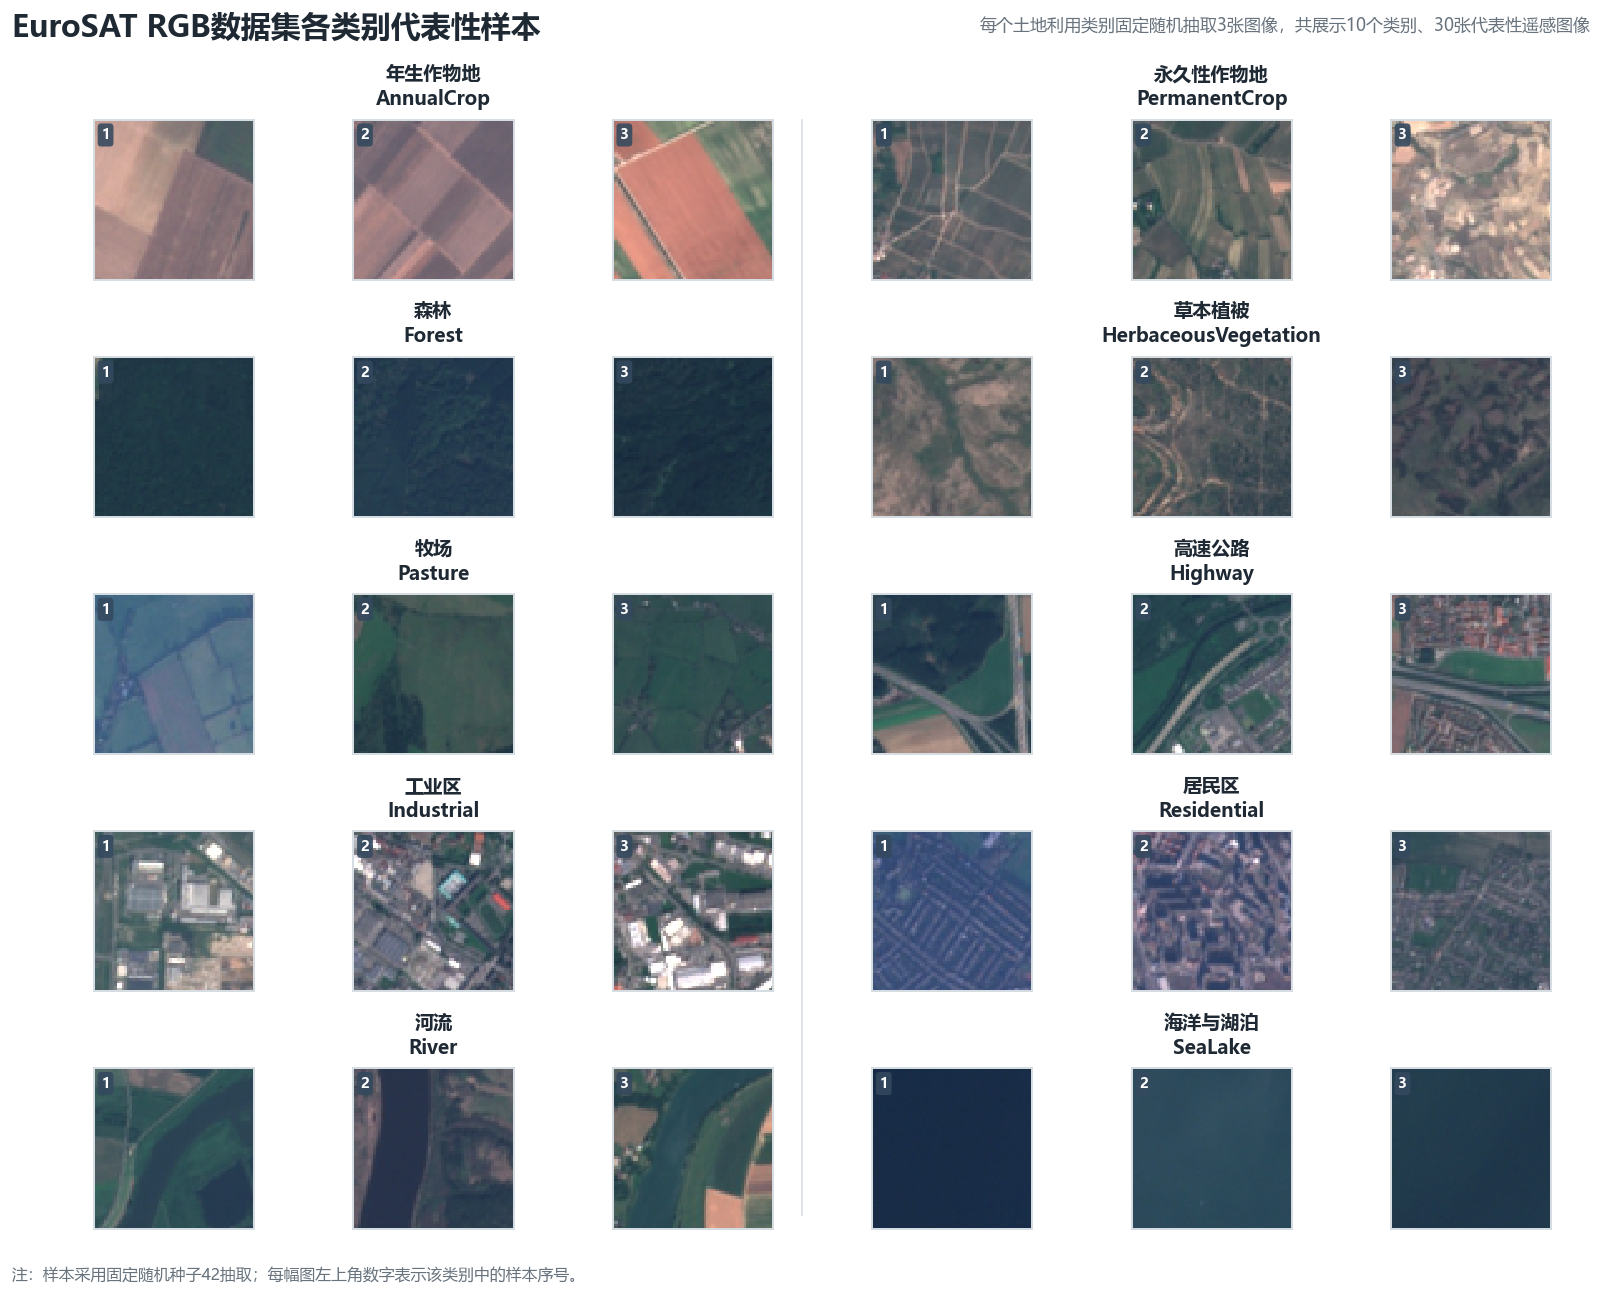

高清样本展示图已保存至：D:\qy\junior\深度学习\课设\EuroSAT_RGB各类别代表性样本.png


In [12]:
# ==========================================
# 4.2.2 绘制各类别代表性样本展示图（优化版）
# ==========================================

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image


# ------------------------------
# 1. 每行展示两个类别
# ------------------------------
class_pairs = [
    ("AnnualCrop", "PermanentCrop"),
    ("Forest", "HerbaceousVegetation"),
    ("Pasture", "Highway"),
    ("Industrial", "Residential"),
    ("River", "SeaLake")
]


# ------------------------------
# 2. 画面样式参数
# ------------------------------
border_color = "#D5DCE2"
title_color = "#1F2933"
subtitle_color = "#68737D"
sample_label_color = "#34495E"


# ------------------------------
# 3. 创建5行×6列画布
# ------------------------------
fig, axes = plt.subplots(
    nrows=5,
    ncols=6,
    figsize=(14, 11)
)


# ------------------------------
# 4. 绘制全部30张图像
# ------------------------------
for row_index, class_pair in enumerate(class_pairs):

    for group_index, class_name in enumerate(class_pair):

        # 左侧类别使用第0—2列
        # 右侧类别使用第3—5列
        start_column = group_index * 3

        selected_paths = representative_samples[class_name]

        for sample_index, image_path in enumerate(selected_paths):
            column_index = start_column + sample_index
            ax = axes[row_index, column_index]

            with Image.open(image_path) as image:
                rgb_image = image.convert("RGB")
                ax.imshow(
                    rgb_image,
                    interpolation="nearest"
                )

            ax.set_xticks([])
            ax.set_yticks([])

            # 隐藏原始边框
            for spine in ax.spines.values():
                spine.set_visible(False)

            # 添加浅色细边框
            image_border = Rectangle(
                (0, 0),
                1,
                1,
                transform=ax.transAxes,
                fill=False,
                edgecolor=border_color,
                linewidth=1.2,
                clip_on=False
            )
            ax.add_patch(image_border)

            # 左上角添加样本序号
            ax.text(
                0.045,
                0.955,
                f"{sample_index + 1}",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=8.5,
                color="white",
                fontweight="bold",
                bbox={
                    "boxstyle": "round,pad=0.25",
                    "facecolor": sample_label_color,
                    "edgecolor": "none",
                    "alpha": 0.88
                }
            )

            # 只在每组中间图像上方显示类别标题
            if sample_index == 1:
                ax.set_title(
                    f"{class_name_cn[class_name]}\n{class_name}",
                    fontsize=11.5,
                    fontweight="bold",
                    color=title_color,
                    pad=9,
                    linespacing=1.25
                )


# ------------------------------
# 5. 主标题（左侧）
# ------------------------------
fig.suptitle(
    "EuroSAT RGB数据集各类别代表性样本",
    x=0.03,
    y=0.982,
    ha="left",
    va="top",
    fontsize=18,
    fontweight="bold",
    color=title_color
)


# ------------------------------
# 6. 副标题（右侧）
# 放到主标题右侧，避免上下遮挡
# ------------------------------
fig.text(
    0.97,
    0.978,
    "每个土地利用类别固定随机抽取3张图像，共展示10个类别、30张代表性遥感图像",
    ha="right",
    va="top",
    fontsize=10.2,
    color=subtitle_color
)


# ------------------------------
# 7. 添加中间分隔线
# 用于区分每行左右两个类别
# ------------------------------
separator = plt.Line2D(
    [0.50, 0.50],
    [0.07, 0.90],
    transform=fig.transFigure,
    color="#D9DEE3",
    linewidth=1.0,
    linestyle="-"
)
fig.add_artist(separator)


# ------------------------------
# 8. 添加底部说明
# ------------------------------
fig.text(
    0.03,
    0.018,
    "注：样本采用固定随机种子42抽取；每幅图左上角数字表示该类别中的样本序号。",
    ha="left",
    va="bottom",
    fontsize=9.5,
    color=subtitle_color
)


# ------------------------------
# 9. 调整布局
# 顶部区域更紧凑，避免大面积留白
# ------------------------------
plt.subplots_adjust(
    left=0.055,
    right=0.97,
    top=0.90,
    bottom=0.06,
    wspace=0.08,
    hspace=0.48
)


# ------------------------------
# 10. 保存高清图片
# ------------------------------
sample_figure_path = Path(
    "EuroSAT_RGB各类别代表性样本.png"
)

plt.savefig(
    sample_figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.08
)

plt.show()

print(
    f"高清样本展示图已保存至：{sample_figure_path.resolve()}"
)

##### 各类别代表性样本可视化分析

可视化结果按照统一版式展示了 EuroSAT RGB 数据集的 10 个类别，每个类别包含 3 张固定随机抽取的遥感图像。

从图像的主体颜色、纹理密度、边缘结构和地物空间排列方式来看，不同类别具有一定的视觉差异。

##### 年生作物地与永久性作物地

AnnualCrop 样本主要表现为面积较大的规则农田地块，颜色以浅棕色、红褐色和绿色为主，地块内部纹理相对均匀，边界较为明显。

PermanentCrop 同样包含农业地块，但其地块通常更加狭长、细碎或不规则，局部道路、田埂和种植纹理更加复杂。

两类均属于农业用地，在颜色和地块结构方面具有一定相似性，因此可能成为后续模型分类中的候选易混淆类别。

##### 森林、草本植被与牧场

Forest 样本整体呈深蓝绿色，区域连续性较强，内部明暗变化较小，地物边缘不明显，表现出较为密集和均匀的植被覆盖特征。

HerbaceousVegetation 样本颜色以灰绿色、棕绿色为主，内部纹理和地表斑块变化比 Forest 更明显，局部可能包含裸地、道路或不同植被区域。

Pasture 样本以绿色地块为主，通常能够观察到一定的田块边界或区域分割，其纹理复杂度介于规则农田与连续植被之间。

这三个类别均以植被为主要地物，在颜色和纹理上存在一定重叠，需要模型结合更细致的局部结构和空间纹理进行区分。

##### 高速公路

Highway 样本中可以观察到明显的线性道路结构，包括直线道路、弯曲道路、交叉口和道路两侧的其他地物。

道路通常与周围农田、植被或建筑形成较强的几何对比。与自然地物类别相比，高速公路具有较明显的长条形结构和连续边缘，是该类别的重要视觉识别依据。

但当道路在整幅图像中占比较低，或周围区域包含大量植被和建筑时，也可能增加分类难度。

##### 工业区与居民区

Industrial 样本中通常包含面积较大的亮色建筑屋顶、厂房和规则排列的人工设施，图像具有较强的明暗对比和明显的矩形边缘。

Residential 样本主要表现为密集的小型建筑群和道路网络，建筑尺度相对较小，排列更加密集，纹理细节更加丰富。

两类均属于人工建筑区域，都包含建筑物、道路和大量几何边缘，因此可能发生视觉混淆。模型需要结合建筑尺度、排列密度和空间结构进行区分。

##### 河流与海洋湖泊

River 样本中的水体通常呈狭长、弯曲或带状分布，能够观察到较明显的河岸边界，水体两侧常伴随农田、植被或居民区域。

SeaLake 样本主要由大面积连续水体构成，整体颜色较深且较为均匀，内部纹理和边缘结构较少。

两类都以水体为主体，颜色特征较为接近，但空间形态存在差异。River 更强调线性、弯曲的水体结构，SeaLake 则更接近大面积均匀区域。

综合观察可知，EuroSAT RGB 的不同类别在颜色、纹理和空间结构上具有可用于分类的视觉信息，但部分类别之间仍存在明显的特征重叠。这为后续开展视觉特征统计和易混淆类别分析提供了依据。

In [11]:
# ==========================================
# 4.2.2 代表性样本展示实验总结
# ==========================================

print("=" * 68)
print("EuroSAT RGB各类别代表性样本展示总结")
print("=" * 68)

print(
    f"本实验采用固定随机种子{SAMPLE_SEED}，"
    f"从EuroSAT RGB数据集的"
    f"{len(display_class_order)}个类别中，"
    f"每类随机抽取{SAMPLES_PER_CLASS}张图像。"
)

print(
    f"共抽取并展示"
    f"{len(display_class_order) * SAMPLES_PER_CLASS}"
    f"张代表性遥感图像。"
)

print(
    f"全部代表性样本尺寸均为64×64像素，"
    f"颜色模式为RGB，文件格式为JPEG。"
)

print(
    "各类别图像在主体颜色、纹理密度、"
    "地物排列方式和空间结构等方面存在一定差异。"
)

print(
    "其中，年生作物地与永久性作物地、"
    "森林与草本植被、工业区与居民区、"
    "河流与海洋湖泊等类别可能具有相似视觉特征，"
    "需要在后续实验中进一步分析。"
)

print(
    "本步骤生成的代表性样本图可用于课程设计报告中的"
    "数据可视化与图像特征分析。"
)

EuroSAT RGB各类别代表性样本展示总结
本实验采用固定随机种子42，从EuroSAT RGB数据集的10个类别中，每类随机抽取3张图像。
共抽取并展示30张代表性遥感图像。
全部代表性样本尺寸均为64×64像素，颜色模式为RGB，文件格式为JPEG。
各类别图像在主体颜色、纹理密度、地物排列方式和空间结构等方面存在一定差异。
其中，年生作物地与永久性作物地、森林与草本植被、工业区与居民区、河流与海洋湖泊等类别可能具有相似视觉特征，需要在后续实验中进一步分析。
本步骤生成的代表性样本图可用于课程设计报告中的数据可视化与图像特征分析。


##### 各类别代表性样本展示综合结论

本步骤采用固定随机种子 42，从 EuroSAT RGB 数据集的 10 个类别中分别随机抽取 3 张图像，共展示 30 张代表性遥感图像。

主要结果如下：

1. 10 个类别均成功抽取 3 张图像，未出现类别遗漏；
2. 30 张代表性样本均能够正常读取；
3. 所有图像尺寸均为 $64\times64$ 像素；
4. 所有图像颜色模式均为 RGB；
5. 所有图像文件格式均为 JPEG；
6. 抽样记录已经保存，可以根据类别名称和文件名追溯原始图像；
7. 各类别在主体颜色、纹理密度、边缘数量和空间排列方式方面表现出一定差异。

通过可视化观察可以初步发现以下可能具有相似视觉特征的类别组合：

- AnnualCrop 与 PermanentCrop：均包含农业地块和规则田间边界；
- Forest、HerbaceousVegetation 与 Pasture：均以绿色植被区域为主体；
- Industrial 与 Residential：均包含建筑、道路和人工几何边缘；
- River 与 SeaLake：均以深色水体为主要视觉内容。

上述判断仅来源于每类 3 张随机样本的人工观察，不能直接作为模型真实混淆关系的最终结论。

原因主要包括：

- 每类仅展示 3 张图像，样本数量较少；
- 同一类别内部可能存在较大的颜色和空间结构变化；
- 人工观察容易受到显示亮度、样本选择和主观判断影响；
- 模型学习的是多层卷积特征，不完全等同于人工观察到的颜色和轮廓。

因此，后续实验还需要对全部 27,000 张图像进行亮度、色彩、对比度、边缘强度和信息熵等视觉特征统计，并在模型训练完成后结合混淆矩阵、Precision、Recall、F1-score 和错误分类样本进一步验证类别混淆情况。

本步骤生成的代表性样本图能够作为数据集内容展示和视觉特征初步分析的依据。

#### 4.2.3 类别视觉特征分析

为进一步量化EuroSAT RGB数据集中不同土地利用类别的视觉差异，本实验对全部27,000张遥感图像进行特征统计。分析指标包括RGB三个颜色通道的平均强度、图像亮度、色彩饱和度、灰度对比度、边缘强度和信息熵。其中，RGB均值与亮度反映图像的整体色彩和明暗特征，饱和度反映颜色鲜明程度，灰度对比度反映图像内部明暗变化，边缘强度反映地物轮廓和空间结构复杂程度，信息熵用于衡量图像纹理及信息丰富程度。通过类别间特征对比，可以为后续数据增强策略、模型结构选择及分类结果分析提供依据。

In [13]:
# ==========================================
# 4.2.3 类别视觉特征分析：环境与参数设置
# ==========================================

from pathlib import Path
from collections import defaultdict
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from PIL import Image


# ------------------------------
# 1. 数据集路径
# ------------------------------
if "DATA_DIR" not in globals():
    DATA_DIR = Path(
        r"D:\qy\junior\深度学习\课设\EuroSAT_RGB"
    )

DATA_DIR = Path(DATA_DIR).resolve()

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"未找到数据集目录：{DATA_DIR}"
    )


# ------------------------------
# 2. 类别中英文名称
# ------------------------------
if "class_name_cn" not in globals():
    class_name_cn = {
        "AnnualCrop": "年生作物地",
        "Forest": "森林",
        "HerbaceousVegetation": "草本植被",
        "Highway": "高速公路",
        "Industrial": "工业区",
        "Pasture": "牧场",
        "PermanentCrop": "永久性作物地",
        "Residential": "居民区",
        "River": "河流",
        "SeaLake": "海洋与湖泊"
    }


# ------------------------------
# 3. 类别显示顺序
# ------------------------------
visual_class_order = [
    "AnnualCrop",
    "PermanentCrop",
    "Forest",
    "HerbaceousVegetation",
    "Pasture",
    "Highway",
    "Industrial",
    "Residential",
    "River",
    "SeaLake"
]


# ------------------------------
# 4. 有效图像扩展名
# ------------------------------
VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}


# ------------------------------
# 5. 特征缓存文件
# ------------------------------
IMAGE_FEATURE_PATH = Path(
    "EuroSAT_RGB图像视觉特征明细.csv"
)

CLASS_FEATURE_PATH = Path(
    "EuroSAT_RGB类别视觉特征统计.csv"
)

# 第一次运行保持False即可。
# 如果修改了特征计算方式，希望重新计算全部图像，则改成True。
RECOMPUTE_FEATURES = False


print(f"数据集路径：{DATA_DIR}")
print(f"类别数量：{len(visual_class_order)}")
print(f"图像特征缓存文件：{IMAGE_FEATURE_PATH.resolve()}")

数据集路径：D:\qy\junior\深度学习\课设\EuroSAT_RGB
类别数量：10
图像特征缓存文件：D:\qy\junior\深度学习\课设\EuroSAT_RGB图像视觉特征明细.csv


##### 图像视觉特征指标说明

本步骤从颜色、明暗、灰度变化、边缘结构和信息复杂度等角度，对 EuroSAT RGB 图像进行全局视觉特征提取。

每张图像共提取以下 8 项基础数值特征。

| 视觉特征 | 含义 | 主要反映内容 |
|:---|:---|:---|
| R 通道均值 | 图像红色通道的平均像素强度 | 图像整体红色成分 |
| G 通道均值 | 图像绿色通道的平均像素强度 | 图像整体绿色成分 |
| B 通道均值 | 图像蓝色通道的平均像素强度 | 图像整体蓝色成分 |
| 平均亮度 | 灰度图像的平均像素强度 | 图像整体明暗水平 |
| 平均饱和度 | 图像饱和度分量的平均值 | 颜色鲜明程度 |
| 灰度对比度 | 灰度像素的标准差 | 图像明暗变化程度 |
| 边缘强度 | 灰度图像边缘响应的平均强度 | 地物边界和人工结构丰富程度 |
| 信息熵 | 灰度像素概率分布的信息量 | 图像纹理与灰度复杂程度 |

灰度对比度使用灰度像素标准差进行衡量，其计算形式为：

$$
C
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
(g_i-\bar{g})^2
}
$$

其中，$g_i$ 表示第 $i$ 个灰度像素，$\bar{g}$ 表示整幅图像的平均灰度值，$N$ 表示图像像素总数。

信息熵的计算形式为：

$$
H
=
-\sum_{k=0}^{255}
p_k\log_2 p_k
$$

其中，$p_k$ 表示灰度值 $k$ 在图像中出现的概率。信息熵越高，通常表示图像包含的灰度层次和纹理信息越丰富；信息熵越低，通常表示图像区域更加均匀。

这些指标属于人工设计的全局统计特征，能够帮助理解不同土地利用类别在颜色和纹理方面的总体差异，但不能完全代替卷积神经网络学习到的多层局部特征。

In [14]:
# ==========================================
# 4.2.3 定义单张图像视觉特征计算函数
# ==========================================

def calculate_image_features(image_path: Path) -> dict:
    """
    读取一张RGB图像，并计算颜色、亮度、对比度、
    边缘强度和信息熵等视觉特征。
    """

    with Image.open(image_path) as image:
        rgb_image = image.convert("RGB")

    image_array = np.asarray(
        rgb_image,
        dtype=np.float32
    )

    # --------------------------
    # 1. RGB通道平均值
    # --------------------------
    red_mean = float(
        image_array[:, :, 0].mean()
    )

    green_mean = float(
        image_array[:, :, 1].mean()
    )

    blue_mean = float(
        image_array[:, :, 2].mean()
    )


    # --------------------------
    # 2. 灰度亮度
    # 使用常见的RGB加权公式
    # --------------------------
    gray = (
        0.299 * image_array[:, :, 0]
        + 0.587 * image_array[:, :, 1]
        + 0.114 * image_array[:, :, 2]
    )

    brightness_mean = float(gray.mean())


    # --------------------------
    # 3. 饱和度
    # 使用RGB最大值和最小值的相对差异计算
    # --------------------------
    rgb_max = image_array.max(axis=2)
    rgb_min = image_array.min(axis=2)

    saturation = np.where(
        rgb_max > 0,
        (rgb_max - rgb_min) / (rgb_max + 1e-6),
        0
    )

    saturation_mean = float(
        saturation.mean() * 100
    )


    # --------------------------
    # 4. 灰度对比度
    # 灰度像素值的标准差
    # --------------------------
    contrast_std = float(gray.std())


    # --------------------------
    # 5. 边缘强度
    # 通过水平、垂直方向灰度梯度计算
    # --------------------------
    gradient_x = np.diff(
        gray,
        axis=1,
        append=gray[:, -1:]
    )

    gradient_y = np.diff(
        gray,
        axis=0,
        append=gray[-1:, :]
    )

    gradient_magnitude = np.sqrt(
        gradient_x ** 2
        + gradient_y ** 2
    )

    edge_strength = float(
        gradient_magnitude.mean()
    )


    # --------------------------
    # 6. 信息熵
    # 衡量灰度信息与纹理复杂程度
    # --------------------------
    gray_uint8 = np.clip(
        gray,
        0,
        255
    ).astype(np.uint8)

    histogram = np.bincount(
        gray_uint8.ravel(),
        minlength=256
    ).astype(np.float64)

    probability = histogram / histogram.sum()
    probability = probability[probability > 0]

    entropy = float(
        -(probability * np.log2(probability)).sum()
    )


    return {
        "R通道均值": red_mean,
        "G通道均值": green_mean,
        "B通道均值": blue_mean,
        "平均亮度": brightness_mean,
        "平均饱和度": saturation_mean,
        "灰度对比度": contrast_std,
        "边缘强度": edge_strength,
        "信息熵": entropy
    }


print("视觉特征计算函数定义完成。")

视觉特征计算函数定义完成。


##### 全量图像视觉特征计算分析

本步骤对 EuroSAT RGB 数据集中的全部 27,000 张图像进行了视觉特征计算，而不是仅对少量代表性样本进行统计。

程序运行过程中共完成：

| 计算项目 | 计算结果 |
|:---|---:|
| 待计算图像总数 | 27,000 张 |
| 已完成计算数量 | 27,000 张 |
| 计算完成比例 | 100.0% |
| 最终记录数量 | 27,000 条 |
| 最终字段数量 | 11 个 |

每条记录包含类别名称、文件名以及对应图像的 RGB 通道均值、平均亮度、平均饱和度、灰度对比度、边缘强度和信息熵。

明细数据共包含以下字段：

| 字段 | 内容 |
|:---|:---|
| 类别英文名称 | 图像所属类别的英文名称 |
| 类别中文名称 | 图像所属类别的中文名称 |
| 文件名 | 原始图像文件名 |
| R 通道均值 | 红色通道平均像素强度 |
| G 通道均值 | 绿色通道平均像素强度 |
| B 通道均值 | 蓝色通道平均像素强度 |
| 平均亮度 | 图像整体明暗水平 |
| 平均饱和度 | 图像整体颜色饱和程度 |
| 灰度对比度 | 灰度像素离散程度 |
| 边缘强度 | 图像边界响应平均强度 |
| 信息熵 | 图像灰度和纹理复杂程度 |

程序按照固定进度间隔输出计算状态，最终成功处理全部图像，未出现中途停止或记录数量不足的情况。

视觉特征明细保存为 CSV 文件后，可以在后续运行时直接读取缓存，避免重复对 27,000 张图像进行较长时间的计算。

需要注意，本步骤计算的是单张图像级别的原始特征。后续类别分析使用的是同一类别内全部图像特征的平均值，因此比仅观察每类 3 张代表性图像更加全面和稳定。

In [15]:
# ==========================================
# 4.2.3 计算全部图像的视觉特征
# ==========================================

if IMAGE_FEATURE_PATH.exists() and not RECOMPUTE_FEATURES:

    print("检测到已保存的视觉特征文件，正在直接读取……")

    image_feature_df = pd.read_csv(
        IMAGE_FEATURE_PATH,
        encoding="utf-8-sig"
    )

else:
    print("未检测到可用缓存，开始计算全部图像视觉特征……")

    feature_records = []

    all_feature_image_paths = []

    for class_name in visual_class_order:
        class_dir = DATA_DIR / class_name

        image_paths = sorted([
            file_path
            for file_path in class_dir.iterdir()
            if file_path.is_file()
            and file_path.suffix.lower() in VALID_EXTENSIONS
        ])

        all_feature_image_paths.extend([
            (class_name, image_path)
            for image_path in image_paths
        ])

    total_feature_images = len(all_feature_image_paths)

    print(f"待计算图像总数：{total_feature_images:,}张")


    for index, (class_name, image_path) in enumerate(
        all_feature_image_paths,
        start=1
    ):
        try:
            features = calculate_image_features(
                image_path
            )

            feature_records.append({
                "类别英文名称": class_name,
                "类别中文名称": class_name_cn[class_name],
                "文件名": image_path.name,
                **features
            })

        except Exception as error:
            print(
                f"读取失败：{image_path}，"
                f"错误信息：{error}"
            )

        if index % 2000 == 0 or index == total_feature_images:
            print(
                f"已完成：{index:,}/{total_feature_images:,} "
                f"({index / total_feature_images * 100:.1f}%)"
            )


    image_feature_df = pd.DataFrame(
        feature_records
    )

    image_feature_df.to_csv(
        IMAGE_FEATURE_PATH,
        index=False,
        encoding="utf-8-sig"
    )

    print(
        f"\n图像视觉特征明细已保存至："
        f"{IMAGE_FEATURE_PATH.resolve()}"
    )


print("\n视觉特征数据基本信息：")
print(f"记录数量：{len(image_feature_df):,}")
print(f"字段数量：{len(image_feature_df.columns)}")

display(image_feature_df.head())

未检测到可用缓存，开始计算全部图像视觉特征……
待计算图像总数：27,000张
已完成：2,000/27,000 (7.4%)
已完成：4,000/27,000 (14.8%)
已完成：6,000/27,000 (22.2%)
已完成：8,000/27,000 (29.6%)
已完成：10,000/27,000 (37.0%)
已完成：12,000/27,000 (44.4%)
已完成：14,000/27,000 (51.9%)
已完成：16,000/27,000 (59.3%)
已完成：18,000/27,000 (66.7%)
已完成：20,000/27,000 (74.1%)
已完成：22,000/27,000 (81.5%)
已完成：24,000/27,000 (88.9%)
已完成：26,000/27,000 (96.3%)
已完成：27,000/27,000 (100.0%)

图像视觉特征明细已保存至：D:\qy\junior\深度学习\课设\EuroSAT_RGB图像视觉特征明细.csv

视觉特征数据基本信息：
记录数量：27,000
字段数量：11


,类别英文名称,类别中文名称,文件名,R通道均值,G通道均值,B通道均值,平均亮度,平均饱和度,灰度对比度,边缘强度,信息熵
0,AnnualCrop,年生作物地,AnnualCrop_1.jpg,109.102295,97.436035,104.867920,101.771484,11.368385,10.732454,3.268427,4.901452
1,AnnualCrop,年生作物地,AnnualCrop_10.jpg,100.229736,106.675049,95.086426,103.426796,37.836735,31.439146,4.125930,5.482812
2,AnnualCrop,年生作物地,AnnualCrop_100.jpg,178.570801,149.989746,143.551270,157.801498,22.284321,23.479923,5.787517,5.566693
3,AnnualCrop,年生作物地,AnnualCrop_1000.jpg,153.355469,142.551514,134.328125,144.844421,24.502926,37.823063,6.181635,6.520038
4,AnnualCrop,年生作物地,AnnualCrop_1001.jpg,117.240723,115.813965,120.134766,116.733139,18.694540,27.747917,8.019626,6.290347


##### 图像级视觉特征明细检查

视觉特征明细表的前几条记录显示，每张遥感图像均成功生成了完整的颜色和纹理统计字段。

以 AnnualCrop 类别的部分图像为例，不同图像之间的 RGB 通道均值、亮度、饱和度、对比度、边缘强度和信息熵均存在一定差异。

这说明即使属于同一个土地利用类别，图像仍会受到以下因素影响：

- 地物颜色差异；
- 拍摄区域和地理位置差异；
- 农作物生长状态差异；
- 图像中道路、建筑或裸土占比差异；
- 地块大小与排列方向差异；
- 光照和成像条件差异。

因此，同一类别不能简单地用单一颜色或单一纹理模式概括。

图像级明细数据保留了类别内部的差异信息，而后续类别均值会对这些差异进行平均。类别均值适合观察整体趋势，但会隐藏部分样本的极端情况和类别内部离散程度。

本步骤的明细数据可以在后续模型评价阶段用于查询特定错误样本的视觉属性，例如分析某张误分类图像是否具有异常亮度、异常颜色或较弱的地物边缘。

In [16]:
# ==========================================
# 4.2.3 生成各类别视觉特征统计结果
# ==========================================

feature_columns = [
    "R通道均值",
    "G通道均值",
    "B通道均值",
    "平均亮度",
    "平均饱和度",
    "灰度对比度",
    "边缘强度",
    "信息熵"
]


# ------------------------------
# 1. 计算每个类别的平均值
# ------------------------------
class_feature_df = (
    image_feature_df
    .groupby(
        ["类别英文名称", "类别中文名称"],
        as_index=False
    )[feature_columns]
    .mean()
)


# ------------------------------
# 2. 按指定类别顺序排列
# ------------------------------
class_feature_df["类别排序"] = (
    class_feature_df["类别英文名称"]
    .map({
        class_name: index
        for index, class_name
        in enumerate(visual_class_order)
    })
)

class_feature_df = (
    class_feature_df
    .sort_values("类别排序")
    .drop(columns="类别排序")
    .reset_index(drop=True)
)


# ------------------------------
# 3. 添加中英文组合标签
# ------------------------------
class_feature_df["类别标签"] = (
    class_feature_df["类别中文名称"]
    + "\n"
    + class_feature_df["类别英文名称"]
)


# ------------------------------
# 4. 保存类别统计结果
# ------------------------------
class_feature_df.to_csv(
    CLASS_FEATURE_PATH,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------
# 5. 显示保留两位小数的统计表
# ------------------------------
class_feature_display_df = class_feature_df[
    [
        "类别英文名称",
        "类别中文名称",
        *feature_columns
    ]
].copy()

class_feature_display_df[feature_columns] = (
    class_feature_display_df[feature_columns]
    .round(2)
)

print("EuroSAT RGB各类别视觉特征均值统计：")
display(class_feature_display_df)

print(
    f"\n类别视觉特征统计已保存至："
    f"{CLASS_FEATURE_PATH.resolve()}"
)

EuroSAT RGB各类别视觉特征均值统计：


,类别英文名称,类别中文名称,R通道均值,G通道均值,B通道均值,平均亮度,平均饱和度,灰度对比度,边缘强度,信息熵
0,AnnualCrop,年生作物地,129.60,120.02,117.17,122.56,25.21,25.34,5.79,5.80
1,PermanentCrop,永久性作物地,122.11,116.02,114.04,117.62,18.70,22.10,10.76,6.19
2,Forest,森林,39.36,64.46,75.97,58.26,48.83,3.83,3.07,3.72
3,HerbaceousVegetation,草本植被,98.15,98.75,103.94,99.16,17.83,15.76,8.27,5.66
4,Pasture,牧场,61.92,88.45,94.16,81.17,36.28,9.62,4.34,4.92
5,Highway,高速公路,88.03,96.68,103.39,94.86,28.19,21.97,9.83,5.95
6,Industrial,工业区,123.38,125.41,134.35,125.82,17.50,41.64,21.01,6.85
7,Residential,居民区,100.05,103.79,113.02,103.72,20.46,20.71,17.39,6.13
8,River,河流,67.03,86.62,96.90,81.93,35.95,19.20,6.84,5.42
9,SeaLake,海洋与湖泊,48.09,72.85,89.07,67.30,49.21,2.89,1.31,2.56



类别视觉特征统计已保存至：D:\qy\junior\深度学习\课设\EuroSAT_RGB类别视觉特征统计.csv


##### 各类别视觉特征均值统计分析

程序按照类别对全部图像的视觉特征进行分组，并计算了 10 个类别的平均统计结果。

| 类别 | R均值 | G均值 | B均值 | 平均亮度 | 平均饱和度 | 灰度对比度 | 边缘强度 | 信息熵 |
|:---|---:|---:|---:|---:|---:|---:|---:|---:|
| AnnualCrop | 129.60 | 120.02 | 117.17 | 122.56 | 25.21 | 25.34 | 5.79 | 5.80 |
| PermanentCrop | 122.11 | 116.02 | 114.04 | 117.62 | 18.70 | 22.10 | 10.76 | 6.19 |
| Forest | 39.36 | 64.46 | 75.97 | 58.26 | 48.83 | 3.83 | 3.07 | 3.72 |
| HerbaceousVegetation | 98.15 | 98.75 | 103.94 | 99.16 | 17.83 | 15.76 | 8.27 | 5.66 |
| Pasture | 61.92 | 88.45 | 94.16 | 81.17 | 36.28 | 9.62 | 4.34 | 4.92 |
| Highway | 88.03 | 96.68 | 103.39 | 94.86 | 28.19 | 21.97 | 9.83 | 5.95 |
| Industrial | 123.38 | 125.41 | 134.35 | 125.82 | 17.50 | 41.64 | 21.01 | 6.85 |
| Residential | 100.05 | 103.79 | 113.02 | 103.72 | 20.46 | 20.71 | 17.39 | 6.13 |
| River | 67.03 | 86.62 | 96.90 | 81.93 | 35.95 | 19.20 | 6.84 | 5.42 |
| SeaLake | 48.09 | 72.85 | 89.07 | 67.30 | 49.21 | 2.89 | 1.31 | 2.56 |

不同类别的统计结果表现出较明显的差异。

Industrial 的平均亮度、灰度对比度、边缘强度和信息熵均处于较高水平，说明工业区图像通常包含亮色屋顶、道路、阴影和密集人工边界。

SeaLake 的灰度对比度、边缘强度和信息熵均较低，说明大面积水体区域通常颜色连续、纹理简单且边界较少。

Forest 的平均亮度最低，但平均饱和度较高，说明森林图像整体偏暗，同时深绿色和蓝绿色成分较明显。

AnnualCrop 和 PermanentCrop 的平均亮度均较高，RGB 通道均值也较接近，体现出两类农业地物在整体颜色方面具有一定相似性。

River 与 Pasture 的平均亮度、平均饱和度和部分纹理指标较为接近，说明仅依赖全局统计特征时，不同语义类别也可能表现出相似数值。

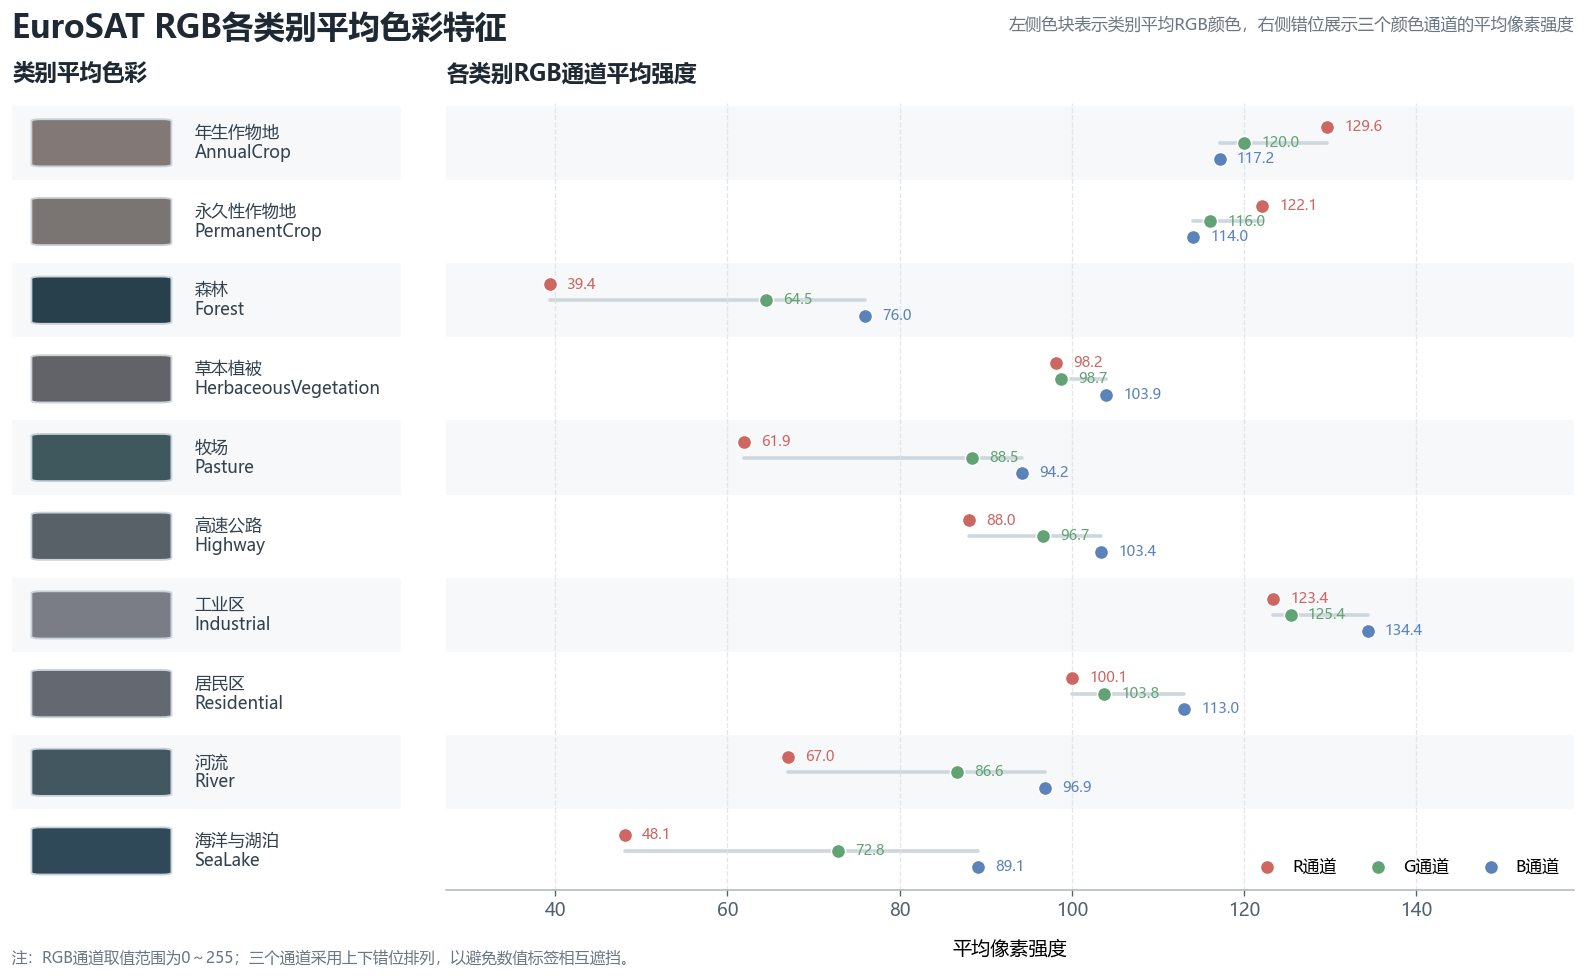

优化后的平均色彩特征图已保存至：D:\qy\junior\深度学习\课设\EuroSAT_RGB类别平均色彩特征.png


In [22]:
# ==========================================
# 4.2.3 各类别平均色彩特征图（优化版）
# 解决RGB数值标签互相遮挡的问题
# ==========================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch


# ------------------------------
# 1. 准备数据
# ------------------------------
plot_color_df = class_feature_df.copy().reset_index(drop=True)

class_count = len(plot_color_df)
y_positions = np.arange(class_count)

red_values = plot_color_df["R通道均值"].to_numpy()
green_values = plot_color_df["G通道均值"].to_numpy()
blue_values = plot_color_df["B通道均值"].to_numpy()


# ------------------------------
# 2. 统一视觉样式
# ------------------------------
title_color = "#1F2933"
text_color = "#34424E"
subtitle_color = "#6B7782"
grid_color = "#DCE2E7"
row_background = "#F6F8FA"

channel_styles = {
    "R通道": {
        "values": red_values,
        "color": "#CE6661",
        "offset": -0.20
    },
    "G通道": {
        "values": green_values,
        "color": "#62A375",
        "offset": 0.00
    },
    "B通道": {
        "values": blue_values,
        "color": "#5C83B9",
        "offset": 0.20
    }
}


# ------------------------------
# 3. 创建左右双区域画布
# ------------------------------
fig = plt.figure(figsize=(14, 8.3))

grid_spec = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[1.12, 3.25],
    wspace=0.06
)

ax_color = fig.add_subplot(grid_spec[0, 0])
ax_rgb = fig.add_subplot(grid_spec[0, 1])


# ------------------------------
# 4. 绘制交替行背景
# ------------------------------
for row_index in range(class_count):
    if row_index % 2 == 0:
        ax_color.axhspan(
            row_index - 0.46,
            row_index + 0.46,
            color=row_background,
            zorder=0
        )

        ax_rgb.axhspan(
            row_index - 0.46,
            row_index + 0.46,
            color=row_background,
            zorder=0
        )


# ------------------------------
# 5. 左侧：平均颜色卡片
# ------------------------------
ax_color.set_xlim(0, 1)
ax_color.set_ylim(class_count - 0.5, -0.5)
ax_color.axis("off")

for row_index, row in plot_color_df.iterrows():

    average_rgb = np.array([
        row["R通道均值"],
        row["G通道均值"],
        row["B通道均值"]
    ]) / 255.0

    average_rgb = np.clip(average_rgb, 0, 1)

    color_card = FancyBboxPatch(
        (0.06, row_index - 0.29),
        0.34,
        0.58,
        boxstyle="round,pad=0.01,rounding_size=0.025",
        facecolor=average_rgb,
        edgecolor="#C9D1D9",
        linewidth=1.1
    )

    ax_color.add_patch(color_card)

    ax_color.text(
        0.47,
        row_index,
        f"{row['类别中文名称']}\n"
        f"{row['类别英文名称']}",
        ha="left",
        va="center",
        fontsize=10.2,
        color=text_color,
        linespacing=1.15
    )

ax_color.set_title(
    "类别平均色彩",
    loc="left",
    fontsize=13.5,
    fontweight="bold",
    color=title_color,
    pad=14
)


# ------------------------------
# 6. 右侧：每类RGB取值范围连线
# ------------------------------
minimum_values = np.minimum.reduce([
    red_values,
    green_values,
    blue_values
])

maximum_values = np.maximum.reduce([
    red_values,
    green_values,
    blue_values
])

for row_index in range(class_count):
    ax_rgb.plot(
        [
            minimum_values[row_index],
            maximum_values[row_index]
        ],
        [row_index, row_index],
        color="#CFD7DE",
        linewidth=2.2,
        solid_capstyle="round",
        zorder=1
    )


# ------------------------------
# 7. RGB通道采用垂直错位排列
# 防止数值标签重叠
# ------------------------------
for channel_name, style in channel_styles.items():

    values = style["values"]
    point_color = style["color"]
    y_offset = style["offset"]

    shifted_y = y_positions + y_offset

    ax_rgb.scatter(
        values,
        shifted_y,
        s=72,
        color=point_color,
        edgecolor="white",
        linewidth=0.9,
        label=channel_name,
        zorder=4
    )

    for value, point_y in zip(values, shifted_y):
        ax_rgb.text(
            value + 2.0,
            point_y,
            f"{value:.1f}",
            ha="left",
            va="center",
            fontsize=8.8,
            color=point_color,
            fontweight="medium",
            zorder=5
        )


# ------------------------------
# 8. 设置右侧坐标轴
# ------------------------------
all_channel_values = np.concatenate([
    red_values,
    green_values,
    blue_values
])

x_min = max(0, all_channel_values.min() - 12)
x_max = min(255, all_channel_values.max() + 24)

ax_rgb.set_xlim(x_min, x_max)
ax_rgb.set_ylim(class_count - 0.5, -0.5)

ax_rgb.set_yticks(y_positions)
ax_rgb.set_yticklabels([])

ax_rgb.set_xlabel(
    "平均像素强度",
    fontsize=11.5,
    labelpad=11
)

ax_rgb.set_title(
    "各类别RGB通道平均强度",
    loc="left",
    fontsize=13.5,
    fontweight="bold",
    color=title_color,
    pad=14
)

ax_rgb.xaxis.grid(
    True,
    linestyle="--",
    linewidth=0.8,
    color=grid_color,
    alpha=0.8,
    zorder=0
)

ax_rgb.yaxis.grid(False)

ax_rgb.spines["top"].set_visible(False)
ax_rgb.spines["right"].set_visible(False)
ax_rgb.spines["left"].set_visible(False)

ax_rgb.spines["bottom"].set_color("#AAB4BC")
ax_rgb.spines["bottom"].set_linewidth(0.9)

ax_rgb.tick_params(
    axis="y",
    length=0
)

ax_rgb.tick_params(
    axis="x",
    colors="#53616D"
)


# ------------------------------
# 9. 图例
# ------------------------------
ax_rgb.legend(
    loc="lower right",
    ncol=3,
    frameon=False,
    fontsize=10,
    handletextpad=0.5,
    columnspacing=1.5
)


# ------------------------------
# 10. 主标题与副标题
# ------------------------------
fig.suptitle(
    "EuroSAT RGB各类别平均色彩特征",
    x=0.04,
    y=0.982,
    ha="left",
    va="top",
    fontsize=19,
    fontweight="bold",
    color=title_color
)

fig.text(
    0.97,
    0.977,
    "左侧色块表示类别平均RGB颜色，右侧错位展示三个颜色通道的平均像素强度",
    ha="right",
    va="top",
    fontsize=10,
    color=subtitle_color
)


# ------------------------------
# 11. 底部注释
# ------------------------------
fig.text(
    0.04,
    0.024,
    "注：RGB通道取值范围为0～255；三个通道采用上下错位排列，以避免数值标签相互遮挡。",
    ha="left",
    va="bottom",
    fontsize=9.3,
    color=subtitle_color
)


# ------------------------------
# 12. 调整布局
# ------------------------------
plt.subplots_adjust(
    left=0.04,
    right=0.97,
    top=0.89,
    bottom=0.10
)


# ------------------------------
# 13. 保存高清图像
# ------------------------------
rgb_figure_path = Path(
    "EuroSAT_RGB类别平均色彩特征.png"
)

plt.savefig(
    rgb_figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.08
)

plt.show()

print(
    f"优化后的平均色彩特征图已保存至："
    f"{rgb_figure_path.resolve()}"
)

##### 各类别平均色彩特征分析

平均色彩特征图由两部分组成：

- 左侧色块展示各类别根据平均 RGB 通道值合成的整体颜色；
- 右侧点图展示每个类别 R、G、B 三个通道的平均像素强度。

从 RGB 通道排列关系可以观察到不同类别的总体色彩倾向。

###### 农业用地类别

AnnualCrop 的 RGB 均值分别为：

$$
R=129.60,\quad
G=120.02,\quad
B=117.17
$$

R 通道高于 G、B 通道，因此综合色块偏暖灰和浅褐色。

PermanentCrop 的 RGB 均值为：

$$
R=122.11,\quad
G=116.02,\quad
B=114.04
$$

三个通道之间的差异同样较小，综合色彩与 AnnualCrop 接近，但整体强度略低。

两类农业用地在平均色彩上具有相似性，说明仅使用全局 RGB 均值难以完全区分年生作物地和永久性作物地。

###### 森林与水体类别

Forest 的通道关系为：

$$
B>G>R
$$

其 R 通道均值仅为 39.36，而 B 通道均值达到 75.97，因此整体表现为较暗的蓝绿色。

River 和 SeaLake 同样表现为 B 通道和 G 通道高于 R 通道，体现出明显的蓝绿色或深青色倾向。

其中，SeaLake 的平均色彩较为稳定，整体呈深蓝绿色；River 图像除水体外还包含河岸、农田和建筑，因此 RGB 均值相对更高。

###### 人工建筑类别

Industrial 三个通道均值整体较高，其中 B 通道均值最高，达到 134.35。该结果与工业区中常见的亮色屋顶、灰白建筑和人工材料有关。

Residential 的 B 通道均值为 113.02，同样高于 R、G 通道，整体呈较冷的灰蓝色。居民区中建筑、道路和阴影混合，使其综合色彩比工业区更暗。

平均 RGB 色彩能够反映不同类别的整体颜色倾向，但它不包含地物的位置、形状和空间排列信息。因此，即使两个类别平均色彩接近，也可能具有完全不同的空间结构。

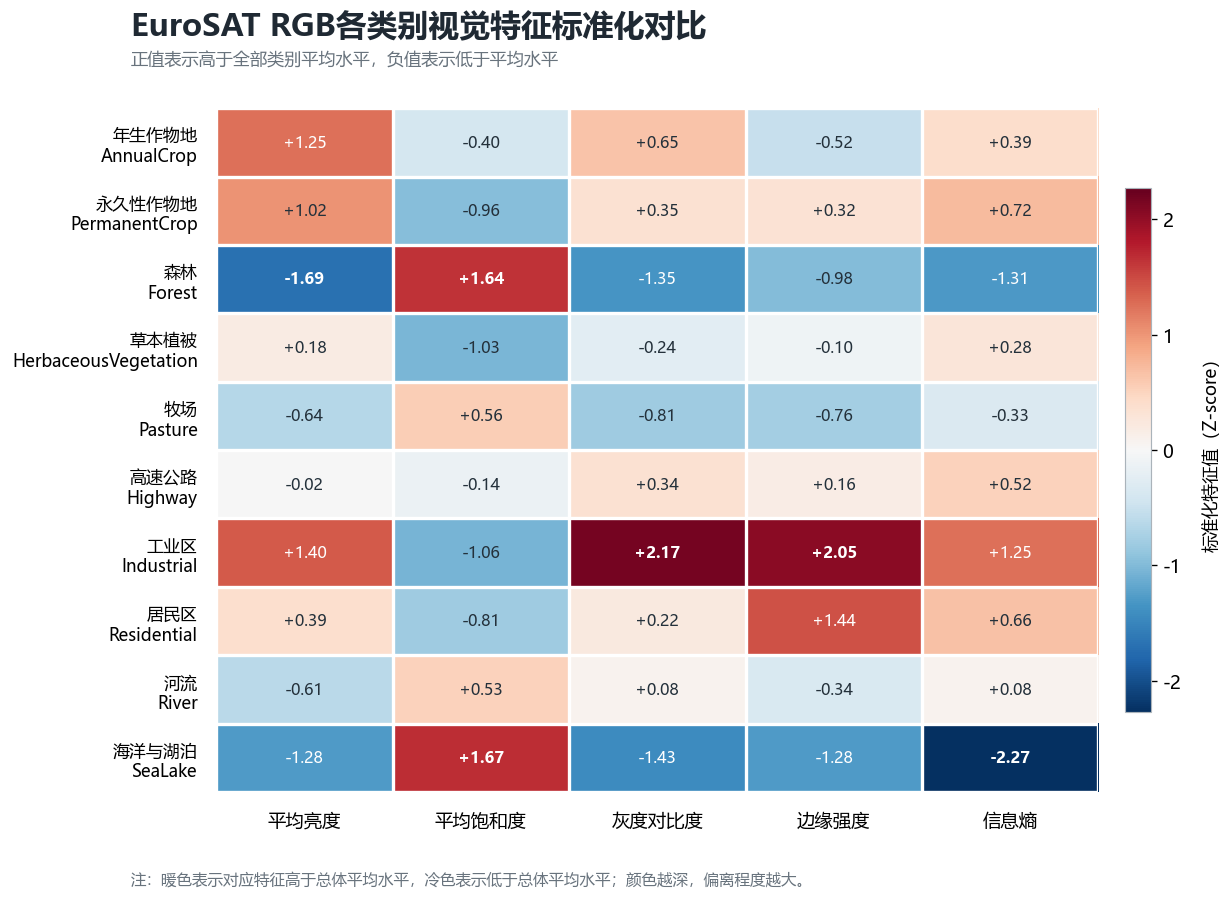

优化后的视觉特征热力图已保存至：D:\qy\junior\深度学习\课设\EuroSAT_RGB类别视觉特征热力图.png


In [23]:
# ==========================================
# 4.2.3 类别视觉特征标准化热力图（优化版）
# ==========================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ------------------------------
# 1. 准备特征数据
# ------------------------------
heatmap_features = [
    "平均亮度",
    "平均饱和度",
    "灰度对比度",
    "边缘强度",
    "信息熵"
]

heatmap_data = class_feature_df[
    heatmap_features
].to_numpy(dtype=np.float64)


# ------------------------------
# 2. Z-score标准化
# ------------------------------
feature_means = heatmap_data.mean(axis=0)
feature_stds = heatmap_data.std(axis=0)

feature_stds = np.where(
    feature_stds == 0,
    1,
    feature_stds
)

standardized_data = (
    heatmap_data - feature_means
) / feature_stds


# ------------------------------
# 3. 设置颜色范围
# ------------------------------
max_absolute_value = max(
    2.0,
    float(np.abs(standardized_data).max())
)

color_norm = TwoSlopeNorm(
    vmin=-max_absolute_value,
    vcenter=0,
    vmax=max_absolute_value
)


# ------------------------------
# 4. 创建画布
# ------------------------------
fig, ax = plt.subplots(
    figsize=(11.8, 7.7)
)

heatmap_image = ax.imshow(
    standardized_data,
    cmap="RdBu_r",
    norm=color_norm,
    aspect="auto",
    interpolation="nearest"
)


# ------------------------------
# 5. 设置标签
# ------------------------------
ax.set_xticks(
    np.arange(len(heatmap_features))
)

ax.set_xticklabels(
    heatmap_features,
    fontsize=11
)

ax.set_yticks(
    np.arange(len(class_feature_df))
)

ax.set_yticklabels(
    class_feature_df["类别标签"],
    fontsize=10.2
)


# ------------------------------
# 6. 添加单元格数值
# ------------------------------
for row_index in range(standardized_data.shape[0]):
    for column_index in range(standardized_data.shape[1]):

        value = standardized_data[
            row_index,
            column_index
        ]

        text_color = (
            "white"
            if abs(value) >= 1.15
            else "#24313B"
        )

        ax.text(
            column_index,
            row_index,
            f"{value:+.2f}",
            ha="center",
            va="center",
            fontsize=9.6,
            color=text_color,
            fontweight=(
                "bold"
                if abs(value) >= 1.5
                else "normal"
            )
        )


# ------------------------------
# 7. 添加单元格分隔线
# ------------------------------
ax.set_xticks(
    np.arange(
        -0.5,
        len(heatmap_features),
        1
    ),
    minor=True
)

ax.set_yticks(
    np.arange(
        -0.5,
        len(class_feature_df),
        1
    ),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=2.0
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

ax.tick_params(
    axis="x",
    length=0,
    pad=12
)

ax.tick_params(
    axis="y",
    length=0,
    pad=11
)

for spine in ax.spines.values():
    spine.set_visible(False)


# ------------------------------
# 8. 标题与副标题
# ------------------------------
fig.suptitle(
    "EuroSAT RGB各类别视觉特征标准化对比",
    x=0.18,
    y=0.975,
    ha="left",
    va="top",
    fontsize=18.5,
    fontweight="bold",
    color="#1F2933"
)

fig.text(
    0.18,
    0.932,
    "正值表示高于全部类别平均水平，负值表示低于平均水平",
    ha="left",
    va="top",
    fontsize=10.3,
    color="#68737D"
)


# ------------------------------
# 9. 色条
# ------------------------------
colorbar = fig.colorbar(
    heatmap_image,
    ax=ax,
    fraction=0.028,
    pad=0.028
)

colorbar.set_label(
    "标准化特征值（Z-score）",
    rotation=90,
    labelpad=13,
    fontsize=10.5
)

colorbar.outline.set_linewidth(0.7)
colorbar.outline.set_edgecolor("#AAB3BA")


# ------------------------------
# 10. 底部说明
# ------------------------------
fig.text(
    0.18,
    0.025,
    "注：暖色表示对应特征高于总体平均水平，冷色表示低于总体平均水平；颜色越深，偏离程度越大。",
    ha="left",
    va="bottom",
    fontsize=9.3,
    color="#68737D"
)


# ------------------------------
# 11. 调整布局并保存
# ------------------------------
plt.subplots_adjust(
    left=0.24,
    right=0.90,
    top=0.87,
    bottom=0.13
)

heatmap_figure_path = Path(
    "EuroSAT_RGB类别视觉特征热力图.png"
)

plt.savefig(
    heatmap_figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.08
)

plt.show()

print(
    f"优化后的视觉特征热力图已保存至："
    f"{heatmap_figure_path.resolve()}"
)

##### 各类别平均色彩特征分析

平均色彩特征图由两部分组成：

- 左侧色块展示各类别根据平均 RGB 通道值合成的整体颜色；
- 右侧点图展示每个类别 R、G、B 三个通道的平均像素强度。

从 RGB 通道排列关系可以观察到不同类别的总体色彩倾向。

###### 农业用地类别

AnnualCrop 的 RGB 均值分别为：

$$
R=129.60,\quad
G=120.02,\quad
B=117.17
$$

R 通道高于 G、B 通道，因此综合色块偏暖灰和浅褐色。

PermanentCrop 的 RGB 均值为：

$$
R=122.11,\quad
G=116.02,\quad
B=114.04
$$

三个通道之间的差异同样较小，综合色彩与 AnnualCrop 接近，但整体强度略低。

两类农业用地在平均色彩上具有相似性，说明仅使用全局 RGB 均值难以完全区分年生作物地和永久性作物地。

###### 森林与水体类别

Forest 的通道关系为：

$$
B>G>R
$$

其 R 通道均值仅为 39.36，而 B 通道均值达到 75.97，因此整体表现为较暗的蓝绿色。

River 和 SeaLake 同样表现为 B 通道和 G 通道高于 R 通道，体现出明显的蓝绿色或深青色倾向。

其中，SeaLake 的平均色彩较为稳定，整体呈深蓝绿色；River 图像除水体外还包含河岸、农田和建筑，因此 RGB 均值相对更高。

###### 人工建筑类别

Industrial 三个通道均值整体较高，其中 B 通道均值最高，达到 134.35。该结果与工业区中常见的亮色屋顶、灰白建筑和人工材料有关。

Residential 的 B 通道均值为 113.02，同样高于 R、G 通道，整体呈较冷的灰蓝色。居民区中建筑、道路和阴影混合，使其综合色彩比工业区更暗。

平均 RGB 色彩能够反映不同类别的整体颜色倾向，但它不包含地物的位置、形状和空间排列信息。因此，即使两个类别平均色彩接近，也可能具有完全不同的空间结构。

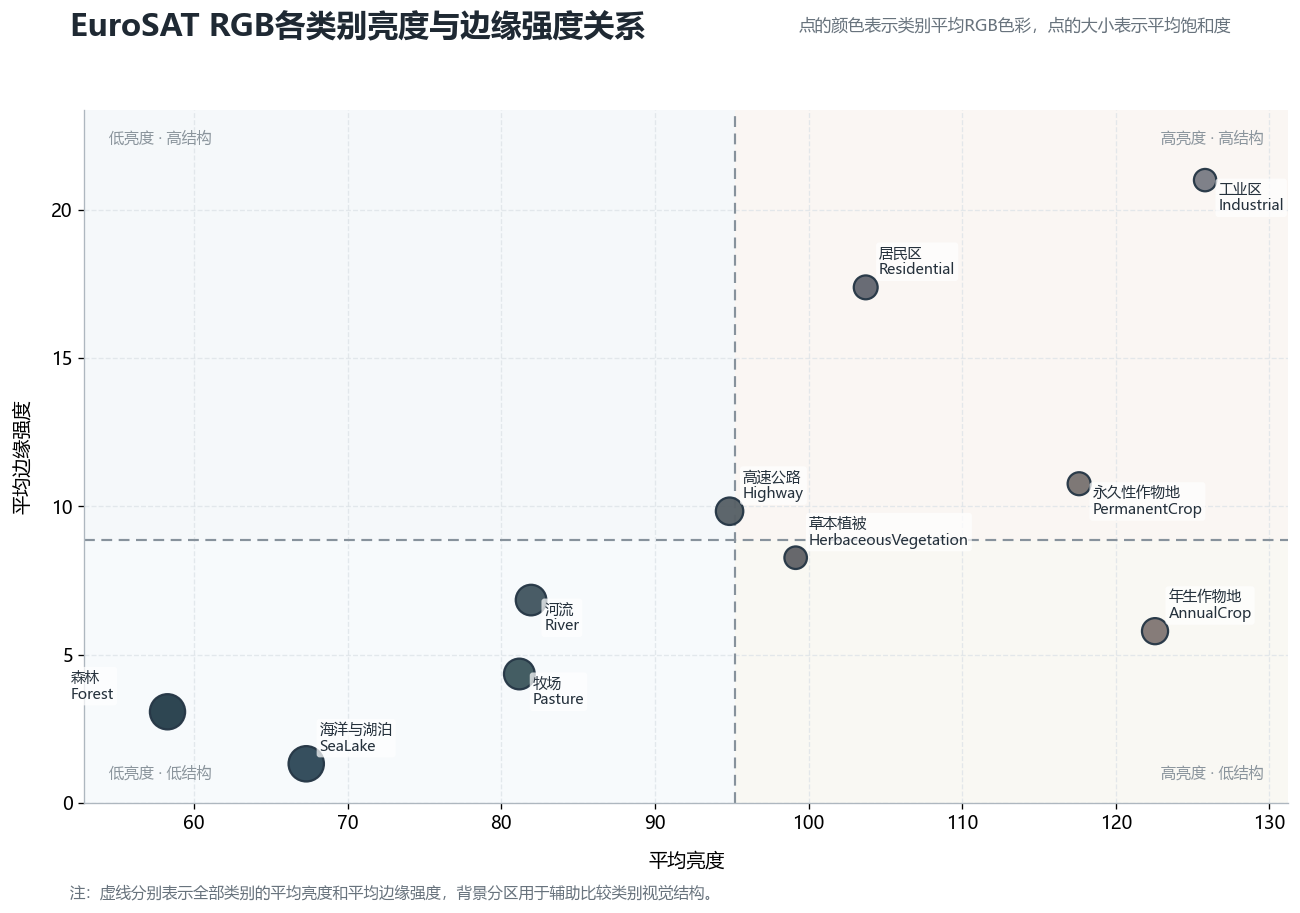

优化后的亮度与边缘强度关系图已保存至：D:\qy\junior\深度学习\课设\EuroSAT_RGB类别亮度与边缘强度关系图.png


In [24]:
# ==========================================
# 4.2.3 亮度与边缘强度关系图（优化版）
# ==========================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# ------------------------------
# 1. 准备数据
# ------------------------------
scatter_df = class_feature_df.copy()

brightness_values = (
    scatter_df["平均亮度"].to_numpy()
)

edge_values = (
    scatter_df["边缘强度"].to_numpy()
)

saturation_values = (
    scatter_df["平均饱和度"].to_numpy()
)


# ------------------------------
# 2. 类别平均RGB颜色
# ------------------------------
point_colors = []

for _, row in scatter_df.iterrows():

    rgb_color = np.array([
        row["R通道均值"],
        row["G通道均值"],
        row["B通道均值"]
    ]) / 255.0

    point_colors.append(
        np.clip(rgb_color, 0, 1)
    )


# ------------------------------
# 3. 点大小标准化
# ------------------------------
saturation_min = saturation_values.min()
saturation_max = saturation_values.max()

point_sizes = (
    180
    + (
        saturation_values - saturation_min
    )
    / (
        saturation_max - saturation_min + 1e-8
    )
    * 270
)


# ------------------------------
# 4. 创建画布
# ------------------------------
fig, ax = plt.subplots(
    figsize=(11.8, 7.8)
)

brightness_average = brightness_values.mean()
edge_average = edge_values.mean()

x_margin = (
    brightness_values.max()
    - brightness_values.min()
) * 0.08

y_margin = (
    edge_values.max()
    - edge_values.min()
) * 0.12

x_min = brightness_values.min() - x_margin
x_max = brightness_values.max() + x_margin

y_min = max(
    0,
    edge_values.min() - y_margin
)

y_max = edge_values.max() + y_margin


# ------------------------------
# 5. 添加四象限浅色背景
# ------------------------------
quadrants = [
    (
        x_min,
        y_min,
        brightness_average - x_min,
        edge_average - y_min,
        "#F7FAFC"
    ),
    (
        brightness_average,
        y_min,
        x_max - brightness_average,
        edge_average - y_min,
        "#F9F8F3"
    ),
    (
        x_min,
        edge_average,
        brightness_average - x_min,
        y_max - edge_average,
        "#F5F8FA"
    ),
    (
        brightness_average,
        edge_average,
        x_max - brightness_average,
        y_max - edge_average,
        "#FAF6F3"
    )
]

for x, y, width, height, background_color in quadrants:
    ax.add_patch(
        Rectangle(
            (x, y),
            width,
            height,
            facecolor=background_color,
            edgecolor="none",
            zorder=0
        )
    )


# ------------------------------
# 6. 绘制数据点
# ------------------------------
ax.scatter(
    brightness_values,
    edge_values,
    s=point_sizes,
    c=point_colors,
    edgecolors="#263746",
    linewidths=1.35,
    alpha=0.97,
    zorder=4
)


# ------------------------------
# 7. 类别标签位置
# ------------------------------
label_offsets = {
    "AnnualCrop": (8, 8),
    "PermanentCrop": (8, -18),
    "Forest": (-58, 8),
    "HerbaceousVegetation": (8, 8),
    "Pasture": (8, -18),
    "Highway": (8, 8),
    "Industrial": (8, -18),
    "Residential": (8, 8),
    "River": (8, -18),
    "SeaLake": (8, 8)
}

for _, row in scatter_df.iterrows():

    class_name = row["类别英文名称"]

    offset_x, offset_y = label_offsets.get(
        class_name,
        (8, 8)
    )

    ax.annotate(
        f"{row['类别中文名称']}\n"
        f"{class_name}",
        xy=(
            row["平均亮度"],
            row["边缘强度"]
        ),
        xytext=(
            offset_x,
            offset_y
        ),
        textcoords="offset points",
        fontsize=8.8,
        color="#25313C",
        linespacing=1.05,
        bbox={
            "boxstyle": "round,pad=0.20",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.72
        },
        zorder=5
    )


# ------------------------------
# 8. 平均值参考线
# ------------------------------
ax.axvline(
    brightness_average,
    color="#87929C",
    linestyle=(0, (5, 3)),
    linewidth=1.3,
    zorder=2
)

ax.axhline(
    edge_average,
    color="#87929C",
    linestyle=(0, (5, 3)),
    linewidth=1.3,
    zorder=2
)


# ------------------------------
# 9. 象限文字
# ------------------------------
quadrant_text_style = {
    "fontsize": 9,
    "color": "#8A949C",
    "fontweight": "medium"
}

ax.text(
    0.02,
    0.97,
    "低亮度 · 高结构",
    transform=ax.transAxes,
    ha="left",
    va="top",
    **quadrant_text_style
)

ax.text(
    0.98,
    0.97,
    "高亮度 · 高结构",
    transform=ax.transAxes,
    ha="right",
    va="top",
    **quadrant_text_style
)

ax.text(
    0.02,
    0.03,
    "低亮度 · 低结构",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    **quadrant_text_style
)

ax.text(
    0.98,
    0.03,
    "高亮度 · 低结构",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    **quadrant_text_style
)


# ------------------------------
# 10. 坐标轴
# ------------------------------
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xlabel(
    "平均亮度",
    fontsize=11.5,
    labelpad=11
)

ax.set_ylabel(
    "平均边缘强度",
    fontsize=11.5,
    labelpad=11
)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.8,
    color="#DCE2E7",
    alpha=0.75,
    zorder=1
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#AEB7BF")
ax.spines["bottom"].set_color("#AEB7BF")


# ------------------------------
# 11. 标题和副标题
# ------------------------------
fig.suptitle(
    "EuroSAT RGB各类别亮度与边缘强度关系",
    x=0.09,
    y=0.975,
    ha="left",
    va="top",
    fontsize=18.5,
    fontweight="bold",
    color="#1F2933"
)

fig.text(
    0.91,
    0.969,
    "点的颜色表示类别平均RGB色彩，点的大小表示平均饱和度",
    ha="right",
    va="top",
    fontsize=10,
    color="#68737D"
)


# ------------------------------
# 12. 底部说明
# ------------------------------
fig.text(
    0.09,
    0.025,
    "注：虚线分别表示全部类别的平均亮度和平均边缘强度，背景分区用于辅助比较类别视觉结构。",
    ha="left",
    va="bottom",
    fontsize=9.3,
    color="#68737D"
)


# ------------------------------
# 13. 保存图像
# ------------------------------
plt.subplots_adjust(
    left=0.10,
    right=0.95,
    top=0.87,
    bottom=0.13
)

scatter_figure_path = Path(
    "EuroSAT_RGB类别亮度与边缘强度关系图.png"
)

plt.savefig(
    scatter_figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.08
)

plt.show()

print(
    f"优化后的亮度与边缘强度关系图已保存至："
    f"{scatter_figure_path.resolve()}"
)

##### 平均亮度与边缘强度关系分析

散点图以平均亮度作为横轴，以平均边缘强度作为纵轴，并使用全部类别的平均值作为虚线分界。

10 个类别的总体平均亮度约为：

$$
\bar{x}_{\text{brightness}}
=
95.24
$$

总体平均边缘强度约为：

$$
\bar{x}_{\text{edge}}
=
8.86
$$

图中点的颜色表示类别平均 RGB 色彩，点的大小表示平均饱和度。

根据亮度和边缘强度，可以将类别分为四个区域。

| 区域 | 类别 | 主要特征 |
|:---|:---|:---|
| 高亮度、高边缘 | Industrial、Residential、PermanentCrop | 图像较亮，结构和边界较丰富 |
| 高亮度、低边缘 | AnnualCrop、HerbaceousVegetation | 图像较亮，但大面积区域相对连续 |
| 低亮度、高边缘 | Highway | 整体亮度接近平均水平以下，但道路边界明显 |
| 低亮度、低边缘 | Forest、Pasture、River、SeaLake | 图像整体较暗，部分自然区域边界较少 |

Industrial 位于图像右上方，平均亮度和边缘强度均为全部类别最高，体现出典型的高亮度、高结构人工地物特征。

Residential 同样位于高亮度、高边缘区域，但其亮度和边缘强度均低于 Industrial。

AnnualCrop 的平均亮度较高，但边缘强度仅为 5.79，说明年生作物地虽然整体较亮，但地块内部通常比较均匀。

Forest 和 SeaLake 位于低亮度、低边缘区域。SeaLake 的边缘强度最低，Forest 的平均亮度最低，两者虽然语义不同，但均表现为较连续的自然地物区域。

River 和 Pasture 在散点图中的位置较接近，说明二者在平均亮度和边缘强度这两个全局指标上具有一定相似性。

需要注意，该图使用的是类别平均值，无法展示同一类别内部样本的离散程度。两个类别平均位置接近，不代表所有样本都相似，也不能直接等同于模型误分类概率。

In [25]:
# ==========================================
# 4.2.3 输出各类别视觉特征排名
# ==========================================

ranking_features = [
    "平均亮度",
    "平均饱和度",
    "灰度对比度",
    "边缘强度",
    "信息熵"
]


ranking_records = []

for feature_name in ranking_features:

    sorted_feature_df = class_feature_df.sort_values(
        feature_name,
        ascending=False
    )

    highest_row = sorted_feature_df.iloc[0]
    lowest_row = sorted_feature_df.iloc[-1]

    ranking_records.append({
        "视觉特征": feature_name,
        "最高类别": (
            f"{highest_row['类别中文名称']}"
            f"（{highest_row['类别英文名称']}）"
        ),
        "最高值": round(
            highest_row[feature_name],
            2
        ),
        "最低类别": (
            f"{lowest_row['类别中文名称']}"
            f"（{lowest_row['类别英文名称']}）"
        ),
        "最低值": round(
            lowest_row[feature_name],
            2
        )
    })


feature_ranking_df = pd.DataFrame(
    ranking_records
)

print("EuroSAT RGB类别视觉特征极值统计：")
display(feature_ranking_df)


print("\n各视觉特征排名：")

for feature_name in ranking_features:

    ranking_df = class_feature_df.sort_values(
        feature_name,
        ascending=False
    )

    ranking_text = " > ".join([
        f"{row['类别英文名称']}"
        f"({row[feature_name]:.2f})"
        for _, row in ranking_df.iterrows()
    ])

    print(f"\n{feature_name}：")
    print(ranking_text)

EuroSAT RGB类别视觉特征极值统计：


,视觉特征,最高类别,最高值,最低类别,最低值
0,平均亮度,工业区（Industrial）,125.82,森林（Forest）,58.26
1,平均饱和度,海洋与湖泊（SeaLake）,49.21,工业区（Industrial）,17.50
2,灰度对比度,工业区（Industrial）,41.64,海洋与湖泊（SeaLake）,2.89
3,边缘强度,工业区（Industrial）,21.01,海洋与湖泊（SeaLake）,1.31
4,信息熵,工业区（Industrial）,6.85,海洋与湖泊（SeaLake）,2.56



各视觉特征排名：

平均亮度：
Industrial(125.82) > AnnualCrop(122.56) > PermanentCrop(117.62) > Residential(103.72) > HerbaceousVegetation(99.16) > Highway(94.86) > River(81.93) > Pasture(81.17) > SeaLake(67.30) > Forest(58.26)

平均饱和度：
SeaLake(49.21) > Forest(48.83) > Pasture(36.28) > River(35.95) > Highway(28.19) > AnnualCrop(25.21) > Residential(20.46) > PermanentCrop(18.70) > HerbaceousVegetation(17.83) > Industrial(17.50)

灰度对比度：
Industrial(41.64) > AnnualCrop(25.34) > PermanentCrop(22.10) > Highway(21.97) > Residential(20.71) > River(19.20) > HerbaceousVegetation(15.76) > Pasture(9.62) > Forest(3.83) > SeaLake(2.89)

边缘强度：
Industrial(21.01) > Residential(17.39) > PermanentCrop(10.76) > Highway(9.83) > HerbaceousVegetation(8.27) > River(6.84) > AnnualCrop(5.79) > Pasture(4.34) > Forest(3.07) > SeaLake(1.31)

信息熵：
Industrial(6.85) > PermanentCrop(6.19) > Residential(6.13) > Highway(5.95) > AnnualCrop(5.80) > HerbaceousVegetation(5.66) > River(5.42) > Pasture(4.92) > Forest(3.72) > SeaLake(2.56)


##### 类别视觉特征极值分析

本步骤分别统计了平均亮度、平均饱和度、灰度对比度、边缘强度和信息熵的最高类别与最低类别。

| 视觉特征 | 最高类别 | 最高值 | 最低类别 | 最低值 |
|:---|:---|---:|:---|---:|
| 平均亮度 | Industrial | 125.82 | Forest | 58.26 |
| 平均饱和度 | SeaLake | 49.21 | Industrial | 17.50 |
| 灰度对比度 | Industrial | 41.64 | SeaLake | 2.89 |
| 边缘强度 | Industrial | 21.01 | SeaLake | 1.31 |
| 信息熵 | Industrial | 6.85 | SeaLake | 2.56 |

Industrial 在 5 项视觉特征中，有 4 项达到最高值，分别为平均亮度、灰度对比度、边缘强度和信息熵。

这说明工业区图像通常具有：

- 较多亮色建筑和屋顶；
- 较明显的明暗变化；
- 较密集的人工几何边界；
- 较丰富的灰度和纹理信息。

Industrial 的平均饱和度最低，仅为 17.50，说明其颜色虽然较亮，但整体偏灰，颜色鲜明程度较低。

SeaLake 的平均饱和度最高，为 49.21，但其灰度对比度、边缘强度和信息熵均为最低。

这说明水体区域往往具有较明确的蓝绿色倾向，但图像内部颜色连续，纹理和地物边界较少。

Forest 的平均亮度最低，为 58.26，说明森林图像在 RGB 数据中整体较暗。森林并不是边缘强度最低的类别，因为树冠和植被纹理仍会形成一定局部变化。

需要注意，饱和度较高不一定等同于人眼主观感受中的“非常鲜艳”。在颜色空间中，深色但颜色成分差异明显的像素也可能具有较高饱和度。

##### 各项视觉特征排名综合分析

各类别在不同视觉特征上的排名并不完全一致，说明土地利用类别需要通过多项特征组合进行描述。

##### 平均亮度

平均亮度最高的类别依次包括 Industrial、AnnualCrop 和 PermanentCrop，说明工业建筑和部分农业地块整体较亮。

Forest 和 SeaLake 的平均亮度最低，体现出森林和深色水体区域的低亮度特征。

##### 平均饱和度

SeaLake 和 Forest 的平均饱和度最高，Pasture 和 River 次之。这些类别以水体或植被为主要内容，蓝绿色通道差异相对明显。

Industrial、HerbaceousVegetation 和 PermanentCrop 的平均饱和度较低，综合色彩更加接近灰色或浅褐色。

##### 灰度对比度

Industrial 的灰度对比度显著高于其他类别，AnnualCrop、PermanentCrop 和 Highway 也具有较高对比度。

SeaLake 和 Forest 的对比度最低，说明这些自然地物类别内部的灰度变化相对平缓。

##### 边缘强度

Industrial 和 Residential 的边缘强度排名前两位，说明人工建筑区域包含大量规则边缘和空间结构。

PermanentCrop 和 Highway 的边缘强度也较高，分别对应细碎地块边界和线性道路结构。

SeaLake、Forest 和 Pasture 的边缘强度较低，符合连续自然区域边界较少的特点。

##### 信息熵

Industrial 的信息熵最高，PermanentCrop、Residential 和 Highway 也具有较高的信息复杂度。

SeaLake 的信息熵最低，Forest 次低，说明大面积均匀水体和连续森林区域的灰度分布相对集中。

综合色彩和纹理排名可以发现：

- Industrial 属于高亮度、高对比、高边缘和高信息复杂度类别；
- SeaLake 属于高饱和度、低对比、低边缘和低信息复杂度类别；
- Forest 属于低亮度、高饱和度、低结构复杂度类别；
- Residential 属于中高亮度、高边缘和高信息复杂度类别；
- AnnualCrop 属于高亮度、中高对比但边缘强度相对较低的类别；
- River 与 Pasture 在多项全局视觉指标上较为接近。

不同类别之间存在特征重叠，因此后续分类模型不能只依赖单个全局指标，而需要综合提取颜色、纹理、形状和空间布局特征。

In [26]:
# ==========================================
# 4.2.3 自动生成类别视觉特征分析总结
# ==========================================

def get_feature_extreme(
    dataframe,
    feature_name,
    highest=True
):
    sorted_df = dataframe.sort_values(
        feature_name,
        ascending=not highest
    )

    return sorted_df.iloc[0]


brightest = get_feature_extreme(
    class_feature_df,
    "平均亮度",
    highest=True
)

darkest = get_feature_extreme(
    class_feature_df,
    "平均亮度",
    highest=False
)

most_saturated = get_feature_extreme(
    class_feature_df,
    "平均饱和度",
    highest=True
)

least_saturated = get_feature_extreme(
    class_feature_df,
    "平均饱和度",
    highest=False
)

highest_contrast = get_feature_extreme(
    class_feature_df,
    "灰度对比度",
    highest=True
)

lowest_contrast = get_feature_extreme(
    class_feature_df,
    "灰度对比度",
    highest=False
)

highest_edge = get_feature_extreme(
    class_feature_df,
    "边缘强度",
    highest=True
)

lowest_edge = get_feature_extreme(
    class_feature_df,
    "边缘强度",
    highest=False
)

highest_entropy = get_feature_extreme(
    class_feature_df,
    "信息熵",
    highest=True
)

lowest_entropy = get_feature_extreme(
    class_feature_df,
    "信息熵",
    highest=False
)


print("=" * 72)
print("EuroSAT RGB类别视觉特征分析总结")
print("=" * 72)

print(
    f"本实验对全部{len(image_feature_df):,}张遥感图像进行了"
    "RGB颜色、亮度、饱和度、对比度、边缘强度和信息熵统计。"
)

print(
    f"平均亮度最高的类别为"
    f"{brightest['类别中文名称']}"
    f"（{brightest['类别英文名称']}），"
    f"亮度均值为{brightest['平均亮度']:.2f}；"
    f"最低的类别为"
    f"{darkest['类别中文名称']}"
    f"（{darkest['类别英文名称']}），"
    f"亮度均值为{darkest['平均亮度']:.2f}。"
)

print(
    f"平均饱和度最高的类别为"
    f"{most_saturated['类别中文名称']}"
    f"（{most_saturated['类别英文名称']}），"
    f"最低的类别为"
    f"{least_saturated['类别中文名称']}"
    f"（{least_saturated['类别英文名称']}）。"
)

print(
    f"灰度对比度最高的类别为"
    f"{highest_contrast['类别中文名称']}"
    f"（{highest_contrast['类别英文名称']}），"
    f"最低的类别为"
    f"{lowest_contrast['类别中文名称']}"
    f"（{lowest_contrast['类别英文名称']}）。"
)

print(
    f"边缘强度最高的类别为"
    f"{highest_edge['类别中文名称']}"
    f"（{highest_edge['类别英文名称']}），"
    f"表明其图像中通常包含更丰富的地物边界或人造结构；"
    f"边缘强度最低的类别为"
    f"{lowest_edge['类别中文名称']}"
    f"（{lowest_edge['类别英文名称']}）。"
)

print(
    f"信息熵最高的类别为"
    f"{highest_entropy['类别中文名称']}"
    f"（{highest_entropy['类别英文名称']}），"
    f"说明其灰度和纹理信息相对更加丰富；"
    f"信息熵最低的类别为"
    f"{lowest_entropy['类别中文名称']}"
    f"（{lowest_entropy['类别英文名称']}）。"
)

print(
    "不同类别在颜色、明暗、纹理复杂度和边缘结构方面存在差异，"
    "说明卷积神经网络可以通过多层卷积提取具有分类意义的视觉特征。"
)

print(
    "后续数据预处理应保持遥感图像的主要颜色和空间结构，"
    "并采用适度的翻转、旋转等数据增强方式，"
    "避免过强颜色变换或过度裁剪破坏类别特征。"
)

EuroSAT RGB类别视觉特征分析总结
本实验对全部27,000张遥感图像进行了RGB颜色、亮度、饱和度、对比度、边缘强度和信息熵统计。
平均亮度最高的类别为工业区（Industrial），亮度均值为125.82；最低的类别为森林（Forest），亮度均值为58.26。
平均饱和度最高的类别为海洋与湖泊（SeaLake），最低的类别为工业区（Industrial）。
灰度对比度最高的类别为工业区（Industrial），最低的类别为海洋与湖泊（SeaLake）。
边缘强度最高的类别为工业区（Industrial），表明其图像中通常包含更丰富的地物边界或人造结构；边缘强度最低的类别为海洋与湖泊（SeaLake）。
信息熵最高的类别为工业区（Industrial），说明其灰度和纹理信息相对更加丰富；信息熵最低的类别为海洋与湖泊（SeaLake）。
不同类别在颜色、明暗、纹理复杂度和边缘结构方面存在差异，说明卷积神经网络可以通过多层卷积提取具有分类意义的视觉特征。
后续数据预处理应保持遥感图像的主要颜色和空间结构，并采用适度的翻转、旋转等数据增强方式，避免过强颜色变换或过度裁剪破坏类别特征。


##### 类别视觉特征分析综合结论

本步骤对 EuroSAT RGB 数据集中的全部 27,000 张图像进行了视觉特征统计，分析内容包括 RGB 通道均值、平均亮度、平均饱和度、灰度对比度、边缘强度和信息熵。

主要结论如下：

1. 不同土地利用类别在颜色、亮度、对比度、边缘结构和信息复杂度方面存在明显差异；
2. Industrial 的平均亮度、灰度对比度、边缘强度和信息熵均为最高，表现出典型的复杂人工建筑结构；
3. SeaLake 的平均饱和度最高，但对比度、边缘强度和信息熵最低，表现出大面积连续水体特征；
4. Forest 的平均亮度最低，同时具有较高饱和度，整体呈暗色蓝绿色；
5. Residential 的边缘强度仅次于 Industrial，说明居民区包含密集建筑和道路边界；
6. AnnualCrop 和 PermanentCrop 在平均颜色及亮度方面较为接近，但 PermanentCrop 的边缘强度和信息熵更高；
7. River 与 Pasture 在亮度、饱和度和部分结构指标方面较为接近；
8. 不同类别的全局特征存在重叠，单一视觉指标无法完成可靠分类。

本步骤得到的统计结果说明，EuroSAT RGB 图像包含具有分类意义的颜色和纹理信息。卷积神经网络可以通过多层卷积逐步提取比人工全局指标更加细致的局部边缘、纹理模式和空间结构。

根据本节结果，后续图像预处理应注意保留主要颜色和地物空间结构。训练集可以采用适度的翻转、旋转和轻微颜色扰动增加样本多样性，但不宜使用过强的颜色变换或大幅裁剪，以免破坏类别原有的色彩和空间特征。

同时需要说明，本步骤计算的是人工设计的全局统计特征，只能用于数据探索和候选易混淆类别分析，不能直接代表模型最终学习到的深层特征，也不能直接预测真实的分类错误情况。

后续仍需结合模型测试集混淆矩阵、各类别 Precision、Recall、F1-score 和错误分类样本，对类别之间的真实混淆关系进行验证。

#### 4.2.4 易混淆类别初步分析

为初步识别EuroSAT RGB数据集中可能出现分类混淆的类别，本实验基于各类别的平均亮度、平均饱和度、灰度对比度、边缘强度和信息熵进行视觉特征相似度分析。首先对不同指标进行Z-score标准化，消除量纲差异；随后计算任意两个类别之间的欧氏距离，并将其转换为相对视觉相似度指数。视觉特征距离越小、相似度指数越高，说明两个类别的全局颜色、明暗和纹理统计特征越接近，模型可能需要学习更细致的局部空间结构才能将其区分。

需要说明的是，本阶段得到的相似度仅反映类别在人工统计视觉特征上的接近程度，并不等同于模型的实际误分类概率。后续模型训练完成后，还需结合测试集混淆矩阵、分类报告和错误样本进一步验证。

In [1]:
# ==========================================
# 4.2.4 易混淆类别初步分析
# 创建专属输出目录并加载数据
# ==========================================

from pathlib import Path
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from PIL import Image
from matplotlib.patches import Rectangle


# ------------------------------
# 1. 创建本步骤专属输出目录
# ------------------------------
STEP_NAME = "4.2.4_易混淆类别初步分析"

CONFUSION_OUTPUT_DIR = (
    Path.cwd() / STEP_NAME
)

CONFUSION_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    f"本步骤所有输出将保存至：\n"
    f"{CONFUSION_OUTPUT_DIR.resolve()}"
)


# ------------------------------
# 2. 设置中文字体
# ------------------------------
preferred_fonts = [
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
    "Source Han Sans CN"
]

available_fonts = {
    font.name
    for font in fm.fontManager.ttflist
}

for font_name in preferred_fonts:
    if font_name in available_fonts:
        plt.rcParams["font.sans-serif"] = [font_name]
        break

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300


# ------------------------------
# 3. 数据集路径
# ------------------------------
if "DATA_DIR" not in globals():
    DATA_DIR = Path(
        r"D:\qy\junior\深度学习\课设\EuroSAT_RGB"
    )

DATA_DIR = Path(DATA_DIR).resolve()

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"未找到EuroSAT RGB数据集：{DATA_DIR}"
    )


# ------------------------------
# 4. 类别中英文名称
# ------------------------------
if "class_name_cn" not in globals():
    class_name_cn = {
        "AnnualCrop": "年生作物地",
        "Forest": "森林",
        "HerbaceousVegetation": "草本植被",
        "Highway": "高速公路",
        "Industrial": "工业区",
        "Pasture": "牧场",
        "PermanentCrop": "永久性作物地",
        "Residential": "居民区",
        "River": "河流",
        "SeaLake": "海洋与湖泊"
    }


# ------------------------------
# 5. 类别排列顺序
# ------------------------------
visual_class_order = [
    "AnnualCrop",
    "PermanentCrop",
    "Forest",
    "HerbaceousVegetation",
    "Pasture",
    "Highway",
    "Industrial",
    "Residential",
    "River",
    "SeaLake"
]


# ------------------------------
# 6. 读取类别视觉特征统计数据
# ------------------------------
if "class_feature_df" in globals():

    confusion_class_feature_df = (
        class_feature_df.copy()
    )

    print("已直接使用Notebook中的class_feature_df变量。")

else:
    feature_file_candidates = sorted(
        Path.cwd().glob(
            "EuroSAT_RGB类别视觉特征统计*.csv"
        ),
        key=lambda path: path.stat().st_mtime,
        reverse=True
    )

    if not feature_file_candidates:
        raise FileNotFoundError(
            "当前目录未找到"
            "EuroSAT_RGB类别视觉特征统计.csv，"
            "请先完成4.2.3类别视觉特征分析。"
        )

    selected_feature_file = (
        feature_file_candidates[0]
    )

    confusion_class_feature_df = pd.read_csv(
        selected_feature_file,
        encoding="utf-8-sig"
    )

    print(
        f"已读取视觉特征文件："
        f"{selected_feature_file.resolve()}"
    )


# ------------------------------
# 7. 检查必要字段
# ------------------------------
required_columns = [
    "类别英文名称",
    "类别中文名称",
    "平均亮度",
    "平均饱和度",
    "灰度对比度",
    "边缘强度",
    "信息熵"
]

missing_columns = [
    column
    for column in required_columns
    if column not in confusion_class_feature_df.columns
]

if missing_columns:
    raise ValueError(
        f"视觉特征表中缺少字段：{missing_columns}"
    )


# ------------------------------
# 8. 按指定顺序排列类别
# ------------------------------
class_order_mapping = {
    class_name: index
    for index, class_name
    in enumerate(visual_class_order)
}

confusion_class_feature_df["类别顺序"] = (
    confusion_class_feature_df[
        "类别英文名称"
    ].map(class_order_mapping)
)

confusion_class_feature_df = (
    confusion_class_feature_df
    .sort_values("类别顺序")
    .drop(columns="类别顺序")
    .reset_index(drop=True)
)


print(f"数据集路径：{DATA_DIR}")
print(
    f"参与分析的类别数量："
    f"{len(confusion_class_feature_df)}"
)

display(
    confusion_class_feature_df[
        required_columns
    ].round(2)
)

本步骤所有输出将保存至：
D:\qy\junior\深度学习\课设\4.2.4_易混淆类别初步分析
已读取视觉特征文件：D:\qy\junior\深度学习\课设\EuroSAT_RGB类别视觉特征统计.csv
数据集路径：D:\qy\junior\深度学习\课设\EuroSAT_RGB
参与分析的类别数量：10


,类别英文名称,类别中文名称,平均亮度,平均饱和度,灰度对比度,边缘强度,信息熵
0,AnnualCrop,年生作物地,122.56,25.21,25.34,5.79,5.80
1,PermanentCrop,永久性作物地,117.62,18.70,22.10,10.76,6.19
2,Forest,森林,58.26,48.83,3.83,3.07,3.72
3,HerbaceousVegetation,草本植被,99.16,17.83,15.76,8.27,5.66
4,Pasture,牧场,81.17,36.28,9.62,4.34,4.92
5,Highway,高速公路,94.86,28.19,21.97,9.83,5.95
6,Industrial,工业区,125.82,17.50,41.64,21.01,6.85
7,Residential,居民区,103.72,20.46,20.71,17.39,6.13
8,River,河流,81.93,35.95,19.20,6.84,5.42
9,SeaLake,海洋与湖泊,67.30,49.21,2.89,1.31,2.56


##### 易混淆类别分析数据准备

本步骤创建了“4.2.4_易混淆类别初步分析”专属输出目录，并读取上一阶段生成的类别视觉特征统计数据。

程序成功载入了 10 个土地利用类别的统计结果，每个类别均包含以下 5 项用于相似度分析的视觉特征：

| 视觉特征 | 主要含义 |
|:---|:---|
| 平均亮度 | 类别图像整体明暗水平 |
| 平均饱和度 | 图像颜色鲜明程度 |
| 灰度对比度 | 图像内部明暗变化程度 |
| 边缘强度 | 地物边界与人工结构丰富程度 |
| 信息熵 | 灰度层次和纹理信息复杂程度 |

参与分析的类别数量为 10，说明上一阶段生成的类别视觉特征统计表读取完整，没有出现类别遗漏。

本步骤使用的是每个类别全部图像视觉特征的平均值，而不是单张样本的特征。因此，后续相似度主要反映类别在全局颜色、亮度和纹理统计方面的整体接近程度。

需要注意，这种类别均值会压缩同一类别内部的样本差异。例如，同一类别中某些图像可能具有不同的季节、地物比例和空间结构，但在类别均值中会被整体平均。

因此，本节分析适合用于初步筛选候选易混淆类别，不能直接等同于卷积神经网络的真实误分类结果。

In [2]:
# ==========================================
# 4.2.4 计算类别视觉特征距离与相似度
# ==========================================

analysis_features = [
    "平均亮度",
    "平均饱和度",
    "灰度对比度",
    "边缘强度",
    "信息熵"
]


# ------------------------------
# 1. 提取特征矩阵
# ------------------------------
feature_matrix = (
    confusion_class_feature_df[
        analysis_features
    ].to_numpy(dtype=np.float64)
)


# ------------------------------
# 2. Z-score标准化
# ------------------------------
feature_means = feature_matrix.mean(axis=0)
feature_stds = feature_matrix.std(
    axis=0,
    ddof=0
)

feature_stds = np.where(
    feature_stds == 0,
    1,
    feature_stds
)

standardized_matrix = (
    feature_matrix - feature_means
) / feature_stds


# ------------------------------
# 3. 保存标准化特征
# ------------------------------
standardized_feature_df = pd.DataFrame(
    standardized_matrix,
    columns=analysis_features
)

standardized_feature_df.insert(
    0,
    "类别中文名称",
    confusion_class_feature_df[
        "类别中文名称"
    ]
)

standardized_feature_df.insert(
    0,
    "类别英文名称",
    confusion_class_feature_df[
        "类别英文名称"
    ]
)

standardized_feature_path = (
    CONFUSION_OUTPUT_DIR
    / "01_类别标准化视觉特征.csv"
)

standardized_feature_df.to_csv(
    standardized_feature_path,
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------
# 4. 计算两两欧氏距离
# ------------------------------
class_names = (
    confusion_class_feature_df[
        "类别英文名称"
    ].tolist()
)

class_count = len(class_names)

distance_matrix = np.zeros(
    (class_count, class_count),
    dtype=np.float64
)

for row_index in range(class_count):
    for column_index in range(class_count):

        feature_difference = (
            standardized_matrix[row_index]
            - standardized_matrix[column_index]
        )

        distance_matrix[
            row_index,
            column_index
        ] = np.sqrt(
            np.sum(feature_difference ** 2)
        )


distance_matrix_df = pd.DataFrame(
    distance_matrix,
    index=class_names,
    columns=class_names
)

distance_matrix_path = (
    CONFUSION_OUTPUT_DIR
    / "02_类别视觉特征距离矩阵.csv"
)

distance_matrix_df.to_csv(
    distance_matrix_path,
    encoding="utf-8-sig"
)


# ------------------------------
# 5. 获取全部非重复类别对
# ------------------------------
pair_records = []

for first_index in range(class_count):
    for second_index in range(
        first_index + 1,
        class_count
    ):

        first_class = class_names[first_index]
        second_class = class_names[second_index]

        distance_value = distance_matrix[
            first_index,
            second_index
        ]

        pair_records.append({
            "类别1英文名称": first_class,
            "类别1中文名称": (
                class_name_cn[first_class]
            ),
            "类别2英文名称": second_class,
            "类别2中文名称": (
                class_name_cn[second_class]
            ),
            "视觉特征距离": distance_value
        })


pair_similarity_df = pd.DataFrame(
    pair_records
)


# ------------------------------
# 6. 将距离转换为相对相似度指数
# 该指数只用于本数据集内部相对比较
# ------------------------------
nonzero_distances = (
    pair_similarity_df[
        "视觉特征距离"
    ].to_numpy()
)

median_distance = np.median(
    nonzero_distances
)

pair_similarity_df["相似度指数"] = (
    100
    * np.exp(
        -pair_similarity_df[
            "视觉特征距离"
        ]
        / median_distance
    )
)


# ------------------------------
# 7. 按相似度由高到低排序
# ------------------------------
pair_similarity_df = (
    pair_similarity_df
    .sort_values(
        by=[
            "视觉特征距离",
            "类别1英文名称",
            "类别2英文名称"
        ],
        ascending=[
            True,
            True,
            True
        ]
    )
    .reset_index(drop=True)
)

pair_similarity_df.insert(
    0,
    "相似度排名",
    np.arange(
        1,
        len(pair_similarity_df) + 1
    )
)

pair_similarity_df[
    "类别组合"
] = (
    pair_similarity_df[
        "类别1中文名称"
    ]
    + "—"
    + pair_similarity_df[
        "类别2中文名称"
    ]
)

pair_similarity_df[
    "视觉特征距离"
] = pair_similarity_df[
    "视觉特征距离"
].round(4)

pair_similarity_df[
    "相似度指数"
] = pair_similarity_df[
    "相似度指数"
].round(2)


# ------------------------------
# 8. 保存完整排名
# ------------------------------
pair_similarity_path = (
    CONFUSION_OUTPUT_DIR
    / "03_全部类别对视觉相似度排名.csv"
)

pair_similarity_df.to_csv(
    pair_similarity_path,
    index=False,
    encoding="utf-8-sig"
)


print("视觉特征距离与相似度计算完成。")
print(
    "说明：相似度指数越高，表示类别的"
    "全局统计特征越接近。"
)

print("\n视觉特征最接近的前10组类别：")

display(
    pair_similarity_df[
        [
            "相似度排名",
            "类别组合",
            "视觉特征距离",
            "相似度指数"
        ]
    ].head(10)
)

视觉特征距离与相似度计算完成。
说明：相似度指数越高，表示类别的全局统计特征越接近。

视觉特征最接近的前10组类别：


,相似度排名,类别组合,视觉特征距离,相似度指数
0,1,牧场—河流,1.0678,66.28
1,2,森林—海洋与湖泊,1.0877,65.77
2,3,年生作物地—永久性作物地,1.1269,64.79
3,4,草本植被—高速公路,1.1391,64.48
4,5,高速公路—河流,1.1442,64.36
5,6,永久性作物地—草本植被,1.1974,63.05
6,7,永久性作物地—居民区,1.3041,60.51
7,8,永久性作物地—高速公路,1.3466,59.53
8,9,年生作物地—高速公路,1.4998,56.12
9,10,高速公路—居民区,1.5080,55.94


##### 类别视觉特征距离与相似度分析

由于平均亮度、平均饱和度、灰度对比度、边缘强度和信息熵具有不同的数值范围，本步骤首先采用 Z-score 方法对 5 项特征进行标准化。

标准化公式为：

$$
z_{ik}
=
\frac{x_{ik}-\mu_k}{\sigma_k}
$$

其中，$x_{ik}$ 表示第 $i$ 个类别在第 $k$ 项特征上的原始值，$\mu_k$ 和 $\sigma_k$ 分别表示该项特征在 10 个类别中的总体均值和总体标准差。

本代码在计算标准差时使用：

```python
feature_matrix.std(axis=0, ddof=0)

In [3]:
# ==========================================
# 4.2.4 建立重点易混淆类别对
# ==========================================

# ------------------------------
# 1. 数据驱动：选取前6组
# ------------------------------
top_data_pairs = (
    pair_similarity_df
    .head(6)
    .copy()
)

top_data_pairs["判定依据"] = (
    "视觉特征距离较小"
)


# ------------------------------
# 2. 先验观察：四组重点类别
# ------------------------------
prior_confusing_pairs = [
    (
        "AnnualCrop",
        "PermanentCrop",
        "均为农业用地，平均色彩和地块纹理接近"
    ),
    (
        "Forest",
        "HerbaceousVegetation",
        "均以植被为主体，颜色及纹理具有相似性"
    ),
    (
        "Industrial",
        "Residential",
        "均包含建筑、道路及密集人工边缘结构"
    ),
    (
        "River",
        "SeaLake",
        "均以水体为主体，颜色特征接近"
    )
]


def get_pair_result(
    first_class: str,
    second_class: str
) -> pd.Series:
    """
    从全部类别对排名表中提取指定类别组合。
    """

    condition_1 = (
        pair_similarity_df[
            "类别1英文名称"
        ].eq(first_class)
        & pair_similarity_df[
            "类别2英文名称"
        ].eq(second_class)
    )

    condition_2 = (
        pair_similarity_df[
            "类别1英文名称"
        ].eq(second_class)
        & pair_similarity_df[
            "类别2英文名称"
        ].eq(first_class)
    )

    matched_rows = pair_similarity_df[
        condition_1 | condition_2
    ]

    if matched_rows.empty:
        raise ValueError(
            f"未找到类别组合："
            f"{first_class}—{second_class}"
        )

    return matched_rows.iloc[0]


prior_pair_records = []

for (
    first_class,
    second_class,
    reason
) in prior_confusing_pairs:

    pair_result = get_pair_result(
        first_class,
        second_class
    )

    prior_pair_records.append({
        "类别1": (
            f"{class_name_cn[first_class]}"
            f"（{first_class}）"
        ),
        "类别2": (
            f"{class_name_cn[second_class]}"
            f"（{second_class}）"
        ),
        "视觉特征距离": (
            pair_result["视觉特征距离"]
        ),
        "相似度指数": (
            pair_result["相似度指数"]
        ),
        "全部类别对中的排名": (
            pair_result["相似度排名"]
        ),
        "初步判断依据": reason
    })


prior_pair_df = pd.DataFrame(
    prior_pair_records
)

prior_pair_path = (
    CONFUSION_OUTPUT_DIR
    / "04_重点易混淆类别对.csv"
)

prior_pair_df.to_csv(
    prior_pair_path,
    index=False,
    encoding="utf-8-sig"
)


print("重点易混淆类别对：")
display(prior_pair_df)

重点易混淆类别对：


,类别1,类别2,视觉特征距离,相似度指数,全部类别对中的排名,初步判断依据
0,年生作物地（AnnualCrop）,永久性作物地（PermanentCrop）,1.1269,64.79,3,均为农业用地，平均色彩和地块纹理接近
1,森林（Forest）,草本植被（HerbaceousVegetation）,3.8923,22.33,33,均以植被为主体，颜色及纹理具有相似性
2,工业区（Industrial）,居民区（Residential）,2.3643,40.23,19,均包含建筑、道路及密集人工边缘结构
3,河流（River）,海洋与湖泊（SeaLake）,3.2321,28.80,30,均以水体为主体，颜色特征接近


##### 重点候选易混淆类别选择分析

本代码首先截取视觉相似度排名前 6 的类别组合，并将其标记为“视觉特征距离较小”。

随后，程序并未直接把排名前 4 的类别作为重点分析对象，而是结合先验观察、土地利用语义和代表性样本，人工指定了以下四组重点候选类别。

| 类别组合 | 距离 | 相似度指数 | 全部类别对排名 | 初步判断依据 |
|:---|---:|---:|---:|:---|
| AnnualCrop—PermanentCrop | 1.1269 | 64.79 | 3 | 均为农业用地，平均色彩和地块纹理接近 |
| Forest—HerbaceousVegetation | 3.8923 | 22.33 | 33 | 均以植被为主体，颜色及纹理具有相似性 |
| Industrial—Residential | 2.3643 | 40.23 | 19 | 均包含建筑、道路及密集人工边缘结构 |
| River—SeaLake | 3.2321 | 28.80 | 30 | 均以水体为主体，颜色特征接近 |

其中，AnnualCrop 与 PermanentCrop 在 45 组类别对中排名第 3，说明其统计特征和类别语义均表现出较强的相似性。

其余三组类别并未进入相似度排名前列：

- Forest 与 HerbaceousVegetation 排名第 33；
- Industrial 与 Residential 排名第 19；
- River 与 SeaLake 排名第 30。

这说明代码中所说的“重点易混淆类别”包含两种来源：

1. 根据全局统计特征距离得到的数据驱动候选类别；
2. 根据类别语义和代表性样本确定的先验候选类别。

例如，Forest 与 HerbaceousVegetation 都属于植被类别，但 Forest 的亮度更低、饱和度更高，且对比度、边缘强度和信息熵均明显低于 HerbaceousVegetation，因此二者的全局距离较大。

River 与 SeaLake 都属于水体，但 River 图像通常包含河岸、农田、建筑和植被，使其纹理复杂度明显高于大面积均匀水体。

因此，四组重点类别适合用于后续样本观察和模型结果验证，但不能在本阶段直接认定为模型真实易混淆类别。

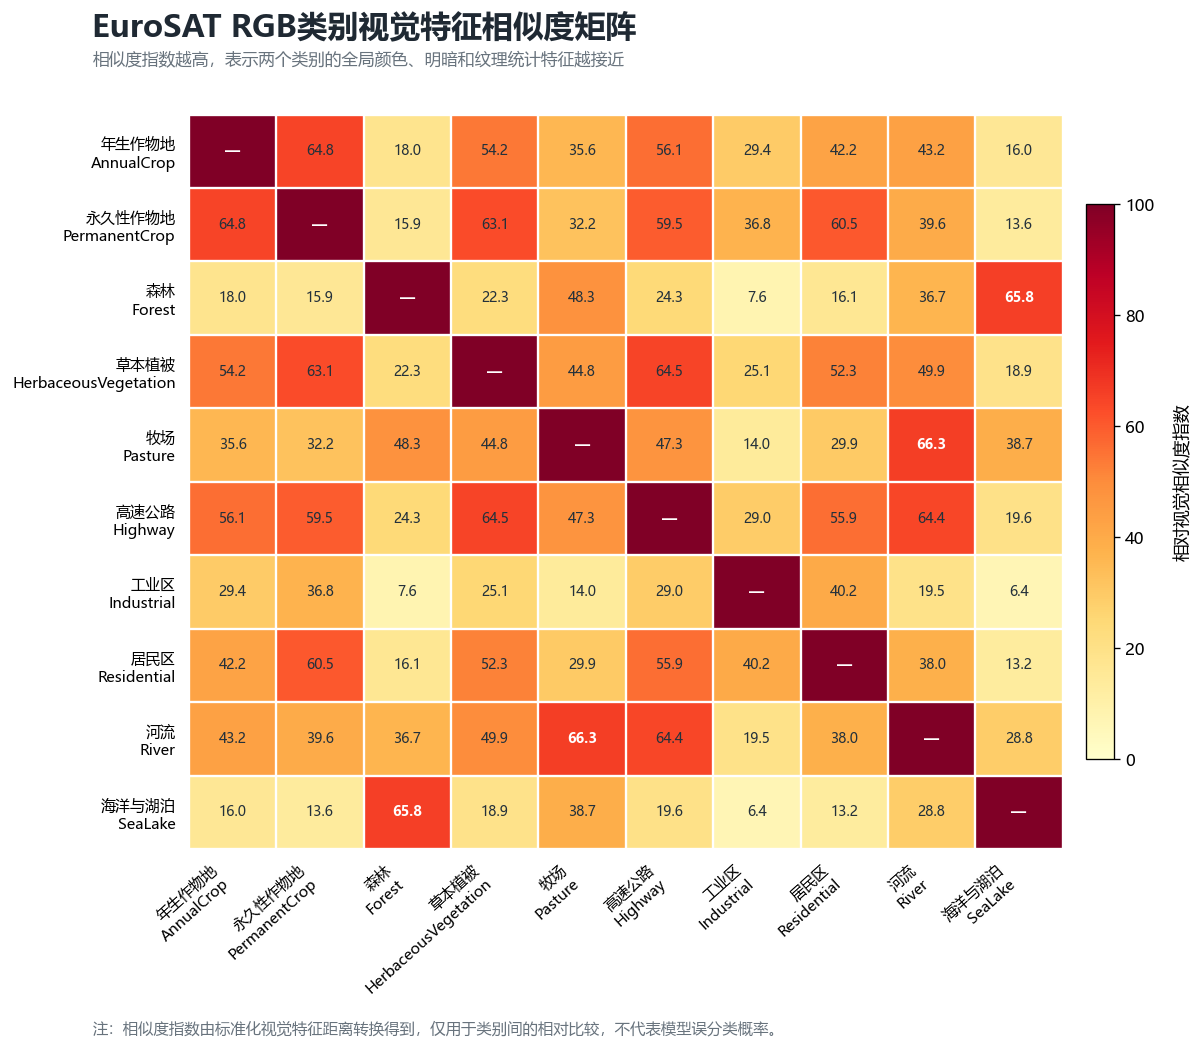

相似度热力图已保存至：
D:\qy\junior\深度学习\课设\4.2.4_易混淆类别初步分析\06_类别视觉特征相似度热力图.png


In [4]:
# ==========================================
# 4.2.4 绘制类别视觉相似度热力图
# ==========================================

# ------------------------------
# 1. 由距离矩阵生成相似度矩阵
# ------------------------------
similarity_matrix = (
    100
    * np.exp(
        -distance_matrix
        / median_distance
    )
)

similarity_matrix_df = pd.DataFrame(
    similarity_matrix,
    index=class_names,
    columns=class_names
)

similarity_matrix_path = (
    CONFUSION_OUTPUT_DIR
    / "05_类别视觉相似度矩阵.csv"
)

similarity_matrix_df.to_csv(
    similarity_matrix_path,
    encoding="utf-8-sig"
)


# ------------------------------
# 2. 中英文类别标签
# ------------------------------
heatmap_labels = [
    f"{class_name_cn[class_name]}\n"
    f"{class_name}"
    for class_name in class_names
]


# ------------------------------
# 3. 创建热力图
# ------------------------------
fig, ax = plt.subplots(
    figsize=(11.5, 9)
)

heatmap_image = ax.imshow(
    similarity_matrix,
    cmap="YlOrRd",
    aspect="auto",
    vmin=0,
    vmax=100,
    interpolation="nearest"
)


# ------------------------------
# 4. 设置坐标轴
# ------------------------------
ax.set_xticks(
    np.arange(class_count)
)

ax.set_xticklabels(
    heatmap_labels,
    rotation=42,
    ha="right",
    fontsize=9
)

ax.set_yticks(
    np.arange(class_count)
)

ax.set_yticklabels(
    heatmap_labels,
    fontsize=9
)


# ------------------------------
# 5. 添加矩阵数值
# ------------------------------
for row_index in range(class_count):
    for column_index in range(class_count):

        value = similarity_matrix[
            row_index,
            column_index
        ]

        if row_index == column_index:
            display_text = "—"
        else:
            display_text = f"{value:.1f}"

        text_color = (
            "white"
            if value >= 65
            else "#24313B"
        )

        ax.text(
            column_index,
            row_index,
            display_text,
            ha="center",
            va="center",
            fontsize=8.4,
            color=text_color,
            fontweight=(
                "bold"
                if value >= 65
                else "normal"
            )
        )


# ------------------------------
# 6. 添加单元格分隔线
# ------------------------------
ax.set_xticks(
    np.arange(-0.5, class_count, 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, class_count, 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=1.4
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

ax.tick_params(
    axis="both",
    length=0,
    pad=8
)

for spine in ax.spines.values():
    spine.set_visible(False)


# ------------------------------
# 7. 标题与副标题
# ------------------------------
fig.suptitle(
    "EuroSAT RGB类别视觉特征相似度矩阵",
    x=0.17,
    y=0.975,
    ha="left",
    va="top",
    fontsize=18.5,
    fontweight="bold",
    color="#1F2933"
)

fig.text(
    0.17,
    0.938,
    "相似度指数越高，表示两个类别的全局颜色、"
    "明暗和纹理统计特征越接近",
    ha="left",
    va="top",
    fontsize=10,
    color="#68737D"
)


# ------------------------------
# 8. 色条
# ------------------------------
colorbar = fig.colorbar(
    heatmap_image,
    ax=ax,
    fraction=0.03,
    pad=0.025
)

colorbar.set_label(
    "相对视觉相似度指数",
    fontsize=10.5,
    labelpad=12
)


# ------------------------------
# 9. 底部说明
# ------------------------------
fig.text(
    0.17,
    0.025,
    "注：相似度指数由标准化视觉特征距离转换得到，"
    "仅用于类别间的相对比较，不代表模型误分类概率。",
    ha="left",
    va="bottom",
    fontsize=9.2,
    color="#68737D"
)


plt.subplots_adjust(
    left=0.24,
    right=0.91,
    top=0.88,
    bottom=0.20
)


# ------------------------------
# 10. 保存图片
# ------------------------------
similarity_heatmap_path = (
    CONFUSION_OUTPUT_DIR
    / "06_类别视觉特征相似度热力图.png"
)

plt.savefig(
    similarity_heatmap_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.08
)

plt.show()

print(
    f"相似度热力图已保存至：\n"
    f"{similarity_heatmap_path.resolve()}"
)

##### 类别视觉特征相似度热力图分析

热力图展示了 10 个类别之间的两两相似度指数。

矩阵主对角线表示类别与自身进行比较，其理论相似度为 100。为了避免主对角线数值影响图表阅读，代码在图中将其显示为“—”。

热力图中：

- 颜色越深，表示类别的全局视觉特征越接近；
- 颜色越浅，表示类别间差异越大；
- 数值不代表分类准确率或误分类概率。

非对角线中相似度较高的组合包括：

| 类别组合 | 相似度指数 |
|:---|---:|
| Pasture—River | 66.28 |
| Forest—SeaLake | 65.77 |
| AnnualCrop—PermanentCrop | 64.79 |
| HerbaceousVegetation—Highway | 64.48 |
| Highway—River | 64.36 |
| PermanentCrop—HerbaceousVegetation | 63.05 |
| PermanentCrop—Residential | 60.51 |

代码将相似度不低于 65 的单元格使用白色粗体文字突出。因此，图中主要突出 Pasture—River 和 Forest—SeaLake 两组关系。

相似度最低的组合为 Industrial 与 SeaLake，距离为 7.1466，相似度约为 6.38。

Industrial 表现为高亮度、高对比度、高边缘强度和高信息熵，而 SeaLake 表现为低对比度、低边缘强度和低信息熵，因此两类在当前特征空间中差异最大。

热力图能够从整体上展示类别间的相对关系，但由于每个类别只使用一个均值向量，图中没有表现类别内部样本的离散程度。

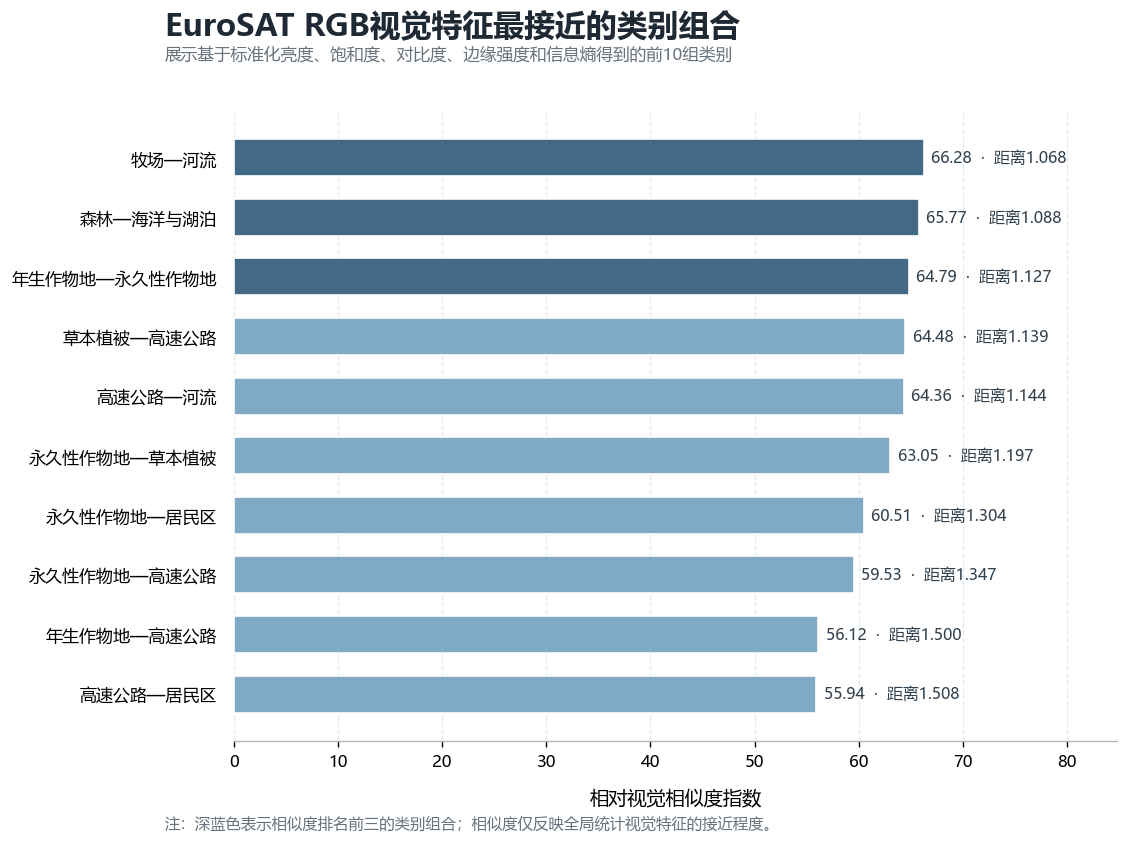

类别相似度排名图已保存至：
D:\qy\junior\深度学习\课设\4.2.4_易混淆类别初步分析\07_易混淆类别视觉相似度排名图.png


In [5]:
# ==========================================
# 4.2.4 绘制易混淆类别相似度排名图
# ==========================================

TOP_PAIR_COUNT = 10

top_pair_plot_df = (
    pair_similarity_df
    .head(TOP_PAIR_COUNT)
    .copy()
)

# 反转后使第一名显示在顶部
top_pair_plot_df = (
    top_pair_plot_df
    .iloc[::-1]
    .reset_index(drop=True)
)


# ------------------------------
# 1. 创建图表
# ------------------------------
fig, ax = plt.subplots(
    figsize=(11.5, 7.2)
)

y_positions = np.arange(
    len(top_pair_plot_df)
)

bar_values = (
    top_pair_plot_df[
        "相似度指数"
    ].to_numpy()
)

bar_labels = (
    top_pair_plot_df[
        "类别组合"
    ].tolist()
)


# ------------------------------
# 2. 绘制横向柱状图
# ------------------------------
bar_colors = [
    "#426A87"
    if rank <= 3
    else "#7FA9C4"
    for rank in top_pair_plot_df[
        "相似度排名"
    ]
]

bars = ax.barh(
    y_positions,
    bar_values,
    height=0.62,
    color=bar_colors,
    edgecolor="white",
    linewidth=1.0,
    zorder=3
)


# ------------------------------
# 3. 添加数值与排名
# ------------------------------
for bar, (_, row) in zip(
    bars,
    top_pair_plot_df.iterrows()
):
    ax.text(
        bar.get_width() + 0.7,
        bar.get_y() + bar.get_height() / 2,
        (
            f"{row['相似度指数']:.2f}"
            f"  ·  距离{row['视觉特征距离']:.3f}"
        ),
        ha="left",
        va="center",
        fontsize=9.5,
        color="#31404D"
    )


# ------------------------------
# 4. 设置标签
# ------------------------------
ax.set_yticks(y_positions)
ax.set_yticklabels(
    bar_labels,
    fontsize=10.2
)

ax.set_xlabel(
    "相对视觉相似度指数",
    fontsize=11.5,
    labelpad=11
)

ax.set_xlim(
    0,
    max(bar_values) * 1.28
)


# ------------------------------
# 5. 标题与副标题
# ------------------------------
fig.suptitle(
    "EuroSAT RGB视觉特征最接近的类别组合",
    x=0.25,
    y=0.975,
    ha="left",
    va="top",
    fontsize=18.5,
    fontweight="bold",
    color="#1F2933"
)

fig.text(
    0.25,
    0.935,
    "展示基于标准化亮度、饱和度、对比度、"
    "边缘强度和信息熵得到的前10组类别",
    ha="left",
    va="top",
    fontsize=10,
    color="#68737D"
)


# ------------------------------
# 6. 图表样式
# ------------------------------
ax.xaxis.grid(
    True,
    linestyle="--",
    linewidth=0.8,
    color="#DCE2E7",
    alpha=0.75,
    zorder=0
)

ax.yaxis.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_color(
    "#AEB7BF"
)

ax.tick_params(
    axis="y",
    length=0,
    pad=10
)


# ------------------------------
# 7. 底部说明
# ------------------------------
fig.text(
    0.25,
    0.025,
    "注：深蓝色表示相似度排名前三的类别组合；"
    "相似度仅反映全局统计视觉特征的接近程度。",
    ha="left",
    va="bottom",
    fontsize=9.2,
    color="#68737D"
)


plt.subplots_adjust(
    left=0.30,
    right=0.94,
    top=0.86,
    bottom=0.13
)


# ------------------------------
# 8. 保存图片
# ------------------------------
pair_ranking_figure_path = (
    CONFUSION_OUTPUT_DIR
    / "07_易混淆类别视觉相似度排名图.png"
)

plt.savefig(
    pair_ranking_figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.08
)

plt.show()

print(
    f"类别相似度排名图已保存至：\n"
    f"{pair_ranking_figure_path.resolve()}"
)

##### 视觉相似度排名图分析

排名图展示了视觉特征距离最小、相似度指数最高的前 10 组类别。

图中使用深蓝色突出排名前 3 的组合，其余组合使用浅蓝色表示。每根柱形末端同时标注相似度指数和视觉特征距离。

排名前三的结果为：

1. Pasture—River：相似度指数 66.28，距离 1.068；
2. Forest—SeaLake：相似度指数 65.77，距离 1.088；
3. AnnualCrop—PermanentCrop：相似度指数 64.79，距离 1.127。

前三组的相似度差距较小，最高值与第三名的差值为：

$$
66.28-64.79=1.49
$$

说明当前 5 项全局特征没有形成某一组远高于其他组合的绝对相似关系。

在前 10 组类别中，Highway 共出现 5 次，分别与 HerbaceousVegetation、River、PermanentCrop、AnnualCrop 和 Residential 组合。

这可能是因为高速公路图像除道路主体外，还包含农田、植被、居民区或河流等周边地物。类别平均特征会同时受到道路与背景区域的共同影响，使 Highway 在全局特征空间中与多个类别保持中等距离。

排名图适合用于快速筛选需要进一步观察的类别组合，但排名较高不意味着模型一定会在这些类别之间产生大量错误预测。

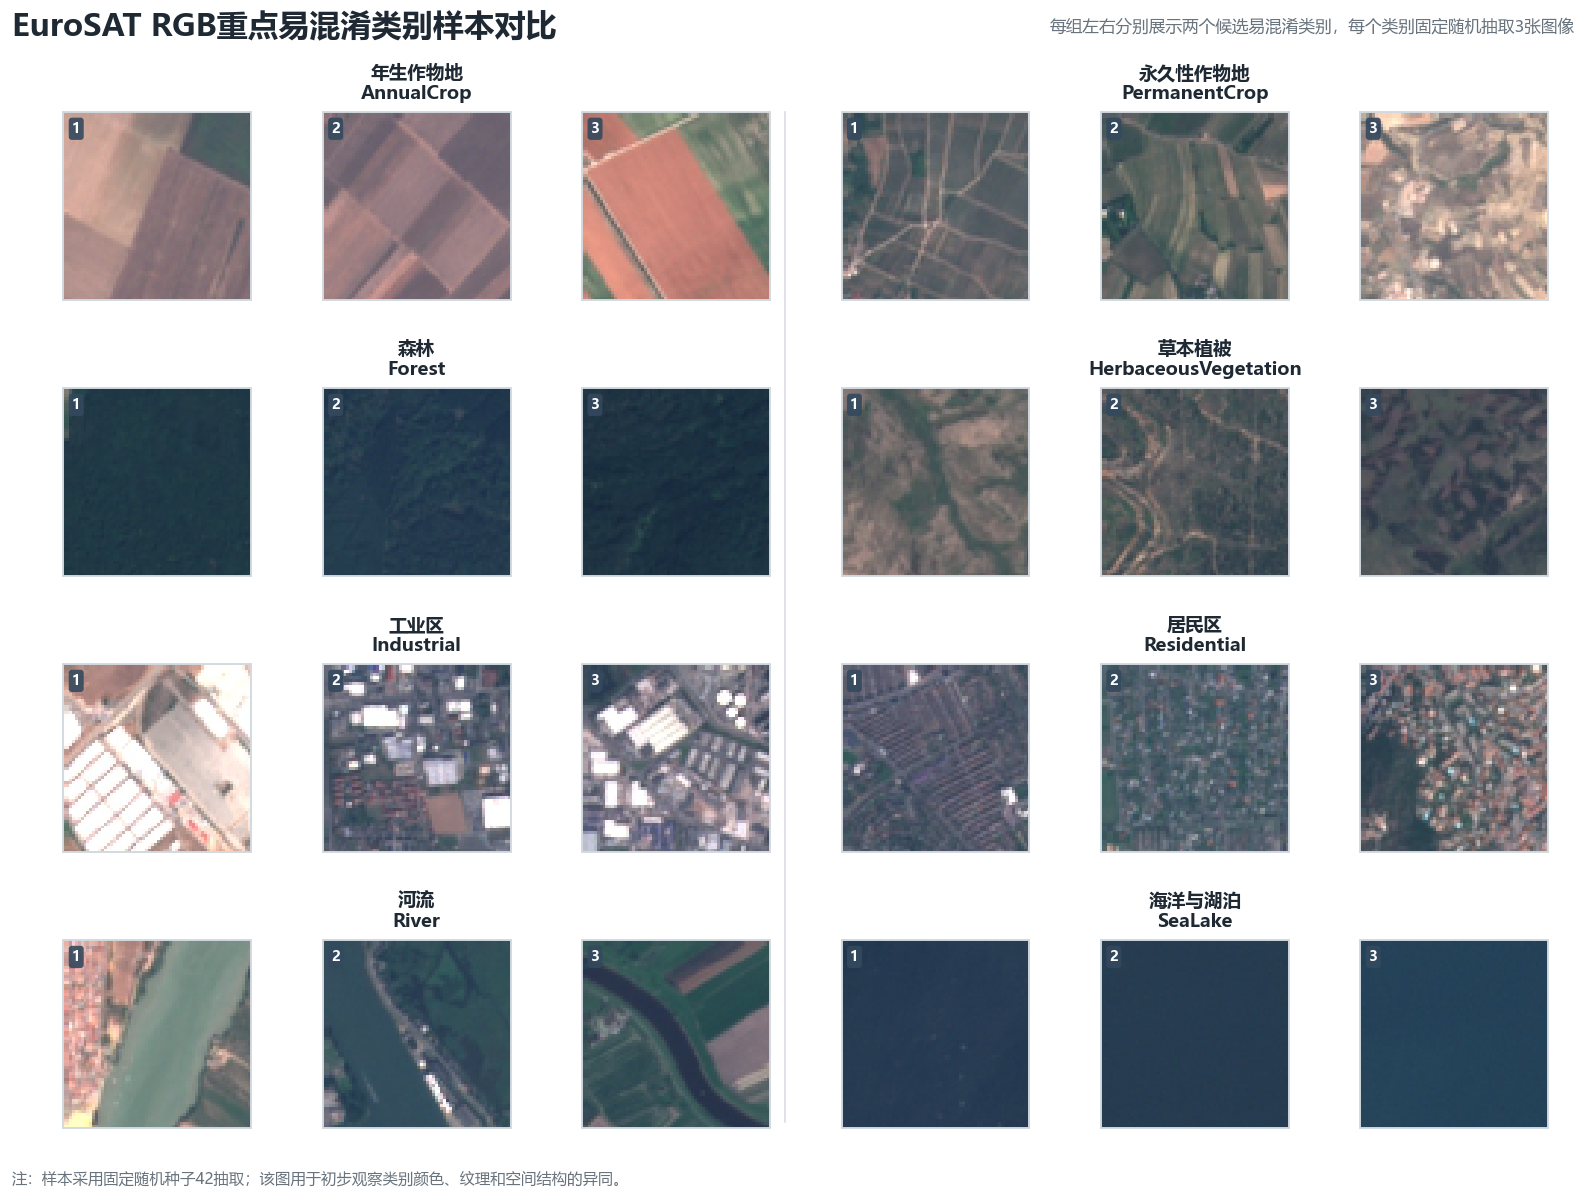

重点类别样本对比图已保存至：
D:\qy\junior\深度学习\课设\4.2.4_易混淆类别初步分析\08_重点易混淆类别样本对比图.png


In [6]:
# ==========================================
# 4.2.4 绘制重点易混淆类别样本对比图
# ==========================================

CONFUSION_SAMPLE_SEED = 42
SAMPLES_PER_CONFUSION_CLASS = 3

VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}


# ------------------------------
# 1. 四组重点分析类别
# ------------------------------
focus_pairs = [
    ("AnnualCrop", "PermanentCrop"),
    ("Forest", "HerbaceousVegetation"),
    ("Industrial", "Residential"),
    ("River", "SeaLake")
]


# ------------------------------
# 2. 抽取代表性样本
# ------------------------------
confusion_rng = random.Random(
    CONFUSION_SAMPLE_SEED
)

focus_pair_samples = {}

for first_class, second_class in focus_pairs:

    for class_name in [
        first_class,
        second_class
    ]:
        if class_name in focus_pair_samples:
            continue

        class_dir = DATA_DIR / class_name

        image_paths = sorted([
            image_path
            for image_path in class_dir.iterdir()
            if image_path.is_file()
            and image_path.suffix.lower()
            in VALID_EXTENSIONS
        ])

        focus_pair_samples[class_name] = (
            confusion_rng.sample(
                image_paths,
                SAMPLES_PER_CONFUSION_CLASS
            )
        )


# ------------------------------
# 3. 创建4行×6列图表
# ------------------------------
fig, axes = plt.subplots(
    nrows=4,
    ncols=6,
    figsize=(14, 10.2)
)

border_color = "#D2DAE0"
title_color = "#1F2933"
subtitle_color = "#68737D"
label_color = "#34495E"


for row_index, (
    first_class,
    second_class
) in enumerate(focus_pairs):

    current_pair = [
        first_class,
        second_class
    ]

    for group_index, class_name in enumerate(
        current_pair
    ):
        start_column = group_index * 3

        selected_paths = (
            focus_pair_samples[class_name]
        )

        for sample_index, image_path in enumerate(
            selected_paths
        ):
            ax = axes[
                row_index,
                start_column + sample_index
            ]

            with Image.open(image_path) as image:
                ax.imshow(
                    image.convert("RGB"),
                    interpolation="nearest"
                )

            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(False)

            image_border = Rectangle(
                (0, 0),
                1,
                1,
                transform=ax.transAxes,
                fill=False,
                edgecolor=border_color,
                linewidth=1.15,
                clip_on=False
            )

            ax.add_patch(image_border)

            ax.text(
                0.045,
                0.955,
                str(sample_index + 1),
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=8.5,
                color="white",
                fontweight="bold",
                bbox={
                    "boxstyle": "round,pad=0.22",
                    "facecolor": label_color,
                    "edgecolor": "none",
                    "alpha": 0.90
                }
            )

            if sample_index == 1:
                ax.set_title(
                    f"{class_name_cn[class_name]}\n"
                    f"{class_name}",
                    fontsize=11.2,
                    fontweight="bold",
                    color=title_color,
                    pad=8,
                    linespacing=1.15
                )


# ------------------------------
# 4. 添加中间分隔线
# ------------------------------
separator = plt.Line2D(
    [0.50, 0.50],
    [0.075, 0.90],
    transform=fig.transFigure,
    color="#D9DEE3",
    linewidth=1.0
)

fig.add_artist(separator)


# ------------------------------
# 5. 标题与说明
# ------------------------------
fig.suptitle(
    "EuroSAT RGB重点易混淆类别样本对比",
    x=0.04,
    y=0.982,
    ha="left",
    va="top",
    fontsize=18.5,
    fontweight="bold",
    color=title_color
)

fig.text(
    0.97,
    0.977,
    "每组左右分别展示两个候选易混淆类别，"
    "每个类别固定随机抽取3张图像",
    ha="right",
    va="top",
    fontsize=10,
    color=subtitle_color
)

fig.text(
    0.04,
    0.022,
    "注：样本采用固定随机种子42抽取；"
    "该图用于初步观察类别颜色、纹理和空间结构的异同。",
    ha="left",
    va="bottom",
    fontsize=9.2,
    color=subtitle_color
)


plt.subplots_adjust(
    left=0.055,
    right=0.97,
    top=0.90,
    bottom=0.07,
    wspace=0.08,
    hspace=0.47
)


# ------------------------------
# 6. 保存图片
# ------------------------------
sample_comparison_path = (
    CONFUSION_OUTPUT_DIR
    / "08_重点易混淆类别样本对比图.png"
)

plt.savefig(
    sample_comparison_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.08
)

plt.show()

print(
    f"重点类别样本对比图已保存至：\n"
    f"{sample_comparison_path.resolve()}"
)

#### 重点候选类别代表性样本对比分析

本步骤使用固定随机种子 42，从四组重点类别中的每个类别分别抽取 3 张图像，共展示 24 张遥感图像。

##### 年生作物地与永久性作物地

AnnualCrop 样本主要表现为面积较大的规则农田，地块颜色相对均匀，常见浅棕色、红褐色和绿色区域。

PermanentCrop 同样包含农业地块，但部分地块更加狭长、细碎或不规则，田间道路和种植结构更为复杂。

两类在整体颜色、农田边界和地块排列方面具有较明显相似性，与相似度排名第 3 的统计结果一致。

##### 森林与草本植被

Forest 图像整体颜色较暗，以连续的深蓝绿色区域为主，内部纹理和明暗变化相对较弱。

HerbaceousVegetation 图像颜色更偏灰绿和棕绿，局部裸地、道路和植被斑块更加明显，纹理变化高于 Forest。

两类均以植被为主体，但代表性样本表现出的亮度和纹理差异较明显。这与二者相似度仅为 22.33、排名第 33 的结果一致。

##### 工业区与居民区

Industrial 图像通常包含大型亮色厂房屋顶、规则建筑和明显阴影，具有较强的明暗对比和大尺度几何结构。

Residential 图像主要表现为密集的小型建筑和道路网络，建筑尺度更小，局部纹理更加细碎。

两类均包含大量人工边缘，但在建筑尺度、排列密度和对比度方面存在差异。

##### 河流与海洋湖泊

River 图像中的水体通常呈狭长或弯曲形态，河岸两侧包含农田、植被或建筑，具有明显的水陆边界。

SeaLake 样本主要由大面积连续水体构成，颜色较为均匀，图像中的边缘和纹理结构较少。

两类均具有水体颜色特征，但空间形态和背景组成差异明显。River 的河岸结构和周边地物是区分两类的重要信息。

代表性样本进一步说明，全局统计特征只能描述综合色彩和纹理水平，真正区分类别还需要利用地物形状、主体比例、边缘方向和空间布局。

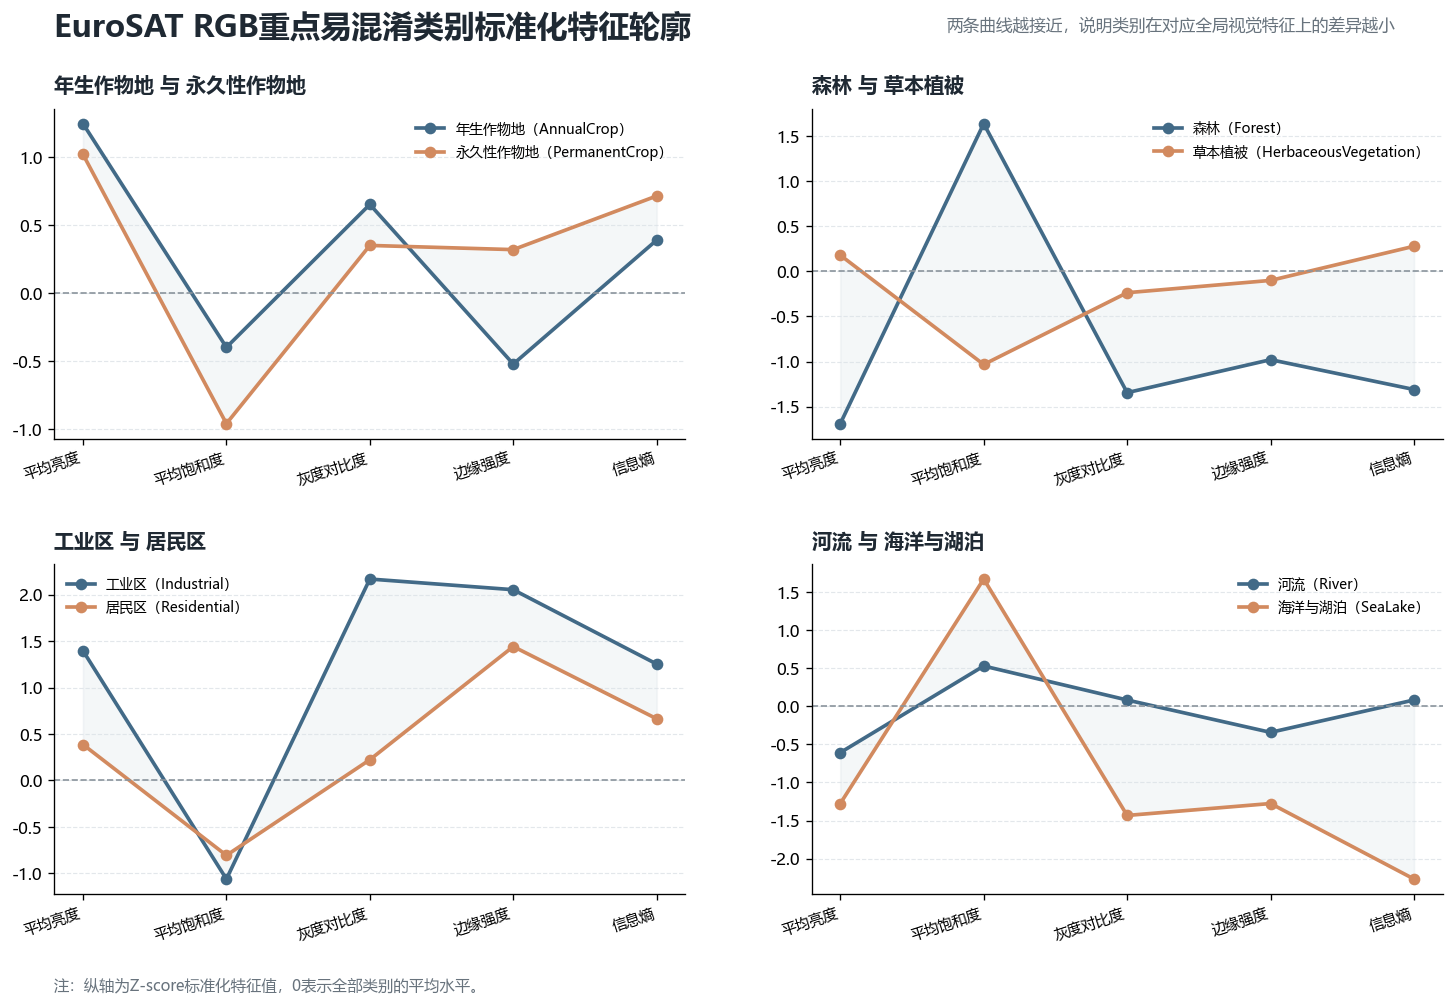

重点类别特征轮廓图已保存至：
D:\qy\junior\深度学习\课设\4.2.4_易混淆类别初步分析\09_重点易混淆类别特征轮廓图.png


In [7]:
# ==========================================
# 4.2.4 绘制重点类别对视觉特征轮廓图
# ==========================================

standardized_lookup = (
    standardized_feature_df
    .set_index("类别英文名称")
)


fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(13, 8.5)
)

axes = axes.flatten()

line_colors = [
    "#426A87",
    "#D28A5F"
]

x_positions = np.arange(
    len(analysis_features)
)


for ax, (
    first_class,
    second_class
) in zip(
    axes,
    focus_pairs
):

    first_values = (
        standardized_lookup
        .loc[
            first_class,
            analysis_features
        ]
        .to_numpy(dtype=float)
    )

    second_values = (
        standardized_lookup
        .loc[
            second_class,
            analysis_features
        ]
        .to_numpy(dtype=float)
    )

    ax.plot(
        x_positions,
        first_values,
        marker="o",
        linewidth=2.2,
        markersize=6,
        color=line_colors[0],
        label=(
            f"{class_name_cn[first_class]}"
            f"（{first_class}）"
        )
    )

    ax.plot(
        x_positions,
        second_values,
        marker="o",
        linewidth=2.2,
        markersize=6,
        color=line_colors[1],
        label=(
            f"{class_name_cn[second_class]}"
            f"（{second_class}）"
        )
    )

    ax.axhline(
        0,
        color="#8A949C",
        linewidth=1.0,
        linestyle="--"
    )

    ax.fill_between(
        x_positions,
        first_values,
        second_values,
        color="#B8C7D1",
        alpha=0.14
    )

    ax.set_xticks(x_positions)

    ax.set_xticklabels(
        analysis_features,
        rotation=18,
        ha="right",
        fontsize=8.8
    )

    ax.set_title(
        f"{class_name_cn[first_class]} 与 "
        f"{class_name_cn[second_class]}",
        loc="left",
        fontsize=12,
        fontweight="bold",
        color="#1F2933",
        pad=10
    )

    ax.grid(
        True,
        axis="y",
        linestyle="--",
        linewidth=0.7,
        color="#DCE2E7",
        alpha=0.8
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="best",
        frameon=False,
        fontsize=8.4
    )


fig.suptitle(
    "EuroSAT RGB重点易混淆类别标准化特征轮廓",
    x=0.07,
    y=0.985,
    ha="left",
    va="top",
    fontsize=18.5,
    fontweight="bold",
    color="#1F2933"
)

fig.text(
    0.93,
    0.979,
    "两条曲线越接近，说明类别在对应全局视觉特征上的差异越小",
    ha="right",
    va="top",
    fontsize=10,
    color="#68737D"
)

fig.text(
    0.07,
    0.022,
    "注：纵轴为Z-score标准化特征值，0表示全部类别的平均水平。",
    ha="left",
    va="bottom",
    fontsize=9.2,
    color="#68737D"
)


plt.subplots_adjust(
    left=0.07,
    right=0.96,
    top=0.89,
    bottom=0.12,
    wspace=0.20,
    hspace=0.38
)


feature_profile_path = (
    CONFUSION_OUTPUT_DIR
    / "09_重点易混淆类别特征轮廓图.png"
)

plt.savefig(
    feature_profile_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.08
)

plt.show()

print(
    f"重点类别特征轮廓图已保存至：\n"
    f"{feature_profile_path.resolve()}"
)

##### 重点候选类别标准化特征轮廓分析

轮廓图展示了四组重点类别在平均亮度、平均饱和度、灰度对比度、边缘强度和信息熵上的 Z-score 标准化结果。

纵轴中的 0 表示全部 10 个类别的平均水平。两条曲线越接近，表示两个类别在对应特征上的差异越小。

###### AnnualCrop 与 PermanentCrop

| 特征 | AnnualCrop | PermanentCrop |
|:---|---:|---:|
| 平均亮度 | +1.25 | +1.02 |
| 平均饱和度 | -0.40 | -0.96 |
| 灰度对比度 | +0.65 | +0.35 |
| 边缘强度 | -0.52 | +0.32 |
| 信息熵 | +0.39 | +0.72 |

两类在亮度、对比度和信息熵方面较为接近，最大差异出现在边缘强度。PermanentCrop 的边缘强度更高，说明其地块边界和种植结构更加细碎。

两条曲线整体较接近，对应的欧氏距离为 1.1269。

###### Forest 与 HerbaceousVegetation

| 特征 | Forest | HerbaceousVegetation |
|:---|---:|---:|
| 平均亮度 | -1.69 | +0.18 |
| 平均饱和度 | +1.64 | -1.03 |
| 灰度对比度 | -1.35 | -0.24 |
| 边缘强度 | -0.98 | -0.10 |
| 信息熵 | -1.31 | +0.28 |

二者最大的差异出现在平均饱和度和平均亮度。Forest 更暗且饱和度更高，HerbaceousVegetation 则具有更高的对比度、边缘强度和信息熵。

两条曲线差异明显，对应距离达到 3.8923。

###### Industrial 与 Residential

| 特征 | Industrial | Residential |
|:---|---:|---:|
| 平均亮度 | +1.40 | +0.39 |
| 平均饱和度 | -1.06 | -0.81 |
| 灰度对比度 | +2.17 | +0.22 |
| 边缘强度 | +2.05 | +1.44 |
| 信息熵 | +1.25 | +0.66 |

两类均具有低饱和度和高边缘特征，符合人工建筑区域的共同特点。

最大差异出现在灰度对比度。Industrial 中大型亮色屋顶和阴影使其对比度明显高于 Residential。

###### River 与 SeaLake

| 特征 | River | SeaLake |
|:---|---:|---:|
| 平均亮度 | -0.61 | -1.28 |
| 平均饱和度 | +0.53 | +1.67 |
| 灰度对比度 | +0.08 | -1.43 |
| 边缘强度 | -0.34 | -1.28 |
| 信息熵 | +0.08 | -2.27 |

两类平均亮度均低于总体水平，但在饱和度、对比度、边缘强度和信息熵方面存在较大差异。

其中，信息熵的差异最大。River 图像包含河岸与周边陆地，因此灰度和纹理信息明显多于大面积均匀的 SeaLake。

轮廓图说明，四组候选类别中只有 AnnualCrop 与 PermanentCrop 在 5 项特征上的整体曲线较为接近；其余三组更多是类别语义或局部结构接近，而不是全局统计特征接近。

In [8]:
# ==========================================
# 4.2.4 自动生成易混淆类别初步分析总结
# ==========================================

top_five_pairs = (
    pair_similarity_df
    .head(5)
    .copy()
)

summary_lines = []

summary_lines.append(
    "=" * 72
)

summary_lines.append(
    "EuroSAT RGB易混淆类别初步分析总结"
)

summary_lines.append(
    "=" * 72
)

summary_lines.append(
    "本实验基于10个类别的平均亮度、平均饱和度、"
    "灰度对比度、边缘强度和信息熵进行标准化相似度分析。"
)

summary_lines.append(
    "视觉特征距离越小、相似度指数越高，"
    "表示两个类别的全局统计视觉特征越接近。"
)

summary_lines.append(
    "\n视觉特征最接近的前5组类别如下："
)

for _, row in top_five_pairs.iterrows():

    summary_lines.append(
        f"第{int(row['相似度排名'])}名："
        f"{row['类别1中文名称']}"
        f"（{row['类别1英文名称']}）与"
        f"{row['类别2中文名称']}"
        f"（{row['类别2英文名称']}），"
        f"视觉特征距离为"
        f"{row['视觉特征距离']:.4f}，"
        f"相似度指数为"
        f"{row['相似度指数']:.2f}。"
    )


summary_lines.append(
    "\n结合代表性样本和土地利用类别语义，"
    "本实验重点关注以下四组候选易混淆类别："
)

for (
    first_class,
    second_class,
    reason
) in prior_confusing_pairs:

    pair_result = get_pair_result(
        first_class,
        second_class
    )

    summary_lines.append(
        f"{class_name_cn[first_class]}"
        f"（{first_class}）与"
        f"{class_name_cn[second_class]}"
        f"（{second_class}）："
        f"{reason}；"
        f"相似度排名为"
        f"{int(pair_result['相似度排名'])}。"
    )


summary_lines.append(
    "\n需要注意的是，本阶段分析仅依据全局人工视觉特征，"
    "不能直接代表模型的真实误分类情况。"
)

summary_lines.append(
    "后续模型训练完成后，需要结合测试集混淆矩阵、"
    "各类别Precision、Recall、F1-score及错误样本，"
    "进一步验证这些类别是否确实容易发生混淆。"
)


summary_text = "\n".join(
    summary_lines
)

print(summary_text)


summary_path = (
    CONFUSION_OUTPUT_DIR
    / "10_易混淆类别初步分析总结.txt"
)

summary_path.write_text(
    summary_text,
    encoding="utf-8"
)

print(
    f"\n分析总结已保存至：\n"
    f"{summary_path.resolve()}"
)

EuroSAT RGB易混淆类别初步分析总结
本实验基于10个类别的平均亮度、平均饱和度、灰度对比度、边缘强度和信息熵进行标准化相似度分析。
视觉特征距离越小、相似度指数越高，表示两个类别的全局统计视觉特征越接近。

视觉特征最接近的前5组类别如下：
第1名：牧场（Pasture）与河流（River），视觉特征距离为1.0678，相似度指数为66.28。
第2名：森林（Forest）与海洋与湖泊（SeaLake），视觉特征距离为1.0877，相似度指数为65.77。
第3名：年生作物地（AnnualCrop）与永久性作物地（PermanentCrop），视觉特征距离为1.1269，相似度指数为64.79。
第4名：草本植被（HerbaceousVegetation）与高速公路（Highway），视觉特征距离为1.1391，相似度指数为64.48。
第5名：高速公路（Highway）与河流（River），视觉特征距离为1.1442，相似度指数为64.36。

结合代表性样本和土地利用类别语义，本实验重点关注以下四组候选易混淆类别：
年生作物地（AnnualCrop）与永久性作物地（PermanentCrop）：均为农业用地，平均色彩和地块纹理接近；相似度排名为3。
森林（Forest）与草本植被（HerbaceousVegetation）：均以植被为主体，颜色及纹理具有相似性；相似度排名为33。
工业区（Industrial）与居民区（Residential）：均包含建筑、道路及密集人工边缘结构；相似度排名为19。
河流（River）与海洋与湖泊（SeaLake）：均以水体为主体，颜色特征接近；相似度排名为30。

需要注意的是，本阶段分析仅依据全局人工视觉特征，不能直接代表模型的真实误分类情况。
后续模型训练完成后，需要结合测试集混淆矩阵、各类别Precision、Recall、F1-score及错误样本，进一步验证这些类别是否确实容易发生混淆。

分析总结已保存至：
D:\qy\junior\深度学习\课设\4.2.4_易混淆类别初步分析\10_易混淆类别初步分析总结.txt


##### 易混淆类别初步分析综合结论

本步骤基于 10 个类别的平均亮度、平均饱和度、灰度对比度、边缘强度和信息熵，完成了特征标准化、类别距离计算、相似度指数转换、重点类别筛选和代表性样本对比。

主要结果如下：

1. 10 个类别共形成 45 组不重复类别组合；
2. Pasture 与 River 的视觉特征距离最小，为 1.0678，相似度指数最高，为 66.28；
3. Forest 与 SeaLake 排名第 2，相似度指数为 65.77；
4. AnnualCrop 与 PermanentCrop 排名第 3，相似度指数为 64.79；
5. HerbaceousVegetation 与 Highway 排名第 4，相似度指数为 64.48；
6. Highway 与 River 排名第 5，相似度指数为 64.36。

结合类别语义和代表性图像，本实验重点分析了以下四组候选类别：

- AnnualCrop 与 PermanentCrop；
- Forest 与 HerbaceousVegetation；
- Industrial 与 Residential；
- River 与 SeaLake。

其中，AnnualCrop 与 PermanentCrop 同时满足统计特征接近和类别语义接近，是本阶段最明确的候选易混淆类别。

Forest 与 HerbaceousVegetation、Industrial 与 Residential、River 与 SeaLake 的相似度排名分别为第 33、第 19 和第 30。这说明语义相近或局部结构相似，并不一定表现为类别全局均值接近。

本节还出现了 Forest 与 SeaLake、Pasture 与 River 等语义不同但统计特征相近的组合，说明人工全局特征可能忽略地物形状和空间布局。

因此，本阶段分析只能用于提供模型评价前的候选关系，不能直接得出模型会发生哪些误分类的结论。

模型训练完成后，应重点结合以下结果进一步验证：

- 测试集混淆矩阵；
- 各类别 Precision；
- 各类别 Recall；
- 各类别 F1-score；
- 错误分类样本可视化；
- 模型提取的深层特征分布。

只有当候选类别在测试集混淆矩阵中出现较多相互误分类样本时，才能确认其属于模型实际易混淆类别。

In [9]:
# ==========================================
# 4.2.4 生成输出文件清单
# ==========================================

output_files = sorted([
    file_path
    for file_path in CONFUSION_OUTPUT_DIR.iterdir()
    if file_path.is_file()
])

output_manifest_records = []

for index, file_path in enumerate(
    output_files,
    start=1
):
    output_manifest_records.append({
        "序号": index,
        "文件名称": file_path.name,
        "文件类型": (
            file_path.suffix.lower()
        ),
        "文件大小KB": round(
            file_path.stat().st_size / 1024,
            2
        ),
        "完整路径": str(
            file_path.resolve()
        )
    })


output_manifest_df = pd.DataFrame(
    output_manifest_records
)

manifest_path = (
    CONFUSION_OUTPUT_DIR
    / "11_输出文件清单.csv"
)

output_manifest_df.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8-sig"
)


print("=" * 72)
print("4.2.4 易混淆类别初步分析输出完成")
print("=" * 72)

print(
    f"输出文件夹：\n"
    f"{CONFUSION_OUTPUT_DIR.resolve()}"
)

print(
    f"\n当前共生成"
    f"{len(output_manifest_df)}个结果文件："
)

display(
    output_manifest_df[
        [
            "序号",
            "文件名称",
            "文件类型",
            "文件大小KB"
        ]
    ]
)

4.2.4 易混淆类别初步分析输出完成
输出文件夹：
D:\qy\junior\深度学习\课设\4.2.4_易混淆类别初步分析

当前共生成10个结果文件：


,序号,文件名称,文件类型,文件大小KB
0,1,01_类别标准化视觉特征.csv,.csv,1.29
1,2,02_类别视觉特征距离矩阵.csv,.csv,1.87
2,3,03_全部类别对视觉相似度排名.csv,.csv,3.96
3,4,04_重点易混淆类别对.csv,.csv,0.59
4,5,05_类别视觉相似度矩阵.csv,.csv,1.89
5,6,06_类别视觉特征相似度热力图.png,.png,610.76
6,7,07_易混淆类别视觉相似度排名图.png,.png,363.34
7,8,08_重点易混淆类别样本对比图.png,.png,624.53
8,9,09_重点易混淆类别特征轮廓图.png,.png,701.85
9,10,10_易混淆类别初步分析总结.txt,.txt,2.05


In [32]:
# ==========================================
# 4.3.3 生成输出文件清单
# ==========================================

output_files = sorted([
    file_path
    for file_path in (
        NORMALIZE_OUTPUT_DIR.iterdir()
    )
    if file_path.is_file()
])

output_records = []

for file_index, file_path in enumerate(
    output_files,
    start=1
):
    output_records.append({
        "序号": file_index,
        "文件名称": file_path.name,
        "文件类型": (
            file_path.suffix.lower()
        ),
        "文件大小KB": round(
            file_path.stat().st_size
            / 1024,
            2
        ),
        "完整路径": str(
            file_path.resolve()
        )
    })


normalization_output_manifest_df = (
    pd.DataFrame(output_records)
)

normalization_manifest_path = (
    NORMALIZE_OUTPUT_DIR
    / "11_输出文件清单.csv"
)

normalization_output_manifest_df.to_csv(
    normalization_manifest_path,
    index=False,
    encoding="utf-8-sig"
)


print("=" * 72)
print("4.3.3 图像标准化检查输出完成")
print("=" * 72)

print(
    f"输出文件夹：\n"
    f"{NORMALIZE_OUTPUT_DIR.resolve()}"
)

print(
    f"\n当前共生成"
    f"{len(normalization_output_manifest_df)}"
    "个结果文件："
)

display(
    normalization_output_manifest_df[
        [
            "序号",
            "文件名称",
            "文件类型",
            "文件大小KB"
        ]
    ]
)

4.3.3 图像标准化检查输出完成
输出文件夹：
D:\qy\junior\深度学习\课设\4.3.3_图像标准化检查

当前共生成11个结果文件：


,序号,文件名称,文件类型,文件大小KB
0,1,00_ImageNet标准化配置.json,.json,0.54
1,2,01_ImageNet标准化参数表.csv,.csv,0.18
2,3,02_图像标准化流程图.png,.png,431.78
3,4,03_标准化展示样本记录.csv,.csv,0.77
4,5,04_标准化与反标准化效果图.png,.png,1757.99
5,6,05_标准化前后通道统计.csv,.csv,0.68
6,7,06_标准化前后通道统计图.png,.png,387.76
7,8,07_标准化前后像素分布图.png,.png,258.91
8,9,08_标准化检查明细.csv,.csv,17.03
9,10,09_标准化完整性检查.csv,.csv,0.44


##### 本步骤输出文件说明

本步骤运行时统计并展示了 10 个已生成结果文件。

| 序号 | 输出文件 | 主要内容 |
|---:|:---|:---|
| 1 | 01_类别标准化视觉特征.csv | 10 个类别的 5 项 Z-score 特征 |
| 2 | 02_类别视觉特征距离矩阵.csv | 10×10 类别欧氏距离矩阵 |
| 3 | 03_全部类别对视觉相似度排名.csv | 45 组类别对距离及相似度排名 |
| 4 | 04_重点易混淆类别对.csv | 四组重点候选类别及依据 |
| 5 | 05_类别视觉相似度矩阵.csv | 10×10 相似度指数矩阵 |
| 6 | 06_类别视觉特征相似度热力图.png | 类别两两相似度热力图 |
| 7 | 07_易混淆类别视觉相似度排名图.png | 相似度最高的前 10 组类别 |
| 8 | 08_重点易混淆类别样本对比图.png | 四组类别共 24 张代表性样本 |
| 9 | 09_重点易混淆类别特征轮廓图.png | 四组类别的标准化特征曲线 |
| 10 | 10_易混淆类别初步分析总结.txt | 自动生成的文字总结 |

代码先读取当前目录中的文件并建立 `output_manifest_df`，之后才写入：

`11_输出文件清单.csv`

因此，运行输出显示“当前共生成 10 个结果文件”，指的是建立清单前已经存在的 10 个实验结果。

当 `11_输出文件清单.csv` 保存完成后，输出目录中实际共有 11 个文件。该现象是代码执行顺序导致的正常结果，不属于文件缺失。

本次 Notebook 运行时使用的旧输出位置为：

`D:\qy\junior\深度学习\课设\4.2.4_易混淆类别初步分析`

按照当前整理后的项目目录，后续重新运行时应将该步骤输出到：

`results/4.2.4_易混淆类别初步分析/`

这样可以与其他实验步骤的结果目录保持统一。